# Diamond Creek ETF Arbitrage — Backtest v15


**v8:** Keeps the same v7 engine/data/costs, and adds a new weighting method that combines **backtest PnL/Gross** with **screener net decay signal** (`data/etf_screened_today.csv`), then applies a **shares-available capacity cap** so short ETF targets do not exceed a configurable fraction of available lendable shares.

**Dynamic target gross multiple:** **`V7_TARGET_LEV_START` → `V7_TARGET_LEV_END`** (default **4.5× → 5.0×** NAV) as a function of how many **post-start** candidate pairs have **non-trivial gross** on the book.

**Later cells:** After the equal-weight run, save NAVs + build **v8 combined weights**, then re-backtest with **`v8_pnl_decay_shares_weights.csv`**. Final section adds a historical **shares-available** analysis from `data/runs/*/etf_screened_today.csv`.


[Overview](#Diamond-Creek-ETF-Arbitrage--Backtest-v9) | [Setup](#Setup) | [Clear Street Live Borrow/Rebate](#Clear-Street-Live-BorrowRebate-Sandbox) | [Configuration](#Configuration) | [Universe](#Universe--v7-same-hardcoded-list-as-v6-from-DC_Universe_Map_Filteredxlsx)

## Setup


In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, requests, time, ftplib, io, os
from datetime import datetime, timezone
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

TRADING_DAYS = 252
norm_sym = lambda x: str(x).strip().upper().replace(".", "-")
print("Imports OK")


Imports OK


## Configuration


## v15 Override — Clear Street borrow rates + beta>1.5 universe

This override loads borrow rates from the Clear Street output in `data/runs/<run_day>/clearstreet/bulk_rates_one_by_one.csv`, filters the backtest universe to ETFs present in that file and with `Beta > 1.5`, then applies those borrow rates for sizing/backtest.

In [2]:
# v15: use etfs2.csv rates as the exclusive borrow input source.

from pathlib import Path
import pandas as pd

etfs2_rate_paths = [
    Path(r"C:/Users/werdn/Downloads/etfs2.csv"),
    Path("data/backtest/etfs2.csv"),
    Path("../data/backtest/etfs2.csv"),
]
ETFS2_RATE_PATH = next((p for p in etfs2_rate_paths if p.exists()), None)
if ETFS2_RATE_PATH is None:
    raise FileNotFoundError(
        "Borrow-rate file not found. Checked C:/Users/werdn/Downloads/etfs2.csv and data/backtest/etfs2.csv."
    )

etfs2 = pd.read_csv(ETFS2_RATE_PATH)
etfs2.columns = [str(c).strip() for c in etfs2.columns]
tcol = next((c for c in ["Ticker", "ETF", "Symbol", "ticker", "etf", "symbol"] if c in etfs2.columns), None)
rcol = next((c for c in ["Rate", "rate", "borrow_rate_pct", "Borrow", "borrow"] if c in etfs2.columns), None)
if (tcol is None) or (rcol is None):
    raise KeyError(
        f"etfs2.csv missing required borrow columns. Need ticker + rate; found {list(etfs2.columns)}"
    )

_tmp = etfs2[[tcol, rcol]].copy()
_tmp[tcol] = _tmp[tcol].astype(str).str.upper().str.strip().str.replace(".", "-", regex=False)
_tmp[rcol] = pd.to_numeric(_tmp[rcol], errors="coerce")
_tmp = _tmp[_tmp[tcol].ne("") & _tmp[rcol].notna()].drop_duplicates(subset=[tcol], keep="last")

# Backtest convention: positive BORROW_MAP means we pay borrow.
# etfs2 convention used here: positive means rebate/credit, negative means fee/cost.
# Convert to decimal and invert sign to match backtest convention.
etf2_borrow_map_all = {
    str(t): float(-r / 100.0)
    for t, r in zip(_tmp[tcol], _tmp[rcol])
}

# Flags consumed by downstream cells.
V15_ETFS2_OVERRIDE_ACTIVE = True
V15_ETFS2_TICKERS_WITH_RATES = set(etf2_borrow_map_all.keys())
V15_BORROW_TICKERS_WITH_RATES = set(etf2_borrow_map_all.keys())
# Backward-compatible aliases for older downstream references.
V13_ETFS2_OVERRIDE_ACTIVE = V15_ETFS2_OVERRIDE_ACTIVE
V13_ETFS2_TICKERS_WITH_RATES = V15_ETFS2_TICKERS_WITH_RATES
SAMPLE_BOOK_BORROW_MAP = dict(etf2_borrow_map_all)

print(f"[V15] etfs2 borrow source: {ETFS2_RATE_PATH}")
print(f"[V15] etfs2 rows parsed: {len(_tmp)}")
print(f"[V15] Total borrow-map tickers: {len(V15_BORROW_TICKERS_WITH_RATES)}")
print("[V15] Universe rule: include ETFs present in etfs2 borrow-rate file")

[V15] etfs2 borrow source: C:\Users\werdn\Downloads\etfs2.csv
[V15] etfs2 rows parsed: 389
[V15] Total borrow-map tickers: 389
[V15] Universe rule: include ETFs present in etfs2 borrow-rate file


In [3]:
CFG = {
    "capital_usd":          10_000_000,
    "start_date":           "2023-01-01",
    "slippage_bps":         10,
    # Clear Street US equities low-touch baseline (35 mills/share).
    "clear_street_comm_per_share":  0.0035,
    "clear_street_comm_min":        0.00,
    "clear_street_comm_max_pct":    1.00,
    "fallback_borrow_rate": 0.0,
    # Clear Street financing assumptions from proposal:
    # debit = OBFR + 45 bps, cash credit / short rebate = OBFR - 40 bps,
    # negative benchmark/rate floored at 0, Actual/360 accrual.
    "margin_debit_spreads": [
        (float("inf"), 0.0045),
    ],
    "credit_spread":        -0.0040,
    "enable_short_credit_income": False,
    "financing_daycount":   360,
    "skip_ftp":             False,
    "dead_band_pct":        0.02,
    "gross_dead_band_pct":  0.05,       # full position resize if portfolio gross drifts > 5% from target
    "weight_power":         1.15,       # mild convexity to lift return without aggressive concentration
    "mix_decay_weight":     0.40,       # balanced blend between realized PnL/Gross and decay signal
    "decay_weight_power":   1.05,       # slight emphasis on higher-quality decay names
    "max_dd_penalty_weight": 0.50,      # stronger explicit penalty for high drawdown names
    "max_dd_penalty_start": "2024-01-01", # focus DD penalty on 2024+ path quality
    "max_dd_penalty_recent_weight": 0.70, # heavier weight on recent-window DD vs full-history DD
    "position_concentration_power": 1.00, # neutral concentration tilt
    "short_avail_use_pct":  0.25,       # softer cap: can target up to 25% of reported shares_available
    "max_pair_weight_cap":  0.050,      # slightly higher cap to recover some upside
    "max_underlying_weight_cap": 0.11,  # mild relaxation for CAGR while keeping concentration bounded
    "missing_shares_cap":   0.02,       # strict fallback cap when shares_available is missing
    "cap_ramp_rebals":      4,          # slower ramp into constrained names
}

LEVERAGE_RUNS = [4.75]

V7_TARGET_LEV_START = 4.5   # incumbent day-0 sizing; floor for target multiple
V7_TARGET_LEV_END = 5    # modestly higher ceiling for CAGR once post-start pairs are on book

print(f"Capital: ${CFG['capital_usd']:,}  |  Start: {CFG['start_date']}")
print(f"Leverage: {LEVERAGE_RUNS}  |  v8 target gross multiple: {V7_TARGET_LEV_START}x → {V7_TARGET_LEV_END}x")
print("Weekly dead-band hedge  |  0% beta target  |  v8 combined weights (PnL/Gross + decay + shares cap)")


Capital: $10,000,000  |  Start: 2023-01-01
Leverage: [4.75]  |  v8 target gross multiple: 4.5x → 5x
Weekly dead-band hedge  |  0% beta target  |  v8 combined weights (PnL/Gross + decay + shares cap)


## PM margin — Diamond Creek sample book

Long/short equity book (~70 US names, mainly large caps and ETFs). **Source:** `data/backtest/PM Report Diamond Creek 20260326 CV.xlsx` → *Top Level Summary*.

PM notes (narrative): regulatory-style requirement lands near **$6.5MM**; **discretionary** add-on tied to crypto proxies (BITU, BITX, ETHA, ETHT, ETHU, IBIT, SOEZ); **concentration** add-on on largest names (e.g. NVDA, TSLA); small **liquidity** add-on (SOEZ). **PM/GMV** in the file is *Effective margin requirement ÷ GMV* (~17%).

The next cell loads the spreadsheet and estimates **margin excess** if gross exposure were raised to **4.5× equity** (same equity, higher GMV), by applying the file’s **MR/GMV** ratio to the new gross (equivalent to scaling today’s effective margin **linearly with GMV** when the report is internally consistent).


## Universe — v7 (same hardcoded list as v6 from `DC_Universe_Map_Filtered.xlsx`)



In [4]:
# Hardcoded from DC_Universe_Map_Filtered.xlsx (sheet "Universe Map") — all ETF slots, |β| rounded to 3dp.
CANDIDATES = [
    ("SMU", "SMR", 1.986),   ("SMUP", "SMR", 2.058),  ("QBTX", "QBTS", 1.993),
    ("BMNU", "BMNR", 1.944), ("BMNG", "BMNR", 1.993), ("ASTX", "ASTS", 1.990),
    ("CRWG", "CRWV", 1.997), ("CWVX", "CRWV", 1.990), ("WULX", "WULF", 1.997),
    ("NEBX", "NBIS", 1.999), ("NBIL", "NBIS", 1.998), ("NBIG", "NBIS", 2.009),
    ("SMCL", "SMCI", 1.990), ("CRCA", "CRCL", 1.978), ("CRCG", "CRCL", 1.990),
    ("LABX", "ALAB", 1.994), ("BEX", "BE", 1.977),    ("CLSX", "CLSK", 1.999),
    ("GLXU", "GLXY", 2.012), ("XXRP", "XRPZ", 2.020), ("XRPT", "XRPZ", 2.018),
    ("ETHU", "ETHA", 2.001), ("ETHT", "ETHA", 1.991), ("ETU", "ETHA", 1.990),
    ("CRDU", "CRDO", 1.988), ("FIGG", "FIG", 1.996),  ("SOLT", "SOEZ", 2.014),
    ("CONL", "COIN", 1.987), ("APPX", "APP", 1.984),  ("UUUG", "UUUU", 1.995),
    ("SOXL", "SOXX", 2.960), ("ROBN", "HOOD", 2.012), ("HOOG", "HOOD", 2.007),
    ("LITX", "LITE", 1.980), ("INTW", "INTC", 1.988), ("UPSX", "UPST", 1.989),
    ("CSEX", "CLS", 1.998),  ("MUU", "MU", 1.994),    ("MULL", "MU", 1.997),
    ("ARCX", "ACHR", 1.989), ("SATG", "SATS", 2.010), ("VRTL", "VRT", 1.982),
    ("GDXU", "GDX", 3.043),  ("NUGT", "GDX", 1.981),  ("TEMT", "TEM", 1.985),
    ("RDTL", "RDDT", 1.982), ("RBLU", "RBLX", 2.019), ("AMDL", "AMD", 1.997),
    ("AMUU", "AMD", 2.008),  ("AMDG", "AMD", 2.003),  ("TSLL", "TSLA", 1.993),
    ("TSLT", "TSLA", 1.993), ("TSLR", "TSLA", 1.999), ("TSLG", "TSLA", 1.991),
    ("BITX", "IBIT", 2.005), ("BITU", "IBIT", 1.992), ("BTCL", "IBIT", 2.007),
    ("YINN", "FXI", 2.974),  ("MVLL", "MRVL", 1.992), ("URAA", "URA", 1.933),
    ("SNOU", "SNOW", 2.024), ("BULG", "BULL", 1.985), ("PLTU", "PLTR", 1.992),
    ("PTIR", "PLTR", 1.997), ("PLTG", "PLTR", 1.996), ("BABX", "BABA", 2.006),
    ("NVDL", "NVDA", 1.988), ("NVDU", "NVDA", 1.986), ("NVDX", "NVDA", 1.997),
    ("NVDG", "NVDA", 1.969), ("LRCU", "LRCX", 2.045), ("ARMG", "ARM", 1.997),
    ("TSMU", "TSM", 1.990),  ("TSMG", "TSM", 1.979),  ("GEVX", "GEV", 1.993),
    ("KTUP", "KTOS", 2.026), ("AVL", "AVGO", 1.987),  ("AVGG", "AVGO", 1.999),
    ("AVGU", "AVGO", 1.992), ("UBRL", "UBER", 1.995), ("CRMG", "CRM", 1.984),
    ("UNHG", "UNH", 1.996),  ("MEXX", "EWW", 2.958),  ("JNUG", "GDXJ", 1.974),
    ("NFLU", "NFLX", 1.990), ("CWEB", "KWEB", 1.987), ("CEGX", "CEG", 1.979),
    ("GGLL", "GOOGL", 1.992),("GOOX", "GOOGL", 1.984),("KORU", "EWY", 2.931),
    ("TERG", "TER", 1.996),  ("DLLL", "DELL", 1.986), ("METU", "META", 1.999),
    ("FBL", "META", 1.997),  ("AMZU", "AMZN", 1.987), ("AMZZ", "AMZN", 1.992),
    ("PALU", "PANW", 2.006), ("ASMG", "ASML", 1.984), ("WDCX", "WDC", 2.055),
    ("CRWL", "CRWD", 1.997), ("ELIL", "LLY", 1.991),  ("PYPG", "PYPL", 1.995),
    ("BOEU", "BA", 1.987),   ("MSFU", "MSFT", 1.991), ("MSFL", "MSFT", 1.992),
    ("MSFX", "MSFT", 2.007), ("CHAU", "ASHR", 1.967), ("NOWL", "NOW", 1.996),
    ("ERX", "XLE", 1.988),   ("GUSH", "XOP", 2.011),  ("SHPU", "SHOP", 2.012),
    ("XOMX", "XOM", 1.969),  ("ORCU", "ORCL", 2.006), ("ADBG", "ADBE", 1.992),
    ("AAPU", "AAPL", 1.984), ("AAPB", "AAPL", 1.991), ("AAPX", "AAPL", 1.995),
    ("TARK", "ARKK", 1.978), ("LABU", "XBI", 2.988),  ("CSCL", "CSCO", 2.027),
    ("LMTL", "LMT", 1.984),  ("COTG", "COST", 1.987),
]

# Bucket 3 pairs (inverse ETF + underlying), handled with short-inverse + short-underlying leg construction.
BUCKET3_CANDIDATES = [
    ("APLZ", "APLD"),
    ("CLSZ", "CLSK"),
    ("IREZ", "IREN"),
    ("BEZ", "BE"),
    ("NBIZ", "NBIS"),
    ("SMZ", "SMR"),
    ("MSTZ", "MSTR"),
    ("TSLQ", "TSLA"),
    ("NVDQ", "NVDA"),
    ("SOXS", "SOXX"),
]
BUCKET3_ETFS = {e for e, _ in BUCKET3_CANDIDATES}
BUCKET3_UNDERLYINGS = {u for _, u in BUCKET3_CANDIDATES}

BASE_CANDIDATE_KEYS = {(e, u) for e, u, _ in CANDIDATES}

# Add all remaining screened pairs not already in the base map.
screen_paths = [Path("../data/etf_screened_today.csv"), Path("data/etf_screened_today.csv")]
_screen_path = next((p for p in screen_paths if p.exists()), None)
_added = 0
if _screen_path is not None:
    _sc = pd.read_csv(_screen_path)
    _sc.columns = [str(c).strip() for c in _sc.columns]
    req = {"ETF", "Underlying", "Beta"}
    if req.issubset(_sc.columns):
        _sc["ETF"] = _sc["ETF"].astype(str).str.upper().str.strip()
        _sc["Underlying"] = _sc["Underlying"].astype(str).str.upper().str.strip()
        _sc["Beta"] = pd.to_numeric(_sc["Beta"], errors="coerce")

        for r in _sc.itertuples(index=False):
            e = r.ETF
            u = r.Underlying
            b = float(r.Beta) if pd.notna(r.Beta) else np.nan
            if not e or not u or not np.isfinite(b):
                continue
            key = (e, u)
            if key in BASE_CANDIDATE_KEYS:
                continue
            CANDIDATES.append((e, u, round(abs(b), 3)))
            BASE_CANDIDATE_KEYS.add(key)
            _added += 1

EXTRA_ETFS = {e for e, u, _ in CANDIDATES if (e, u) not in {(x, y) for x, y, _ in [
    ("SMU", "SMR", 1),   ("SMUP", "SMR", 1),  ("QBTX", "QBTS", 1),
    ("BMNU", "BMNR", 1), ("BMNG", "BMNR", 1), ("ASTX", "ASTS", 1),
    ("CRWG", "CRWV", 1), ("CWVX", "CRWV", 1), ("WULX", "WULF", 1),
    ("NEBX", "NBIS", 1), ("NBIL", "NBIS", 1), ("NBIG", "NBIS", 1),
    ("SMCL", "SMCI", 1), ("CRCA", "CRCL", 1), ("CRCG", "CRCL", 1),
    ("LABX", "ALAB", 1), ("BEX", "BE", 1),    ("CLSX", "CLSK", 1),
    ("GLXU", "GLXY", 1), ("XXRP", "XRPZ", 1), ("XRPT", "XRPZ", 1),
    ("ETHU", "ETHA", 1), ("ETHT", "ETHA", 1), ("ETU", "ETHA", 1),
    ("CRDU", "CRDO", 1), ("FIGG", "FIG", 1),  ("SOLT", "SOEZ", 1),
    ("CONL", "COIN", 1), ("APPX", "APP", 1),  ("UUUG", "UUUU", 1),
    ("SOXL", "SOXX", 1), ("ROBN", "HOOD", 1), ("HOOG", "HOOD", 1),
    ("LITX", "LITE", 1), ("INTW", "INTC", 1), ("UPSX", "UPST", 1),
    ("CSEX", "CLS", 1),  ("MUU", "MU", 1),    ("MULL", "MU", 1),
    ("ARCX", "ACHR", 1), ("SATG", "SATS", 1), ("VRTL", "VRT", 1),
    ("GDXU", "GDX", 1),  ("NUGT", "GDX", 1),  ("TEMT", "TEM", 1),
    ("RDTL", "RDDT", 1), ("RBLU", "RBLX", 1), ("AMDL", "AMD", 1),
    ("AMUU", "AMD", 1),  ("AMDG", "AMD", 1),  ("TSLL", "TSLA", 1),
    ("TSLT", "TSLA", 1), ("TSLR", "TSLA", 1), ("TSLG", "TSLA", 1),
    ("BITX", "IBIT", 1), ("BITU", "IBIT", 1), ("BTCL", "IBIT", 1),
    ("YINN", "FXI", 1),  ("MVLL", "MRVL", 1), ("URAA", "URA", 1),
    ("SNOU", "SNOW", 1), ("BULG", "BULL", 1), ("PLTU", "PLTR", 1),
    ("PTIR", "PLTR", 1), ("PLTG", "PLTR", 1), ("BABX", "BABA", 1),
    ("NVDL", "NVDA", 1), ("NVDU", "NVDA", 1), ("NVDX", "NVDA", 1),
    ("NVDG", "NVDA", 1), ("LRCU", "LRCX", 1), ("ARMG", "ARM", 1),
    ("TSMU", "TSM", 1),  ("TSMG", "TSM", 1),  ("GEVX", "GEV", 1),
    ("KTUP", "KTOS", 1), ("AVL", "AVGO", 1),  ("AVGG", "AVGO", 1),
    ("AVGU", "AVGO", 1), ("UBRL", "UBER", 1), ("CRMG", "CRM", 1),
    ("UNHG", "UNH", 1),  ("MEXX", "EWW", 1),  ("JNUG", "GDXJ", 1),
    ("NFLU", "NFLX", 1), ("CWEB", "KWEB", 1), ("CEGX", "CEG", 1),
    ("GGLL", "GOOGL", 1),("GOOX", "GOOGL", 1),("KORU", "EWY", 1),
    ("TERG", "TER", 1),  ("DLLL", "DELL", 1), ("METU", "META", 1),
    ("FBL", "META", 1),  ("AMZU", "AMZN", 1), ("AMZZ", "AMZN", 1),
    ("PALU", "PANW", 1), ("ASMG", "ASML", 1), ("WDCX", "WDC", 1),
    ("CRWL", "CRWD", 1), ("ELIL", "LLY", 1),  ("PYPG", "PYPL", 1),
    ("BOEU", "BA", 1),   ("MSFU", "MSFT", 1), ("MSFL", "MSFT", 1),
    ("MSFX", "MSFT", 1), ("CHAU", "ASHR", 1), ("NOWL", "NOW", 1),
    ("ERX", "XLE", 1),   ("GUSH", "XOP", 1),  ("SHPU", "SHOP", 1),
    ("XOMX", "XOM", 1),  ("ORCU", "ORCL", 1), ("ADBG", "ADBE", 1),
    ("AAPU", "AAPL", 1), ("AAPB", "AAPL", 1), ("AAPX", "AAPL", 1),
    ("TARK", "ARKK", 1), ("LABU", "XBI", 1),  ("CSCL", "CSCO", 1),
    ("LMTL", "LMT", 1),  ("COTG", "COST", 1),
]}}

# Rebuild additions with explicit Beta filter: include only screened ETFs with Beta > 1.5.
_base_keys = {(e, u) for e, u, _ in CANDIDATES if e not in EXTRA_ETFS}
base_candidates = [t for t in CANDIDATES if (t[0], t[1]) in _base_keys]

extra_candidates = []
EXTRA_ETFS = set()
if _screen_path is not None and req.issubset(_sc.columns):
    for r in _sc.itertuples(index=False):
        e = str(r.ETF).upper().strip()
        u = str(r.Underlying).upper().strip()
        b = float(r.Beta) if pd.notna(r.Beta) else np.nan
        if not e or not u or not np.isfinite(b):
            continue
        if b <= 1.5:
            continue
        key = (e, u)
        if key in _base_keys:
            continue
        extra_candidates.append((e, u, round(b, 3)))
        EXTRA_ETFS.add(e)

# Deduplicate while preserving order.
_seen = set()
CANDIDATES = []
for e, u, b in base_candidates + extra_candidates:
    k = (e, u)
    if k in _seen:
        continue
    _seen.add(k)
    CANDIDATES.append((e, u, b))

# Load whitelist ETF universe from strategy_config.yml (keep even if beta < cutoff).
WHITELIST_ETFS = set()
cfg_candidates = [Path("config/strategy_config.yml"), Path("../config/strategy_config.yml")]
cfg_path = next((p for p in cfg_candidates if p.exists()), None)
if cfg_path is not None:
    try:
        import yaml
        with open(cfg_path, "r", encoding="utf-8") as f:
            _cfg_obj = yaml.safe_load(f) or {}
        _wl = (((_cfg_obj.get("portfolio", {}) or {}).get("sleeves", {}) or {}).get("whitelist_stock", {}) or {}).get("universe", {}).get("etfs", [])
        WHITELIST_ETFS = {
            str(x).upper().strip().replace(".", "-")
            for x in (_wl or [])
            if str(x).strip()
        }
    except Exception:
        WHITELIST_ETFS = set()

# Add whitelist pairs even when beta <= cutoff.
_base_etf_to_und = {}
for _e0, _u0, _b0 in base_candidates:
    _base_etf_to_und.setdefault(str(_e0).upper().strip().replace(".", "-"), str(_u0).upper().strip())

_screen_etf_to_und = {}
if _screen_path is not None and req.issubset(_sc.columns):
    _tmp_sc = _sc[["ETF", "Underlying"]].dropna().copy()
    _tmp_sc["ETF"] = _tmp_sc["ETF"].astype(str).str.upper().str.strip().str.replace(".", "-", regex=False)
    _tmp_sc["Underlying"] = _tmp_sc["Underlying"].astype(str).str.upper().str.strip()
    _tmp_sc = _tmp_sc[(_tmp_sc["ETF"] != "") & (_tmp_sc["Underlying"] != "")]
    _tmp_sc = _tmp_sc.drop_duplicates(subset=["ETF"], keep="first")
    _screen_etf_to_und = dict(zip(_tmp_sc["ETF"], _tmp_sc["Underlying"]))

_added_wl = 0
for _e in sorted(WHITELIST_ETFS):
    _u = _screen_etf_to_und.get(_e, _base_etf_to_und.get(_e, ""))
    if not _u:
        continue
    _k = (_e, _u)
    if _k in _seen:
        continue
    CANDIDATES.append((_e, _u, 1.0))
    _seen.add(_k)
    _added_wl += 1
if _added_wl > 0:
    print(f"[V15] Added whitelist pairs: {_added_wl}")

# Add bucket 3 pairs even when beta <= cutoff.
_added_b3 = 0
for _e, _u in BUCKET3_CANDIDATES:
    _e = str(_e).upper().strip().replace(".", "-")
    _u = str(_u).upper().strip()
    _k = (_e, _u)
    if _k in _seen:
        continue
    _b3_beta = 1.0
    CANDIDATES.append((_e, _u, round(float(_b3_beta), 3)))
    _seen.add(_k)
    _added_b3 += 1
if _added_b3 > 0:
    print(f"[V15] Added bucket3 pairs: {_added_b3}")

# Global beta filter for the entire v9 backtest universe.
MIN_BETA_ABS = 1.5
pair_beta_from_screen = {}
etf_beta_from_screen = {}
if _screen_path is not None and req.issubset(_sc.columns):
    for r in _sc.itertuples(index=False):
        e = str(r.ETF).upper().strip()
        u = str(r.Underlying).upper().strip()
        b = float(r.Beta) if pd.notna(r.Beta) else np.nan
        if not e or not u or not np.isfinite(b):
            continue
        pair_beta_from_screen[(e, u)] = abs(b)
        etf_beta_from_screen[e] = abs(b)

_before = len(CANDIDATES)
_filtered = []
for e, u, b in CANDIDATES:
    b_abs = pair_beta_from_screen.get((e, u), etf_beta_from_screen.get(e, abs(float(b))))
    _etf_norm = str(e).upper().strip().replace(".", "-")
    _is_whitelist = _etf_norm in WHITELIST_ETFS
    _is_bucket3 = _etf_norm in BUCKET3_ETFS
    if (not _is_whitelist) and (not _is_bucket3) and (not np.isfinite(b_abs) or b_abs <= MIN_BETA_ABS):
        continue
    _filtered.append((e, u, round(float(b_abs), 3)))
CANDIDATES = _filtered

# v15 clearstreet override: keep ETFs present in rates file; preserve whitelist + bucket3 pairs.
if globals().get("V15_ETFS2_OVERRIDE_ACTIVE", globals().get("V13_ETFS2_OVERRIDE_ACTIVE", False)):
    _etfs2_ok = {
        str(x).upper().strip().replace(".", "-")
        for x in globals().get("V15_ETFS2_TICKERS_WITH_RATES", globals().get("V13_ETFS2_TICKERS_WITH_RATES", set()))
    }
    if _etfs2_ok:
        _before_etfs2 = len(CANDIDATES)
        CANDIDATES = [
            (e, u, b)
            for e, u, b in CANDIDATES
            if (
                str(e).upper().strip().replace(".", "-") in _etfs2_ok
                or str(e).upper().strip().replace(".", "-") in WHITELIST_ETFS
                or str(e).upper().strip().replace(".", "-") in BUCKET3_ETFS
            )
        ]
        print(f"[V15] Applied clearstreet ticker/rate filter: {_before_etfs2} -> {len(CANDIDATES)} pairs")

print(
    f"Total candidate pairs: {len(CANDIDATES)} | Added from screener (positive Beta>{MIN_BETA_ABS}): {len(extra_candidates)} "
    f"| Dropped by global beta filter: {_before - len(CANDIDATES)}"
)
print(f"Additional ETF names (capacity-sized only): {len(EXTRA_ETFS)}")
print(f"[V15] Whitelist ETFs loaded from config: {len(WHITELIST_ETFS)}")
print(f"[V15] Bucket3 ETFs configured: {len(BUCKET3_ETFS)}")


[V15] Added whitelist pairs: 13
[V15] Added bucket3 pairs: 10
[V15] Applied clearstreet ticker/rate filter: 283 -> 274 pairs
Total candidate pairs: 274 | Added from screener (positive Beta>1.5): 138 | Dropped by global beta filter: 9
Additional ETF names (capacity-sized only): 138
[V15] Whitelist ETFs loaded from config: 13
[V15] Bucket3 ETFs configured: 10


In [5]:
# ---- Restrict universe to Clear Street sample portfolio pairs ----
sample_paths = [
    Path(r"C:/Users/werdn/Downloads/Copy of clear_street_sample_portfolio (1) (002)1.xlsx"),
    Path("data/backtest/clear_street_sample_portfolio.csv"),
    Path("../data/backtest/clear_street_sample_portfolio.csv"),
]
USE_SAMPLE_BOOK_ONLY = bool(globals().get("USE_SAMPLE_BOOK_ONLY", False))
if globals().get("V15_ETFS2_OVERRIDE_ACTIVE", globals().get("V13_ETFS2_OVERRIDE_ACTIVE", False)):
    USE_SAMPLE_BOOK_ONLY = False
    print("[SAMPLE] v15 clearstreet override active: sample-portfolio restriction disabled.")

if USE_SAMPLE_BOOK_ONLY:
    SAMPLE_BOOK_PATH = next((p for p in sample_paths if p.exists()), None)
else:
    SAMPLE_BOOK_PATH = None
    print("[SAMPLE] Using full equal-weight candidate universe for sizing (not sample-only).")

if SAMPLE_BOOK_PATH is None:
    print("[SAMPLE] Sample portfolio file not found; keeping existing CANDIDATES universe.")
    sample_df = pd.DataFrame(columns=["Pair"])
elif SAMPLE_BOOK_PATH.suffix.lower() == ".csv":
    sample_df = pd.read_csv(SAMPLE_BOOK_PATH)
else:
    sample_df = pd.read_excel(SAMPLE_BOOK_PATH)

sample_df.columns = [str(c).strip() for c in sample_df.columns]
if "Pair" not in sample_df.columns:
    print("[SAMPLE] Missing Pair column; keeping existing CANDIDATES universe.")
    sample_df = pd.DataFrame(columns=["Pair"])

sample_df["Pair"] = sample_df["Pair"].astype(str).str.upper().str.strip()
sample_df = sample_df[sample_df["Pair"].str.contains("/")].copy()

# Existing beta fallback map from the hardcoded universe loaded above.
_base_beta = {(e, u): abs(float(b)) for e, u, b in CANDIDATES}

# Optional beta fallback from current screener.
screen_beta = {}
for _p in [Path("data/etf_screened_today.csv"), Path("../data/etf_screened_today.csv")]:
    if _p.exists():
        _s = pd.read_csv(_p)
        _s.columns = [str(c).strip() for c in _s.columns]
        if {"ETF", "Underlying", "Beta"}.issubset(_s.columns):
            _s["ETF"] = _s["ETF"].astype(str).str.upper().str.strip()
            _s["Underlying"] = _s["Underlying"].astype(str).str.upper().str.strip()
            _s["Beta"] = pd.to_numeric(_s["Beta"], errors="coerce")
            for _r in _s.itertuples(index=False):
                if pd.notna(_r.Beta):
                    screen_beta[(_r.ETF, _r.Underlying)] = abs(float(_r.Beta))
        break

sample_pairs = []
for pair in sample_df["Pair"].dropna().astype(str).tolist():
    und, etf = [x.strip().upper() for x in pair.split("/", 1)]
    if not und or not etf:
        continue
    sample_pairs.append((etf, und))

sample_pairs = list(dict.fromkeys(sample_pairs))

# Build sample-only candidate list with robust beta fallback.
sample_candidates = []
missing_beta = []
for etf, und in sample_pairs:
    b = _base_beta.get((etf, und), screen_beta.get((etf, und), np.nan))
    if not np.isfinite(b):
        b = 2.0  # conservative fallback for leveraged ETF hedging
        missing_beta.append((etf, und))
    sample_candidates.append((etf, und, round(abs(float(b)), 3)))

if sample_candidates:
    CANDIDATES = sample_candidates
else:
    if USE_SAMPLE_BOOK_ONLY:
        print("[SAMPLE] No valid sample pairs found; keeping existing CANDIDATES universe.")

# Borrow-rate column in sample sheet is currently Unnamed: 6.
# Convention requested by user: positive means we GET PAID to short.
# Backtest BORROW_MAP convention: positive = we PAY borrow. So we invert sign.
if globals().get("V15_ETFS2_OVERRIDE_ACTIVE", globals().get("V13_ETFS2_OVERRIDE_ACTIVE", False)):
    SAMPLE_BOOK_BORROW_MAP = dict(globals().get("SAMPLE_BOOK_BORROW_MAP", {}))
else:
    borrow_col = "Unnamed: 6" if "Unnamed: 6" in sample_df.columns else None
    if borrow_col is None:
        SAMPLE_BOOK_BORROW_MAP = {}
    else:
        tmp = sample_df[["Pair", borrow_col]].copy()
        tmp[borrow_col] = pd.to_numeric(tmp[borrow_col], errors="coerce")
        tmp = tmp[tmp[borrow_col].notna()].copy()
        bmap = {}
        for _, r in tmp.iterrows():
            und, etf = [x.strip().upper() for x in str(r["Pair"]).split("/", 1)]
            raw_pct_points = float(r[borrow_col])
            bmap[etf] = -(raw_pct_points / 100.0)
        SAMPLE_BOOK_BORROW_MAP = bmap

if USE_SAMPLE_BOOK_ONLY:
    print(f"Sample-book universe active: {len(CANDIDATES)} pairs")
    print(f"Sample-book borrow rows: {len(SAMPLE_BOOK_BORROW_MAP)} ETFs (sign-inverted: +sheet => short credit)")
else:
    print(f"Full-universe sizing mode active: {len(CANDIDATES)} pairs")
    print(f"Borrow rows available in map: {len(SAMPLE_BOOK_BORROW_MAP)} ETFs")
if missing_beta:
    print(f"Pairs with fallback beta=2.0: {len(missing_beta)}")


[SAMPLE] v15 clearstreet override active: sample-portfolio restriction disabled.
[SAMPLE] Using full equal-weight candidate universe for sizing (not sample-only).
[SAMPLE] Sample portfolio file not found; keeping existing CANDIDATES universe.
Full-universe sizing mode active: 274 pairs
Borrow rows available in map: 389 ETFs


## Data — Borrow Rates, Prices, Pair Selection


In [6]:
# ---- Borrow rates (historical average first, FTP/cache fallback) ----
all_etf_syms = [e for e, _, _ in CANDIDATES]
BORROW_CACHE = Path("data/borrow_cache.csv")

# Resolve runs path robustly across notebook cwd variants.
runs_candidates = [
    Path("data/runs"),
    Path("../data/runs"),
    Path.cwd() / "data/runs",
    Path.cwd() / "../data/runs",
    Path.cwd().parent / "data/runs",
]
RUNS_ROOT = next((p.resolve() for p in runs_candidates if p.exists()), None)
if RUNS_ROOT is None:
    RUNS_ROOT = Path("data/runs")

# Build consolidated historical panel (borrow + shares) from run snapshots.
def _trimmed_mean_drop2(s: pd.Series) -> float:
    x = pd.to_numeric(s, errors="coerce").dropna().sort_values()
    if len(x) <= 4:
        return float(x.mean()) if len(x) else np.nan
    return float(x.iloc[2:-2].mean())


def _norm_col(c: str) -> str:
    return "".join(ch for ch in str(c).lower().strip() if ch.isalnum())


def _pick_col(cols: list[str], exact_norm: list[str], fuzzy_contains: list[str] | None = None) -> str | None:
    norm_to_orig = {_norm_col(c): c for c in cols}
    for k in exact_norm:
        if k in norm_to_orig:
            return norm_to_orig[k]
    if fuzzy_contains:
        for c in cols:
            nc = _norm_col(c)
            if all(tok in nc for tok in fuzzy_contains):
                return c
    return None


# Prefer etf_screened_today for a date, but still use proposed_trades to fill missing fields.
def _historical_snapshot_files(root: Path) -> list[tuple[pd.Timestamp, Path, int]]:
    out = []
    for d in sorted(root.glob("*")):
        if not d.is_dir():
            continue
        ds = pd.to_datetime(d.name, errors="coerce")
        if pd.isna(ds):
            continue
        f_screen = d / "etf_screened_today.csv"
        f_trades = d / "proposed_trades.csv"
        if f_screen.exists():
            out.append((ds, f_screen, 0))
        if f_trades.exists():
            out.append((ds, f_trades, 1))

    # Include current latest screener/proposed files if present.
    extra = [
        (Path("data/etf_screened_today.csv"), 2),
        (Path("../data/etf_screened_today.csv"), 2),
        (Path("data/proposed_trades.csv"), 3),
        (Path("../data/proposed_trades.csv"), 3),
    ]
    for p, rank in extra:
        if p.exists():
            dt = pd.to_datetime(p.stat().st_mtime, unit="s", errors="coerce")
            out.append((dt, p, rank))
    return out


def _extract_snapshot_rows(ds: pd.Timestamp, fp: Path, src_rank: int) -> pd.DataFrame:
    try:
        d = pd.read_csv(fp)
    except Exception:
        return pd.DataFrame(columns=["date", "etf", "borrow_rate", "shares_available", "src_rank", "src_file"])
    if d.empty:
        return pd.DataFrame(columns=["date", "etf", "borrow_rate", "shares_available", "src_rank", "src_file"])

    cols = list(d.columns)
    etf_col = _pick_col(cols, ["etf", "ticker", "symbol", "sym"], None)
    if etf_col is None:
        return pd.DataFrame(columns=["date", "etf", "borrow_rate", "shares_available", "src_rank", "src_file"])

    borrow_col = _pick_col(
        cols,
        [
            "borrownetannual",
            "borrowcurrent",
            "borrowfeeannual",
            "borrowrate",
            "feeborrow",
            "borrowfee",
            "shortborrowrate",
            "shortfee",
        ],
        ["borrow"],
    )

    shares_col = _pick_col(
        cols,
        [
            "sharesavailable",
            "sharesavail",
            "availableshares",
            "sharesavailableforshort",
            "shortsharesavailable",
        ],
        ["share", "avail"],
    )

    out = pd.DataFrame()
    out["date"] = [ds] * len(d)
    out["etf"] = d[etf_col].astype(str).str.upper().str.strip()
    out["borrow_rate"] = pd.to_numeric(d[borrow_col], errors="coerce") if borrow_col is not None else np.nan
    out["shares_available"] = pd.to_numeric(d[shares_col], errors="coerce") if shares_col is not None else np.nan
    out["src_rank"] = src_rank
    out["src_file"] = str(fp)
    out = out[out["etf"].ne("")].copy()
    return out[["date", "etf", "borrow_rate", "shares_available", "src_rank", "src_file"]]


hist_raw = []
for ds, fp, src_rank in _historical_snapshot_files(RUNS_ROOT):
    rows = _extract_snapshot_rows(ds, fp, src_rank)
    if not rows.empty:
        hist_raw.append(rows)

if hist_raw:
    hist_raw_df = pd.concat(hist_raw, ignore_index=True)

    def _first_valid(s: pd.Series) -> float:
        x = pd.to_numeric(s, errors="coerce").dropna()
        return float(x.iloc[0]) if len(x) else np.nan

    # Per date/ticker, keep first valid field with file priority: screen -> proposed_trades -> local latest files.
    hist_raw_df = hist_raw_df.sort_values(["date", "etf", "src_rank"]).reset_index(drop=True)
    HIST_SNAPSHOT_PANEL = (
        hist_raw_df.groupby(["date", "etf"], as_index=False)
        .agg(
            borrow_rate=("borrow_rate", _first_valid),
            shares_available=("shares_available", _first_valid),
        )
        .sort_values(["date", "etf"])
        .reset_index(drop=True)
    )

    # Maps consumed by older downstream cells.
    hist_avg_map = HIST_SNAPSHOT_PANEL.groupby("etf")["borrow_rate"].apply(_trimmed_mean_drop2).to_dict()
    HIST_BORROW_AVG_MAP = hist_avg_map
    HIST_SHARES_AVG_MAP = HIST_SNAPSHOT_PANEL.groupby("etf")["shares_available"].mean().to_dict()

    hist_covered = sum(1 for e in all_etf_syms if e in hist_avg_map and pd.notna(hist_avg_map[e]))
    shares_covered = sum(1 for e in all_etf_syms if e in HIST_SHARES_AVG_MAP and pd.notna(HIST_SHARES_AVG_MAP[e]))
    print(
        f"[HIST] files={hist_raw_df['date'].nunique()} dates | borrow tickers={hist_covered}/{len(all_etf_syms)} | "
        f"shares tickers={shares_covered}/{len(all_etf_syms)}"
    )
else:
    HIST_SNAPSHOT_PANEL = pd.DataFrame(columns=["date", "etf", "borrow_rate", "shares_available"])
    HIST_BORROW_AVG_MAP = {}
    HIST_SHARES_AVG_MAP = {}
    hist_avg_map = {}
    print("[HIST] no usable run files found")

# Build Clear Street current map (no IBKR FTP in this notebook).
cs_map = {}
cs_shares_map = {}
cs_cov_path = Path("data/borrow_coverage_etf_screened_today.csv")
if not cs_cov_path.exists():
    cs_cov_path = Path("../data/borrow_coverage_etf_screened_today.csv")

if cs_cov_path.exists():
    cs_cov = pd.read_csv(cs_cov_path)
    if "symbol" in cs_cov.columns:
        cs_cov["symbol"] = cs_cov["symbol"].astype(str).str.upper().str.strip()
        if "borrow_fee_annual_final" in cs_cov.columns:
            v = pd.to_numeric(cs_cov["borrow_fee_annual_final"], errors="coerce")
            cs_map = {s: float(x) for s, x in zip(cs_cov["symbol"], v) if pd.notna(x)}
        if "shares_available_final" in cs_cov.columns:
            s = pd.to_numeric(cs_cov["shares_available_final"], errors="coerce")
            cs_shares_map = {sym: float(x) for sym, x in zip(cs_cov["symbol"], s) if pd.notna(x)}

    cs_cov_borrow = sum(1 for e in all_etf_syms if e in cs_map)
    cs_cov_shares = sum(1 for e in all_etf_syms if e in cs_shares_map)
    print(f"[CS] current borrow available for {cs_cov_borrow}/{len(all_etf_syms)} tickers")
    print(f"[CS] current shares available for {cs_cov_shares}/{len(all_etf_syms)} tickers")
else:
    print("[CS] borrow_coverage_etf_screened_today.csv not found; run the top Clear Street cell first.")

# Prefer live Clear Street shares where available.
if cs_shares_map:
    HIST_SHARES_AVG_MAP = {**HIST_SHARES_AVG_MAP, **cs_shares_map}

# Final borrow map used by backtest.
# For v10 sample-book mode, use ONLY spreadsheet net borrow (no historical blending).
if "SAMPLE_BOOK_BORROW_MAP" in globals() and isinstance(SAMPLE_BOOK_BORROW_MAP, dict) and SAMPLE_BOOK_BORROW_MAP:
    BORROW_MAP = {}
    hit = 0
    miss = 0
    sample_map = {str(k).upper().strip(): float(v) for k, v in SAMPLE_BOOK_BORROW_MAP.items()}
    for e in all_etf_syms:
        ee = str(e).upper().strip()
        if ee in sample_map and pd.notna(sample_map[ee]):
            BORROW_MAP[ee] = float(sample_map[ee])
            hit += 1
        else:
            BORROW_MAP[ee] = float(CFG["fallback_borrow_rate"])
            miss += 1
    print(f"[BORROW] v10 sample-book mode: spreadsheet-only borrow for {hit}/{len(all_etf_syms)} ETFs; fallback for {miss}")
else:
    # Fallback behavior if sample-book borrow is unavailable.
    BORROW_MAP = {}
    src_hist = src_cs = src_flat = 0
    for e in all_etf_syms:
        if e in hist_avg_map and pd.notna(hist_avg_map[e]):
            BORROW_MAP[e] = float(hist_avg_map[e])
            src_hist += 1
        elif e in cs_map and pd.notna(cs_map[e]):
            BORROW_MAP[e] = float(cs_map[e])
            src_cs += 1
        else:
            BORROW_MAP[e] = CFG["fallback_borrow_rate"]
            src_flat += 1
    print(f"[BORROW] source mix -> hist_avg: {src_hist}, clearstreet: {src_cs}, flat: {src_flat}")


[HIST] files=39 dates | borrow tickers=272/274 | shares tickers=274/274
[CS] current borrow available for 1/274 tickers
[CS] current shares available for 1/274 tickers
[BORROW] v10 sample-book mode: spreadsheet-only borrow for 274/274 ETFs; fallback for 0


In [7]:
# ---- Total-return prices ----
import yfinance as yf

# Manual split overrides for outlier tickers/dates (applied in raw-close path).
# Example: reverse split 1-for-10 => factor 0.1 on split date.
MANUAL_SPLIT_OVERRIDES = {
    "SMUP": {
        # For this feed representation, 10.0 neutralizes the reverse-split discontinuity.
        "2026-01-26": 10.0,
    },
    "EOSU": {
        # 1-for-25 reverse split (effective 2026-04-08): use feed-space factor.
        "2026-04-08": 25.0,
    },
}

def download_total_return(ticker, period="max"):
    try:
        tk = yf.Ticker(ticker)
        df = tk.history(period=period, auto_adjust=False, actions=True)
        if df.empty or "Close" not in df.columns:
            return None
        df = df.sort_index()

        tkr = str(ticker).upper()
        manual_splits = globals().get("MANUAL_SPLIT_OVERRIDES", {})
        force_raw_path = tkr in manual_splits

        # Prefer Yahoo adjusted close unless we explicitly need manual split overrides.
        if (not force_raw_path) and ("Adj Close" in df.columns) and (df["Adj Close"].notna().sum() > 20):
            tr = df["Adj Close"].astype(float)
            tr.index = tr.index.tz_localize(None)
            return tr.replace([np.inf, -np.inf], np.nan).dropna()

        close = df["Close"].astype(float)
        divs = (
            df["Dividends"].fillna(0).astype(float)
            if "Dividends" in df.columns
            else pd.Series(0.0, index=close.index)
        )
        splits = (
            df["Stock Splits"].replace(0, 1).fillna(1).astype(float)
            if "Stock Splits" in df.columns
            else pd.Series(1.0, index=close.index)
        )

        # Manual split overrides for outlier names/dates.
        # Apply on exact date, or nearest next trading day within 3 calendar days.
        if tkr in manual_splits:
            applied = []
            for ds, factor in manual_splits[tkr].items():
                ts = pd.Timestamp(ds)
                apply_ts = None
                if ts in splits.index:
                    apply_ts = ts
                else:
                    nxt = splits.index[splits.index >= ts]
                    if len(nxt) > 0 and (nxt[0] - ts).days <= 3:
                        apply_ts = nxt[0]

                if apply_ts is None:
                    print(f"[split-override] {tkr} {ts.date()} not applied (date not found)")
                    continue

                f = float(factor)
                old_factor = float(splits.loc[apply_ts])

                # Back-adjust all history before split day to post-split basis.
                # Here, `factor` is interpreted as the pre-split back-adjust multiplier.
                close.loc[close.index < apply_ts] = close.loc[close.index < apply_ts] * f
                divs.loc[divs.index < apply_ts] = divs.loc[divs.index < apply_ts] * f

                # Neutralize split jump on event day because history is already back-adjusted.
                splits.loc[apply_ts] = 1.0

                applied.append((ts, apply_ts, old_factor, f))

            if applied:
                for ts, apply_ts, old_factor, f in applied:
                    print(
                        f"[split-override] {tkr} requested {ts.date()} applied {apply_ts.date()} "
                        f"back-adjust x{f:g}, split-factor {old_factor:g} -> 1 (event-day neutralized)"
                    )
            else:
                print(f"[split-override] {tkr} had no applied overrides")

        # Daily total-return factor with split and dividend handling.
        gross = ((close * splits) + divs) / close.shift(1)
        gross = gross.replace([np.inf, -np.inf], np.nan).fillna(1.0)
        tr = close.iloc[0] * gross.cumprod()
        tr.index = tr.index.tz_localize(None)
        return tr.replace([np.inf, -np.inf], np.nan).dropna()
    except:
        return None

ALL_TICKERS = sorted(set(e for e, _, _ in CANDIDATES) | set(u for _, u, _ in CANDIDATES) | {"SPY"})
t0 = time.time()
print(f"Downloading {len(ALL_TICKERS)} tickers...")
PRICES = {}
with ThreadPoolExecutor(max_workers=8) as ex:
    futs = {ex.submit(download_total_return, t): t for t in ALL_TICKERS}
    done = 0
    for f in as_completed(futs):
        done += 1
        t = futs[f]
        s = f.result()
        if s is not None and len(s) > 20:
            PRICES[t] = s
        if done % 20 == 0:
            print(f"  {done}/{len(ALL_TICKERS)} [{time.time()-t0:.0f}s]")
print(f"Got {len(PRICES)}/{len(ALL_TICKERS)} [{time.time()-t0:.1f}s]")
if globals().get("MANUAL_SPLIT_OVERRIDES"):
    print("Manual split overrides active:")
    for _t, _m in MANUAL_SPLIT_OVERRIDES.items():
        for _d, _f in _m.items():
            print(f"  {_t} {_d} factor={_f}")

# ---- Manual bad-print repairs (targeted) ----
# Modes:
# - "interpolate": one-day midpoint interpolation from neighbors
# - {"mode": "interpolate_window", "dates": [...]}: replace listed dates by
#   linear interpolation anchored by nearest clean observations outside the window.
# - {"mode": "beta_from_underlying", "underlying": "SMR", "beta": 2.058}:
#   reprice ETF on that date from underlying return and beta.
# Keep empty by default; leave hook in place for non-split bad ticks if ever needed.
MANUAL_TR_PRICE_FIXES = {}


def _apply_manual_price_fixes(prices_map, fixes):
    applied = []

    for ticker, dmap in fixes.items():
        s = prices_map.get(ticker)
        if s is None or s.empty:
            continue
        s = s.sort_index().copy()

        # First handle explicit windows.
        for _, spec in dmap.items():
            if not isinstance(spec, dict) or spec.get("mode") != "interpolate_window":
                continue

            dates = [pd.Timestamp(x) for x in spec.get("dates", [])]
            dates = sorted([d for d in dates if d in s.index])
            if not dates:
                continue

            left_idx = s.index[s.index < dates[0]]
            right_idx = s.index[s.index > dates[-1]]
            if left_idx.empty or right_idx.empty:
                continue

            left_t = left_idx[-1]
            right_t = right_idx[0]
            y0 = float(s.loc[left_t])
            y1 = float(s.loc[right_t])
            x0 = float(left_t.value)
            x1 = float(right_t.value)
            if x1 <= x0:
                continue

            for ts in dates:
                old = float(s.loc[ts])
                x = float(ts.value)
                w = (x - x0) / (x1 - x0)
                new = y0 + w * (y1 - y0)
                s.loc[ts] = new
                applied.append((ticker, ts, old, float(new), "interpolate_window"))

        # Then handle single-date fixes.
        for ds, mode in dmap.items():
            ts = pd.Timestamp(ds)
            if ts not in s.index:
                continue

            # Dict mode for date-specific advanced fixes.
            if isinstance(mode, dict):
                m = mode.get("mode")
                if m == "beta_from_underlying":
                    und = str(mode.get("underlying", "")).upper()
                    beta = float(mode.get("beta", 1.0))
                    su = prices_map.get(und)
                    prev_idx = s.index[s.index < ts]
                    if su is None or su.empty or prev_idx.empty:
                        continue

                    prev_t = prev_idx[-1]
                    p_u_t = float(su.asof(ts))
                    p_u_prev = float(su.asof(prev_t))
                    p_e_prev = float(s.loc[prev_t])
                    if p_u_prev <= 0 or p_e_prev <= 0:
                        continue

                    r_u = p_u_t / p_u_prev - 1.0
                    new = max(1e-6, p_e_prev * (1.0 + beta * r_u))
                    old = float(s.loc[ts])
                    s.loc[ts] = new
                    applied.append((ticker, ts, old, float(new), f"beta_from_{und}"))
                continue

            old = float(s.loc[ts])
            prev = s[s.index < ts]
            nxt = s[s.index > ts]

            if mode == "interpolate" and not prev.empty and not nxt.empty:
                new = float((prev.iloc[-1] + nxt.iloc[0]) / 2.0)
            elif not prev.empty:
                new = float(prev.iloc[-1])
            elif not nxt.empty:
                new = float(nxt.iloc[0])
            else:
                continue

            s.loc[ts] = new
            applied.append((ticker, ts, old, new, mode))

        prices_map[ticker] = s

    if applied:
        print("Applied manual price fixes:")
        for ticker, ts, old, new, mode in applied:
            print(f"  {ticker} {ts.date()} [{mode}] {old:,.4f} -> {new:,.4f}")
    else:
        print("No manual price fixes applied.")


_apply_manual_price_fixes(PRICES, MANUAL_TR_PRICE_FIXES)

# Quick sanity check: max absolute Jan-2026 daily return.
for _sym in ["SMR", "SMUP"]:
    _s = PRICES.get(_sym)
    if _s is None or _s.empty:
        continue
    _jan = _s[(_s.index >= pd.Timestamp("2026-01-01")) & (_s.index < pd.Timestamp("2026-02-01"))]
    _r = _jan.pct_change().dropna()
    if not _r.empty:
        _d = _r.abs().idxmax()
        print(f"{_sym} largest Jan return: {_d.date()} | {_r.loc[_d]:.2%}")

# ---- OBFR benchmark (fallback to Fed Funds) ----
try:
    obfr_url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=OBFR"
    obfr_df = pd.read_csv(obfr_url)
    obfr_df.columns = [str(c).strip() for c in obfr_df.columns]
    date_col = "DATE" if "DATE" in obfr_df.columns else ("observation_date" if "observation_date" in obfr_df.columns else None)
    if date_col is None or "OBFR" not in obfr_df.columns:
        raise KeyError(f"Unexpected OBFR columns: {list(obfr_df.columns)}")

    obfr_df["date"] = pd.to_datetime(obfr_df[date_col], errors="coerce")
    obfr_df["rate"] = pd.to_numeric(obfr_df["OBFR"], errors="coerce")
    obfr_df = obfr_df.dropna(subset=["date", "rate"]).set_index("date").sort_index()
    FED_FUNDS_DAILY = (obfr_df["rate"] / 100).astype(float)
    print(f"OBFR: {len(FED_FUNDS_DAILY)} daily obs ({date_col})")
except Exception as e_obfr:
    print(f"OBFR fetch failed ({e_obfr}), trying DFF fallback")
    try:
        dff_url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=DFF"
        ff_df = pd.read_csv(dff_url)
        ff_df.columns = [str(c).strip() for c in ff_df.columns]
        date_col = "DATE" if "DATE" in ff_df.columns else ("observation_date" if "observation_date" in ff_df.columns else None)
        if date_col is None or "DFF" not in ff_df.columns:
            raise KeyError(f"Unexpected DFF columns: {list(ff_df.columns)}")

        ff_df["date"] = pd.to_datetime(ff_df[date_col], errors="coerce")
        ff_df["rate"] = pd.to_numeric(ff_df["DFF"], errors="coerce")
        ff_df = ff_df.dropna(subset=["date", "rate"]).set_index("date").sort_index()
        FED_FUNDS_DAILY = (ff_df["rate"] / 100).astype(float)
        print(f"DFF fallback: {len(FED_FUNDS_DAILY)} daily obs ({date_col})")
    except Exception as e_dff:
        print(f"FRED failed ({e_dff}), using static fallback")
        fomc = [(pd.Timestamp("2022-12-14"), 0.0433), (pd.Timestamp("2023-02-01"), 0.0458),
                (pd.Timestamp("2023-03-22"), 0.0483), (pd.Timestamp("2023-05-03"), 0.0508),
                (pd.Timestamp("2023-07-26"), 0.0533), (pd.Timestamp("2024-09-18"), 0.0483),
                (pd.Timestamp("2024-11-07"), 0.0458), (pd.Timestamp("2024-12-18"), 0.0433),
                (pd.Timestamp("2025-01-29"), 0.0433)]
        FED_FUNDS_DAILY = pd.Series({d: r for d, r in fomc}).sort_index()


$AAPL: possibly delisted; no price data found  (1d 1927-05-15 -> 2026-04-20)
$AAL: possibly delisted; no price data found  (1d 1927-05-15 -> 2026-04-20)


  20/463 [25s]


$ADBE: possibly delisted; no price data found  (1d 1927-05-15 -> 2026-04-20)


  40/463 [27s]


$AVGO: possibly delisted; no price data found  (1d 1927-05-15 -> 2026-04-20)
$AXP: possibly delisted; no price data found  (1d 1927-05-15 -> 2026-04-20)
$BA: possibly delisted; no price data found  (1d 1927-05-15 -> 2026-04-20)
$BABA: possibly delisted; no price data found  (1d 1927-05-15 -> 2026-04-20)


  60/463 [38s]
  80/463 [39s]
  100/463 [44s]


$COST: possibly delisted; no price data found  (1d 1927-05-15 -> 2026-04-20)
$CRM: possibly delisted; no price data found  (1d 1927-05-15 -> 2026-04-20)
$CRWL: possibly delisted; no price data found  (1d 1927-05-15 -> 2026-04-20)


  120/463 [59s]
  140/463 [61s]
  160/463 [61s]
  180/463 [62s]
  200/463 [63s]
  220/463 [64s]
  240/463 [65s]
  260/463 [66s]
  280/463 [67s]
  300/463 [67s]
  320/463 [71s]
  340/463 [71s]
  360/463 [72s]
  380/463 [72s]
  400/463 [73s]
  420/463 [74s]
  440/463 [74s]
  460/463 [75s]
Got 445/463 [75.2s]
Manual split overrides active:
  SMUP 2026-01-26 factor=10.0
  EOSU 2026-04-08 factor=25.0
No manual price fixes applied.
SMR largest Jan return: 2026-01-05 | 15.14%
OBFR: 2545 daily obs (observation_date)


In [8]:
# ---- Inception dates + full universe (post–start_date listings join when data exists) ----
if "CFG" not in globals():
    if "cfg" in globals() and isinstance(cfg, dict):
        CFG = cfg
    else:
        raise RuntimeError("CFG is not defined in this kernel. Run the 'Configuration' cell first, then rerun this cell.")

start_ts = pd.Timestamp(CFG["start_date"])

INCEPTION = {}
for etf, und, bv in CANDIDATES:
    s_e = PRICES.get(etf)
    s_u = PRICES.get(und)
    if s_e is not None and s_u is not None:
        first = max(s_e.index[0], s_u.index[0])
        INCEPTION[(etf, und)] = first

UNIVERSE = [(e, u, b) for e, u, b in CANDIDATES if (e, u) in INCEPTION]
UNIVERSE.sort(key=lambda x: INCEPTION[(x[0], x[1])])

RAMP_WEEKS = 4  # weekly rebalances to scale new listings from 1/RAMP_WEEKS → full weight

n_at_start = sum(1 for e, u, b in UNIVERSE if INCEPTION[(e, u)] <= start_ts)
print(f"Pairs with overlapping price data: {len(INCEPTION)} / {len(CANDIDATES)}")
print(f"Full UNIVERSE: {len(UNIVERSE)} pairs (v7: incremental engine)")
print(f"Tradeable at {CFG['start_date']}: {n_at_start} pairs | RAMP_WEEKS={RAMP_WEEKS}")
print()
for i, (e, u, b) in enumerate(UNIVERSE, 1):
    inc = INCEPTION[(e, u)].strftime("%Y-%m-%d")
    tag = "  [post-start]" if INCEPTION[(e, u)] > start_ts else ""
    print(f"  {i:3d}  {e:5s}  {u:5s}  {b:.3f}  {inc}{tag}")


Pairs with overlapping price data: 250 / 274
Full UNIVERSE: 250 pairs (v7: incremental engine)
Tradeable at 2023-01-01: 23 pairs | RAMP_WEEKS=4

    1  ERX    XLE    1.988  2008-11-19
    2  YINN   FXI    2.974  2009-12-03
    3  SOXL   SOXX   2.964  2010-03-11
    4  SOXS   SOXX   2.991  2010-03-11
    5  NUGT   GDX    1.976  2010-12-08
    6  KORU   EWY    2.933  2013-04-10
    7  JNUG   GDXJ   1.975  2013-10-03
    8  CHAU   ASHR   1.967  2015-04-16
    9  LABU   XBI    2.987  2015-05-28
   10  GUSH   XOP    2.010  2015-05-29
   11  CWEB   KWEB   1.988  2016-11-10
   12  MEXX   EWW    2.957  2017-05-03
   13  HIBL   SPHB   3.008  2019-11-07
   14  GDXU   GDX    3.042  2020-12-03
   15  TARK   ARKK   1.978  2022-05-02
   16  TSLQ   TSLA   1.873  2022-07-14
   17  TSLL   TSLA   1.994  2022-08-09
   18  CONL   COIN   1.988  2022-08-10
   19  GGLL   GOOGL  1.995  2022-09-07
   20  AMZU   AMZN   1.989  2022-09-07
   21  MSFU   MSFT   1.992  2022-09-07
   22  NVDL   NVDA   1.988  2022-12-

## Cost Functions


In [9]:
def trade_cost(tusd, px, cfg):
    if abs(tusd) < 1 or px <= 0:
        return 0.0
    sh = abs(tusd) / px
    comm = max(cfg["clear_street_comm_min"],
               min(sh * cfg["clear_street_comm_per_share"], abs(tusd) * cfg["clear_street_comm_max_pct"]))
    return comm + abs(tusd) * cfg["slippage_bps"] / 10000

def margin_debit_interest(debit, benchmark_rate, spreads):
    if debit <= 0:
        return 0.0
    daycount = float(CFG.get("financing_daycount", TRADING_DAYS))
    remaining, interest, prev = debit, 0.0, 0.0
    for threshold, spread in spreads:
        rate = max(0.0, benchmark_rate + spread)
        amt = min(remaining, threshold - prev)
        if amt > 0:
            interest += amt * rate / daycount
            remaining -= amt
        prev = threshold
        if remaining <= 0:
            break
    return interest

def short_credit_interest(short_notional, benchmark_rate, credit_spread):
    if short_notional <= 0:
        return 0.0
    if not bool(CFG.get("enable_short_credit_income", True)):
        return 0.0
    daycount = float(CFG.get("financing_daycount", TRADING_DAYS))
    rate = max(0.0, benchmark_rate + credit_spread)
    return short_notional * rate / daycount

def _get_fed_funds(dt):
    val = FED_FUNDS_DAILY.asof(dt)
    return 0.04 if pd.isna(val) else float(val)

print("Cost functions OK")


Cost functions OK


## Backtest Engine — v8 base engine (incremental adds, dynamic target gross)

- **Day 0:** Incumbents only, gross target **`NAV × V7_TARGET_LEV_START`** (same as a 4.5× launch book).
- **Later rebalances:** Apply **v5-style gross control**: if gross drift exceeds `gross_dead_band_pct`, run full `_apply_allocs` for all eligible pairs; otherwise beta-hedge shorts inside the dead band.
- **Post-start adds:** `_apply_one_pair` toward `tgt_gross_nav × (wcomb/Σw)` for active post-start names, with `RAMP_WEEKS` ramp-in.
- **Target gross:** `tgt_gross_nav = NAV × target_lev` with `target_lev` linear in **fraction of post-start pairs** with gross > \$1.


In [10]:
spy = PRICES.get("SPY")
tdays = spy.index[spy.index >= start_ts].sort_values()

s = pd.Series(range(len(tdays)), index=tdays)
rebal_idx = s.resample("W-FRI").last().dropna()
rebal_days = set(tdays[int(i)] for i in rebal_idx.values)

n_pairs = len(UNIVERSE)
INC_ETFS = frozenset(
    etf for etf, und, bv in UNIVERSE if INCEPTION[(etf, und)] <= start_ts
)
POST_ETFS = frozenset(
    etf for etf, und, bv in UNIVERSE if INCEPTION[(etf, und)] > start_ts
)
B3_ETFS = frozenset(str(x).upper().strip().replace(".", "-") for x in (globals().get("BUCKET3_ETFS", set()) or set()))
B3_KEYS = frozenset((etf, und) for etf, und, _ in UNIVERSE if str(etf).upper().strip().replace(".", "-") in B3_ETFS)
B3_INC_KEYS = frozenset(k for k in B3_KEYS if INCEPTION[k] <= start_ts)

print(f"Trading days: {len(tdays)} | Rebalance days: {len(rebal_days)} (weekly)")
print(f"Pairs: {n_pairs} | Incumbents (≤ start): {len(INC_ETFS)} | Post-start: {len(POST_ETFS)}")
print(f"Bucket3 configured: {len(B3_ETFS)} ETFs | in-universe: {len(B3_KEYS)} | active at start: {len(B3_INC_KEYS)}")
print(f"Start: {tdays[0].strftime('%Y-%m-%d')} | End: {tdays[-1].strftime('%Y-%m-%d')}")
print(
    f"v8 target gross multiple: {V7_TARGET_LEV_START}x → {V7_TARGET_LEV_END}x "
    f"as post-start pairs join (v5-style incumbent hedging + dead-band gross control)"
)

if "PAIR_WEIGHTS" not in dir():
    PAIR_WEIGHTS = {e: 1.0 / n_pairs for e, _, _ in UNIVERSE}
    print(f"Using equal weights: {1.0/n_pairs:.4%} per pair")
else:
    print(f"Using custom PAIR_WEIGHTS ({len(PAIR_WEIGHTS)} pairs, top weight: {max(PAIR_WEIGHTS.values()):.2%})")

# Reconciliation controls for matching external sheets exactly.
# Provide overrides in a prior cell, e.g.:
# EXACT_SHARE_OVERRIDES = {
#   ("NVDL", "NVDA"): {"long_sh": 12345, "short_sh": -67890},
#   ("2026-01-02", "NVDL", "NVDA"): {"long_sh": 12345, "short_sh": -67890},
# }
if "EXACT_SHARE_OVERRIDES" not in dir():
    EXACT_SHARE_OVERRIDES = {}

# Optional rounding mode for share conversion: "round" (default), "floor", or "ceil".
if "SHARE_ROUNDING_MODE" not in dir():
    SHARE_ROUNDING_MODE = "round"


def _shares_from_usd(usd: float, px: float, side: str) -> int:
    if px <= 0 or usd <= 0:
        return 0
    raw = usd / px
    mode = str(SHARE_ROUNDING_MODE).lower()
    if mode == "floor":
        sh = int(np.floor(raw))
    elif mode == "ceil":
        sh = int(np.ceil(raw))
    else:
        sh = int(round(raw))
    return sh if side == "long" else -sh


def _apply_exact_share_override(today, etf: str, und: str, lsh: int, ssh: int) -> tuple[int, int]:
    day_key = str(pd.Timestamp(today).date()) if today is not None else None
    ov = None
    if day_key is not None:
        ov = EXACT_SHARE_OVERRIDES.get((day_key, etf, und))
    if ov is None:
        ov = EXACT_SHARE_OVERRIDES.get((etf, und))
    if ov is None:
        ov = EXACT_SHARE_OVERRIDES.get(etf)
    if isinstance(ov, dict):
        lsh = int(ov.get("long_sh", lsh))
        ssh = int(ov.get("short_sh", ssh))
    return lsh, ssh

ALL_BT = {}
ALL_PAIR_PNL = {}
ALL_PAIR_BORROW = {}
ALL_PAIR_NET = {}
ALL_PAIR_GROSS = {}
ALL_PAIR_DAILY = {}

for gross_lev in LEVERAGE_RUNS:
    print(f"\n{'='*60}")
    print(
        f"  v7 RUN (store key {gross_lev}x) | dynamic tgt gross {V7_TARGET_LEV_START}x–{V7_TARGET_LEV_END}x"
    )
    print(f"{'='*60}")

    cash = float(CFG["capital_usd"])
    holdings = {}
    pair_pos = {}
    pair_pnl = {}
    pair_borrow = {}
    daily_rows = []
    pair_daily_rows = []
    tot_costs = tot_borrow = tot_margin_debit = tot_margin_credit = 0.0
    rebal_count = 0
    pair_entry_rebal: dict[tuple[str, str], int] = {}
    prev_px = {}
    # Excel-style tradeflow state by pair leg:
    # level = cumulative trade cashflow + current marked value
    pair_long_trade_cum = {}
    pair_short_trade_cum = {}
    pair_prev_long_level = {}
    pair_prev_short_level = {}
    cum_long_pnl = cum_short_pnl = 0.0
    pair_net_rows = []
    pair_gross_rows = []

    def _execute_trade(sym, tgt_sh, px_map):
        global cash
        cur_sh = holdings.get(sym, 0)
        delta = tgt_sh - cur_sh
        p = px_map.get(sym, 0)
        trade_usd = abs(delta * p)
        if p <= 0 or trade_usd < 1:
            return 0.0, 0.0
        cash -= delta * p
        c = trade_cost(trade_usd, p, CFG)
        cash -= c
        if abs(tgt_sh) < 1:
            holdings.pop(sym, None)
        else:
            holdings[sym] = tgt_sh
        return trade_usd, c

    def _frac_rows_for_day(today, R: int):
        rows = []
        for etf, und, bv in UNIVERSE:
            key = (etf, und)
            if INCEPTION[key] > today:
                continue
            if INCEPTION[key] <= start_ts:
                rp = 1.0
            else:
                if key not in pair_entry_rebal:
                    pair_entry_rebal[key] = R
                rp = min(1.0, (R - pair_entry_rebal[key] + 1) / float(RAMP_WEEKS))
            wb = PAIR_WEIGHTS.get(etf, 1.0 / n_pairs)
            rows.append((etf, und, bv, wb * rp))
        return rows

    def _pair_gross_usd(ek, px_map):
        pos = pair_pos.get(ek)
        if not pos:
            return 0.0
        uk = pos["und"]
        return abs(float(pos.get("long_sh", 0.0))) * px_map.get(
            uk, 0
        ) + abs(float(pos.get("short_sh", 0.0))) * px_map.get(ek, 0)

    def _target_lev_for_book(px_map):
        if not POST_ETFS:
            return float(V7_TARGET_LEV_START)
        on = sum(1 for ek in POST_ETFS if _pair_gross_usd(ek, px_map) > 1.0)
        prog = on / float(len(POST_ETFS))
        return V7_TARGET_LEV_START + (V7_TARGET_LEV_END - V7_TARGET_LEV_START) * prog

    def _apply_allocs(tgt_gross: float, frac_rows, px_map: dict, today=None) -> dict:
        tw = sum(r[3] for r in frac_rows)
        tgt_shares: dict = {}
        if tw <= 0:
            return tgt_shares
        for etf, und, bv, wcomb in frac_rows:
            frac = wcomb / tw
            alloc = tgt_gross * frac
            p_u, p_e = px_map.get(und, 0), px_map.get(etf, 0)
            if p_u <= 0 or p_e <= 0:
                continue
            babs = max(abs(bv), 1e-9)
            hr = 1.0 / babs
            is_bucket3 = str(etf).upper().strip().replace(".", "-") in B3_ETFS
            und_leg_usd = alloc / (1.0 + hr)
            etf_leg_usd = alloc - und_leg_usd
            if is_bucket3:
                lsh = _shares_from_usd(und_leg_usd, p_u, side="short")
                ssh = _shares_from_usd(etf_leg_usd, p_e, side="short")
            else:
                lsh = _shares_from_usd(und_leg_usd, p_u, side="long")
                ssh = _shares_from_usd(etf_leg_usd, p_e, side="short")
            lsh, ssh = _apply_exact_share_override(today, etf, und, lsh, ssh)
            pair_pos[etf] = {"und": und, "long_sh": lsh, "short_sh": ssh}
            if etf not in pair_pnl:
                pair_pnl[etf] = {"und": und, "long": 0.0, "short": 0.0}
            if etf not in pair_borrow:
                pair_borrow[etf] = 0.0
            tgt_shares[und] = tgt_shares.get(und, 0) + lsh
            tgt_shares[etf] = tgt_shares.get(etf, 0) + ssh
        return tgt_shares

    def _apply_one_pair(
        tgt_shares: dict, etf, und, bv, alloc_usd: float, px_map: dict, today=None
    ) -> None:
        p_u, p_e = px_map.get(und, 0), px_map.get(etf, 0)
        if p_u <= 0 or p_e <= 0 or alloc_usd <= 0:
            return
        babs = max(abs(bv), 1e-9)
        hr = 1.0 / babs
        und_leg_usd = alloc_usd / (1.0 + hr)
        etf_leg_usd = alloc_usd - und_leg_usd
        is_bucket3 = str(etf).upper().strip().replace(".", "-") in B3_ETFS
        if is_bucket3:
            lsh = _shares_from_usd(und_leg_usd, p_u, side="short")
            ssh = _shares_from_usd(etf_leg_usd, p_e, side="short")
        else:
            lsh = _shares_from_usd(und_leg_usd, p_u, side="long")
            ssh = _shares_from_usd(etf_leg_usd, p_e, side="short")
        lsh, ssh = _apply_exact_share_override(today, etf, und, lsh, ssh)
        pair_pos[etf] = {"und": und, "long_sh": lsh, "short_sh": ssh}
        if etf not in pair_pnl:
            pair_pnl[etf] = {"und": und, "long": 0.0, "short": 0.0}
        if etf not in pair_borrow:
            pair_borrow[etf] = 0.0
        tgt_shares[und] = tgt_shares.get(und, 0) + lsh
        tgt_shares[etf] = tgt_shares.get(etf, 0) + ssh

    for di, today in enumerate(tdays):
        px = {}
        for sym, ser in PRICES.items():
            if today in ser.index:
                px[sym] = float(ser.loc[today])
            else:
                prior = ser[ser.index <= today]
                if not prior.empty:
                    px[sym] = float(prior.iloc[-1])

        # Execution timing (for Excel tie-out use same-close execution).
        # - same_close: fills at today's close (default)
        # - prior_close: fills at previous close when available
        exec_timing = str(CFG.get("rebalance_execution_timing", "same_close")).strip().lower()
        if exec_timing in {"same_close", "close", "today_close"}:
            px_trade = dict(px)
        elif exec_timing in {"prior_close", "previous_close", "t_minus_1_close"}:
            px_trade = dict(prev_px) if (di > 0 and prev_px) else dict(px)
        else:
            raise ValueError(
                f"Unsupported rebalance_execution_timing={exec_timing!r}; "
                "use same_close or prior_close"
            )

        pair_day = {}
        for ek, pos in pair_pos.items():
            uk = pos["und"]
            lsh = float(pos.get("long_sh", 0))
            ssh = float(pos.get("short_sh", 0))
            und_long_val = max(lsh, 0.0) * px.get(uk, 0)
            und_short_val = max(-lsh, 0.0) * px.get(uk, 0)
            etf_short_val = max(-ssh, 0.0) * px.get(ek, 0)
            long_val = und_long_val
            short_val = und_short_val + etf_short_val
            pair_day[ek] = {
                "date": today,
                "etf": ek,
                "under": uk,
                "long_sh": lsh,
                "short_sh": ssh,
                "long_notional_usd": long_val,
                "short_notional_usd": short_val,
                "gross_notional_usd": long_val + short_val,
                "net_notional_usd": lsh * px.get(uk, 0) + ssh * px.get(ek, 0),
                "borrow_rate_annual": float(BORROW_MAP.get(ek, CFG["fallback_borrow_rate"])),
                "daily_long_pnl_usd": 0.0,
                "daily_short_pnl_usd": 0.0,
                "daily_borrow_cost_usd": 0.0,
                "daily_underlying_borrow_cost_usd": 0.0,
                "daily_margin_debit_cost_usd": 0.0,
                "daily_short_credit_income_usd": 0.0,
                "daily_net_financing_cost_usd": 0.0,
                "daily_txn_cost_usd": 0.0,
                "daily_turnover_usd": 0.0,
            }

        daily_long_pnl = daily_short_pnl = 0.0
        for ek, pos in pair_pos.items():
            uk = pos["und"]
            lsh = float(pos.get("long_sh", 0.0))
            ssh = float(pos.get("short_sh", 0.0))

            # Excel-style level method by leg:
            # level = cumulative trade cashflow + marked current value.
            long_level = float(pair_long_trade_cum.get(ek, 0.0) + lsh * px.get(uk, 0))
            short_level = float(pair_short_trade_cum.get(ek, 0.0) + ssh * px.get(ek, 0))

            prev_long_level = pair_prev_long_level.get(ek)
            prev_short_level = pair_prev_short_level.get(ek)

            if di == 0 or prev_long_level is None or prev_short_level is None:
                l_pnl = 0.0
                s_pnl = 0.0
            else:
                l_pnl = long_level - float(prev_long_level)
                s_pnl = short_level - float(prev_short_level)

            # Keep legacy MTM move for audit/debug comparison.
            if di > 0 and prev_px:
                dp_u = px.get(uk, 0) - prev_px.get(uk, 0)
                dp_e = px.get(ek, 0) - prev_px.get(ek, 0)
                l_pnl_mtm = lsh * dp_u if lsh > 0 else 0.0
                s_pnl_mtm = ssh * dp_e if ssh < 0 else 0.0
            else:
                l_pnl_mtm = 0.0
                s_pnl_mtm = 0.0

            pair_prev_long_level[ek] = long_level
            pair_prev_short_level[ek] = short_level

            daily_long_pnl += l_pnl
            daily_short_pnl += s_pnl
            pair_pnl[ek]["long"] += l_pnl
            pair_pnl[ek]["short"] += s_pnl

            if ek in pair_day:
                pair_day[ek]["daily_long_pnl_usd"] = float(l_pnl)
                pair_day[ek]["daily_short_pnl_usd"] = float(s_pnl)
                pair_day[ek]["daily_long_pnl_usd_mtm"] = float(l_pnl_mtm)
                pair_day[ek]["daily_short_pnl_usd_mtm"] = float(s_pnl_mtm)
                pair_day[ek]["excel_long_pnl_level_usd"] = float(long_level)
                pair_day[ek]["excel_short_pnl_level_usd"] = float(short_level)

        cum_long_pnl += daily_long_pnl
        cum_short_pnl += daily_short_pnl

        mtm = sum(sh * px.get(sym, 0) for sym, sh in holdings.items())
        nav = cash + mtm

        borrow_d = 0.0
        for ek, pos in pair_pos.items():
            sh_short_etf = float(pos.get("short_sh", 0))
            sh_short_und = float(pos.get("long_sh", 0))
            b_etf = 0.0
            b_und = 0.0
            if sh_short_etf < 0:
                b_etf = (
                    abs(sh_short_etf)
                    * px.get(ek, 0)
                    * BORROW_MAP.get(ek, CFG["fallback_borrow_rate"])
                    / TRADING_DAYS
                )
            if sh_short_und < 0:
                und_sym = pos.get("und")
                b_und = (
                    abs(sh_short_und)
                    * px.get(und_sym, 0)
                    * BORROW_MAP.get(und_sym, CFG["fallback_borrow_rate"])
                    / TRADING_DAYS
                )
            b = float(b_etf + b_und)
            if b > 0:
                borrow_d += b
                pair_borrow[ek] = pair_borrow.get(ek, 0.0) + b
                if ek in pair_day:
                    pair_day[ek]["daily_borrow_cost_usd"] = float(b)
                    pair_day[ek]["daily_underlying_borrow_cost_usd"] = float(b_und)
        cash -= borrow_d
        tot_borrow += borrow_d

        ff = _get_fed_funds(today)
        margin_debit_d = 0.0
        margin_credit_d = 0.0

        l_notional = sum(d["long_notional_usd"] for d in pair_day.values())
        s_notional = sum(d["short_notional_usd"] for d in pair_day.values())

        # Financing base override:
        # charge debit on full long notional minus NAV (ignore short proceeds offset).
        net_debit_balance = max(0.0, l_notional - nav)
        margin_debit_d = margin_debit_interest(
            net_debit_balance, ff, CFG["margin_debit_spreads"]
        )

        # Allocate book-level debit back to pairs for additive diagnostics.
        for ek, d in pair_day.items():
            debit_alloc = (
                margin_debit_d * (max(0.0, d["long_notional_usd"]) / l_notional)
                if l_notional > 0
                else 0.0
            )
            credit = short_credit_interest(
                max(0.0, d["short_notional_usd"]), ff, CFG["credit_spread"]
            )
            d["daily_margin_debit_cost_usd"] = float(debit_alloc)
            d["daily_short_credit_income_usd"] = float(credit)
            d["daily_net_financing_cost_usd"] = float(debit_alloc - credit)
            margin_credit_d += credit

        cash -= margin_debit_d
        tot_margin_debit += margin_debit_d

        cash += margin_credit_d
        tot_margin_credit += margin_credit_d

        mtm = sum(sh * px.get(sym, 0) for sym, sh in holdings.items())
        nav = cash + mtm

        trade_turnover = 0.0
        dc = 0.0
        is_rebal = (today in rebal_days) or (di == 0)
        pair_pos_before_rebal = {
            ek: {
                "und": pos["und"],
                "long_sh": float(pos.get("long_sh", 0)),
                "short_sh": float(pos.get("short_sh", 0)),
            }
            for ek, pos in pair_pos.items()
        }

        if is_rebal:
            rebal_count += 1
            frac_rows = _frac_rows_for_day(today, rebal_count)
            db = CFG["dead_band_pct"]
            tw = sum(r[3] for r in frac_rows)
            gdb = CFG.get("gross_dead_band_pct", 0.05)
            b3_active_today = sorted({e for e, _, _, _ in frac_rows if str(e).upper().strip().replace(".", "-") in B3_ETFS})
            print(f"[bucket3] universe={len(B3_KEYS)} | active_on_{today.strftime('%Y-%m-%d')}={len(b3_active_today)}")

            target_lev_t = _target_lev_for_book(px)
            tgt_gross_nav = nav * target_lev_t

            actual_gross = sum(
                abs(float(p.get("long_sh", 0))) * px.get(p["und"], 0)
                + abs(float(p.get("short_sh", 0))) * px.get(ek, 0)
                for ek, p in pair_pos.items()
            )
            gross_drift = (
                abs(actual_gross - tgt_gross_nav) / tgt_gross_nav
                if tgt_gross_nav > 0
                else 0
            )

            tgt_shares: dict = {}

            if di == 0:
                rows0 = [r for r in frac_rows if r[0] in INC_ETFS]
                tw0 = sum(r[3] for r in rows0)
                if tw0 <= 0:
                    raise RuntimeError("v7 day 0: no incumbent frac_rows")
                tgt0 = nav * float(V7_TARGET_LEV_START)
                tgt_shares = _apply_allocs(tgt0, rows0, px_trade, today=today)
            else:
                if gross_drift > gdb:
                    tgt_shares = _apply_allocs(tgt_gross_nav, frac_rows, px_trade, today=today)
                else:
                    for etf, und, bv in UNIVERSE:
                        if etf not in INC_ETFS:
                            continue
                        pos = pair_pos.get(etf)
                        if pos is None:
                            continue
                        p_u, p_e = px.get(und, 0), px.get(etf, 0)
                        if p_u <= 0 or p_e <= 0:
                            continue
                        babs = max(abs(bv), 1e-9)
                        is_bucket3 = str(etf).upper().strip().replace(".", "-") in B3_ETFS

                        if not is_bucket3:
                            l_val = max(pos["long_sh"], 0) * p_u
                            s_val = max(-pos["short_sh"], 0) * p_e
                            pair_gross = l_val + s_val
                            beta_net = l_val - babs * s_val

                            if pair_gross > 0 and abs(beta_net) / pair_gross > db:
                                target_short_usd = l_val / babs
                                new_ssh = _shares_from_usd(target_short_usd, p_e, side="short")
                                _, new_ssh = _apply_exact_share_override(
                                    today, etf, und, pos["long_sh"], new_ssh
                                )
                                pair_pos[etf]["short_sh"] = new_ssh

                        tgt_shares[und] = tgt_shares.get(und, 0) + pair_pos[etf].get("long_sh", 0)
                        tgt_shares[etf] = tgt_shares.get(etf, 0) + pair_pos[etf].get(
                            "short_sh", 0
                        )

                    if tw > 0 and tgt_gross_nav > 0:
                        for etf, und, bv, wcomb in frac_rows:
                            if etf in INC_ETFS:
                                continue
                            alloc = tgt_gross_nav * (wcomb / tw)
                            _apply_one_pair(tgt_shares, etf, und, bv, alloc, px_trade, today=today)

            for sym in set(tgt_shares) | set(holdings):
                tusd, tc = _execute_trade(sym, tgt_shares.get(sym, 0), px_trade)
                trade_turnover += tusd
                dc += tc

            # Pair-led transaction ledger: compute turnover per pair from share deltas.
            # This intentionally ignores cross-pair netting at a symbol level.
            pair_keys = set(pair_pos_before_rebal) | set(pair_pos)
            for ek in pair_keys:
                new_pos = pair_pos.get(ek)
                old_pos = pair_pos_before_rebal.get(ek)
                und = (
                    new_pos["und"]
                    if new_pos is not None
                    else old_pos["und"]
                    if old_pos is not None
                    else None
                )
                if und is None:
                    continue
                old_l = float(old_pos.get("long_sh", 0)) if old_pos is not None else 0.0
                old_s = float(old_pos.get("short_sh", 0)) if old_pos is not None else 0.0
                new_l = float(new_pos.get("long_sh", 0)) if new_pos is not None else 0.0
                new_s = float(new_pos.get("short_sh", 0)) if new_pos is not None else 0.0
                turn_l = abs(new_l - old_l) * px_trade.get(und, 0)
                turn_s = abs(new_s - old_s) * px_trade.get(ek, 0)
                pair_turn = float(turn_l + turn_s)
                pair_tc = trade_cost(pair_turn, max(px_trade.get(und, 0), 1e-9), CFG) if pair_turn > 0 else 0.0

                # Update Excel-style cumulative trade cashflows from executed share deltas.
                # Buys consume cash (negative), sells generate cash (positive).
                long_trade_cash = -float(new_l - old_l) * px_trade.get(und, 0)
                short_trade_cash = -float(new_s - old_s) * px_trade.get(ek, 0)
                pair_long_trade_cum[ek] = float(pair_long_trade_cum.get(ek, 0.0) + long_trade_cash)
                pair_short_trade_cum[ek] = float(pair_short_trade_cum.get(ek, 0.0) + short_trade_cash)

                # Ensure newly-opened pairs on day 0 are present in pair_day so
                # entry turnover/txn costs are captured in the pair ledger.
                if ek not in pair_day and new_pos is not None:
                    lsh = float(new_pos.get("long_sh", 0.0))
                    ssh = float(new_pos.get("short_sh", 0.0))
                    und_long_val = max(lsh, 0.0) * px.get(und, 0)
                    und_short_val = max(-lsh, 0.0) * px.get(und, 0)
                    etf_short_val = max(-ssh, 0.0) * px.get(ek, 0)
                    long_val = und_long_val
                    short_val = und_short_val + etf_short_val
                    pair_day[ek] = {
                        "date": today,
                        "etf": ek,
                        "under": und,
                        "long_sh": lsh,
                        "short_sh": ssh,
                        "long_notional_usd": long_val,
                        "short_notional_usd": short_val,
                        "gross_notional_usd": long_val + short_val,
                        "net_notional_usd": lsh * px.get(und, 0) + ssh * px.get(ek, 0),
                        "borrow_rate_annual": float(BORROW_MAP.get(ek, CFG["fallback_borrow_rate"])),
                        "daily_long_pnl_usd": 0.0,
                        "daily_short_pnl_usd": 0.0,
                "daily_borrow_cost_usd": 0.0,
                "daily_underlying_borrow_cost_usd": 0.0,
                "daily_margin_debit_cost_usd": 0.0,
                        "daily_short_credit_income_usd": 0.0,
                        "daily_net_financing_cost_usd": 0.0,
                        "daily_txn_cost_usd": 0.0,
                        "daily_turnover_usd": 0.0,
                    }

                if ek in pair_day:
                    pair_day[ek]["daily_turnover_usd"] = pair_turn
                    pair_day[ek]["daily_txn_cost_usd"] = float(pair_tc)
                    pair_day[ek]["excel_long_trades_usd"] = float(long_trade_cash)
                    pair_day[ek]["excel_short_trades_usd"] = float(short_trade_cash)

        tot_costs += dc

        net_row = {"date": today}
        gross_row = {"date": today}
        for ek, pos in pair_pos.items():
            uk = pos["und"]
            und_signed = float(pos.get("long_sh", 0.0)) * px.get(uk, 0)
            etf_signed = float(pos.get("short_sh", 0.0)) * px.get(ek, 0)
            und_abs = abs(float(pos.get("long_sh", 0.0))) * px.get(uk, 0)
            etf_abs = abs(float(pos.get("short_sh", 0.0))) * px.get(ek, 0)
            net_row[f"{uk}/{ek}"] = und_signed + etf_signed
            gross_row[f"{uk}/{ek}"] = und_abs + etf_abs
        pair_net_rows.append(net_row)
        pair_gross_rows.append(gross_row)

        mtm = sum(sh * px.get(sym, 0) for sym, sh in holdings.items())
        nv = cash + mtm
        l = sum(sh * px.get(sym, 0) for sym, sh in holdings.items() if sh > 0)
        s = sum(abs(sh) * px.get(sym, 0) for sym, sh in holdings.items() if sh < 0)
        actual_gross = l + s

        target_lev_t = _target_lev_for_book(px)
        tgt_gross_nav = nv * target_lev_t

        daily_rows.append(
            {
                "date": today,
                "nav": nv,
                "cash": cash,
                "long_notional": l,
                "short_notional": s,
                "gross_notional": actual_gross,
                "net_notional": l - s,
                "actual_leverage": actual_gross / nv if nv > 0 else np.nan,
                "target_lev": target_lev_t,
                "tgt_gross_nav": tgt_gross_nav,
                "trade_turnover": trade_turnover,
                "is_rebal": int(is_rebal),
                "fed_funds_rate": ff,
                "net_debit_balance_usd": net_debit_balance,
                "cum_costs": tot_costs,
                "cum_borrow": tot_borrow,
                "cum_margin_debit": tot_margin_debit,
                "cum_margin_credit": tot_margin_credit,
                "daily_borrow": borrow_d,
                "daily_long_pnl": daily_long_pnl,
                "daily_short_pnl": daily_short_pnl,
                "cum_long_pnl": cum_long_pnl,
                "cum_short_pnl": cum_short_pnl,
            }
        )

        for ek, d in pair_day.items():
            d["fed_funds_rate"] = float(ff)
            d["is_rebal"] = int(is_rebal)
            d["daily_pair_gross_trading_pnl_usd"] = float(
                d["daily_long_pnl_usd"] + d["daily_short_pnl_usd"]
            )
            d["daily_total_cost_usd"] = float(
                d["daily_borrow_cost_usd"]
                + d["daily_net_financing_cost_usd"]
                + d["daily_txn_cost_usd"]
            )
            d["daily_pair_net_pnl_usd"] = float(
                d["daily_pair_gross_trading_pnl_usd"] - d["daily_total_cost_usd"]
            )
            pair_daily_rows.append(d)

        prev_px = dict(px)

        if di % 63 == 0:
            ds = today.strftime("%Y-%m-%d")
            tag = " REBAL" if is_rebal else ""
            print(
                f"  {ds}  NAV=${nv:>12,.0f}  Gross=${actual_gross:>12,.0f}  "
                f"L=${l:>10,.0f}  S=${s:>10,.0f}  Cash=${cash:>10,.0f}  "
                f"FF={ff:.2%}{tag}  tgtL={target_lev_t:.2f}x"
            )

    bt = pd.DataFrame(daily_rows).set_index("date")
    bt.index = pd.to_datetime(bt.index)
    ALL_BT[gross_lev] = bt
    ALL_PAIR_PNL[gross_lev] = dict(pair_pnl)
    ALL_PAIR_BORROW[gross_lev] = dict(pair_borrow)
    pnet_df = pd.DataFrame(pair_net_rows)
    if not pnet_df.empty:
        pnet_df = pnet_df.set_index("date")
    ALL_PAIR_NET[gross_lev] = pnet_df
    pgross_df = pd.DataFrame(pair_gross_rows)
    if not pgross_df.empty:
        pgross_df = pgross_df.set_index("date")
    ALL_PAIR_GROSS[gross_lev] = pgross_df

    pair_daily_df = pd.DataFrame(pair_daily_rows)
    if not pair_daily_df.empty:
        pair_daily_df["date"] = pd.to_datetime(pair_daily_df["date"])
        pair_daily_df = pair_daily_df.sort_values(["date", "etf"]).reset_index(drop=True)
    ALL_PAIR_DAILY[gross_lev] = pair_daily_df

    n_days = len(bt)
    years = n_days / TRADING_DAYS
    nav_ser = bt["nav"]
    cagr = (nav_ser.iloc[-1] / nav_ser.iloc[0]) ** (1 / years) - 1
    vol = nav_ser.pct_change().dropna().std() * (TRADING_DAYS**0.5)
    dd = (nav_ser - nav_ser.cummax()) / nav_ser.cummax()

    print(f"\n  {gross_lev}x | Rebals: {rebal_count} | NAV: ${nav_ser.iloc[0]:,.0f} -> ${nav_ser.iloc[-1]:,.0f}")
    print(f"  CAGR: {cagr:.2%} | Vol: {vol:.2%} | Sharpe: {cagr/vol:.2f} | MaxDD: {dd.min():.1%}")
    print(f"  Costs: ${tot_costs:,.0f} | Borrow: ${tot_borrow:,.0f}")
    print(f"  Margin debit (net debit base): ${tot_margin_debit:,.0f}")
    print(f"  Short credit (on proceeds):    ${tot_margin_credit:,.0f}")
    print(f"  Net financing: ${tot_margin_debit - tot_margin_credit + tot_borrow:,.0f}")
    print(f"  Long P&L: ${cum_long_pnl:,.0f} | Short P&L: ${cum_short_pnl:,.0f}")
    print(f"  Avg lev: {bt['actual_leverage'].mean():.2f}x | Avg cash: ${bt['cash'].mean():,.0f}")
    print(
        f"  Target lev (rebal days): min={bt['target_lev'].min():.2f}x max={bt['target_lev'].max():.2f}x"
    )

print(f"\n{'='*60}")
print("  v7 ALL RUNS COMPLETE")
print(f"{'='*60}")


Trading days: 826 | Rebalance days: 173 (weekly)
Pairs: 250 | Incumbents (≤ start): 23 | Post-start: 227
Bucket3 configured: 10 ETFs | in-universe: 10 | active at start: 2
Start: 2023-01-03 | End: 2026-04-20
v8 target gross multiple: 4.5x → 5x as post-start pairs join (v5-style incumbent hedging + dead-band gross control)
Using equal weights: 0.4000% per pair

  v7 RUN (store key 4.75x) | dynamic tgt gross 4.5x–5x
[bucket3] universe=10 | active_on_2023-01-03=2
  2023-01-03  NAV=$   9,954,213  Gross=$  39,523,839  L=$25,739,216  S=$13,784,623  Cash=$-2,000,381  FF=4.32% REBAL  tgtL=4.50x
[bucket3] universe=10 | active_on_2023-01-06=2
[bucket3] universe=10 | active_on_2023-01-13=2
[bucket3] universe=10 | active_on_2023-01-20=2
[bucket3] universe=10 | active_on_2023-01-27=2
[bucket3] universe=10 | active_on_2023-02-03=2
[bucket3] universe=10 | active_on_2023-02-10=2
[bucket3] universe=10 | active_on_2023-02-17=2
[bucket3] universe=10 | active_on_2023-02-24=2
[bucket3] universe=10 | active

## Performance Summary (equal weight)


In [11]:
def perf(nav):
    r = nav.pct_change().dropna()
    ny = len(nav) / TRADING_DAYS
    cagr = (nav.iloc[-1] / nav.iloc[0]) ** (1/ny) - 1
    vol = r.std() * (TRADING_DAYS**0.5)
    sr = cagr / vol if vol > 0 else 0
    neg = r[r < 0]
    dv = neg.std() * (TRADING_DAYS**0.5)
    sortino = cagr / dv if dv > 0 else 0
    dd = (nav - nav.cummax()) / nav.cummax()
    calmar = cagr / abs(dd.min()) if dd.min() < 0 else 0
    mo = nav.resample("ME").last().pct_change().dropna()
    return {"CAGR": cagr, "Vol": vol, "Sharpe": sr, "Sortino": sortino,
            "Max DD": dd.min(), "Calmar": calmar, "Monthly Win%": (mo > 0).mean(),
            "Final NAV": nav.iloc[-1], "P&L": nav.iloc[-1] - nav.iloc[0]}

print("Equal-weight performance test removed.")
for lev in []:
    bt = ALL_BT[lev]; nav = bt["nav"]
    p = perf(nav)
    print(f"\n{'='*60}")
    print(f"  {lev}x GROSS (compounding: NAV \u00d7 {lev})")
    print(f"{'='*60}")
    for k, v in p.items():
        if "NAV" in k or "P&L" in k:
            print(f"  {k:<20s}: ${v:>14,.0f}")
        elif "%" in k:
            print(f"  {k:<20s}: {v:>14.1%}")
        else:
            print(f"  {k:<20s}: {v:>14.2%}")
    print(f"  {'Txn Costs':<20s}: ${bt['cum_costs'].iloc[-1]:>14,.0f}")
    print(f"  {'Borrow Costs':<20s}: ${bt['cum_borrow'].iloc[-1]:>14,.0f}")
    print(f"  {'Margin Debit':<20s}: ${bt['cum_margin_debit'].iloc[-1]:>14,.0f}")
    print(f"  {'Long P&L':<20s}: ${bt['cum_long_pnl'].iloc[-1]:>14,.0f}")
    print(f"  {'Short P&L':<20s}: ${bt['cum_short_pnl'].iloc[-1]:>14,.0f}")

# Comparison table
rows = []
for lev in []:
    bt = ALL_BT[lev]; p = perf(bt["nav"])
    rows.append({"Lev": f"{lev}x", **{k: v for k, v in p.items()},
                 "Txn": bt["cum_costs"].iloc[-1], "Borrow": bt["cum_borrow"].iloc[-1],
                 "Long P&L": bt["cum_long_pnl"].iloc[-1], "Short P&L": bt["cum_short_pnl"].iloc[-1]})
if rows:
    comp = pd.DataFrame(rows).set_index("Lev")
    print(f"\n{'='*60}")
    print(f"  LEVERAGE COMPARISON")
    print(f"{'='*60}")
    print(comp.to_string(float_format=lambda x: f"{x:,.2f}" if abs(x) > 100 else f"{x:.2%}"))


Equal-weight performance test removed.


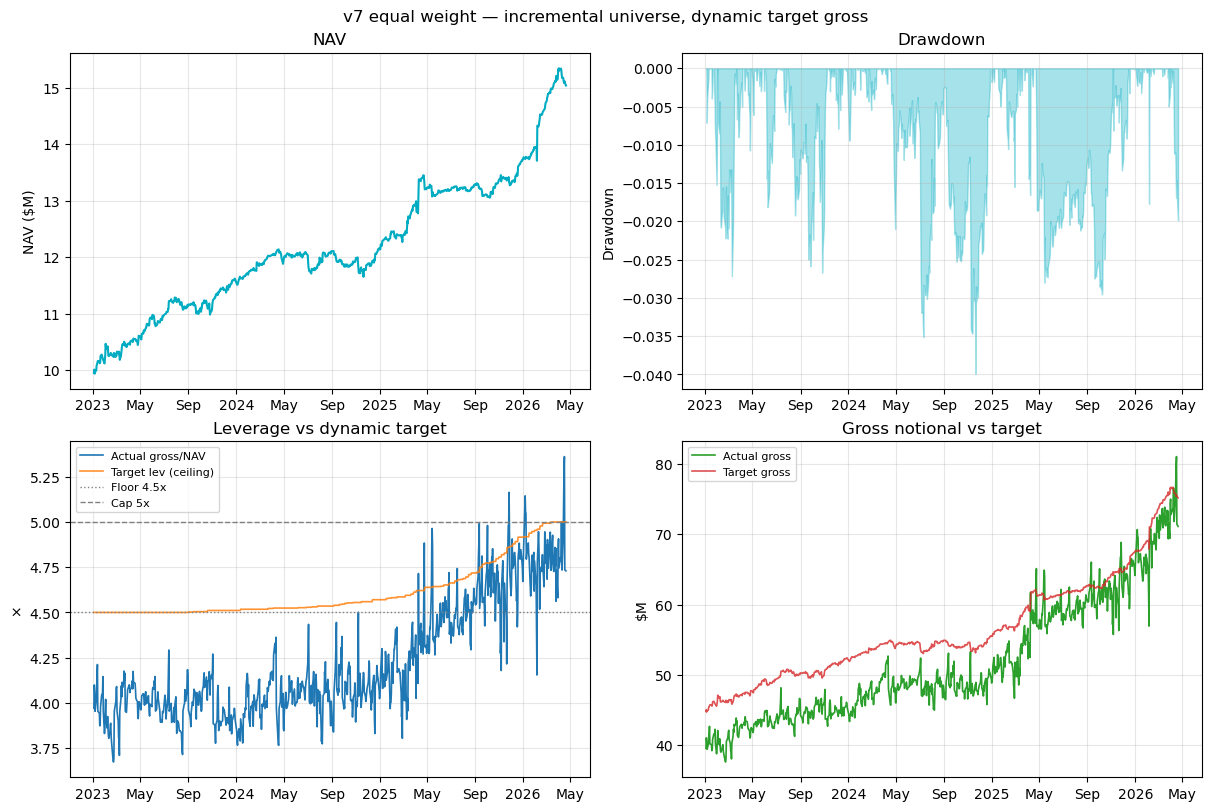

In [12]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

ref = max(LEVERAGE_RUNS)
bt = ALL_BT[ref]
fig, axes = plt.subplots(2, 2, figsize=(12, 8), layout="constrained")
fig.suptitle("v7 equal weight — incremental universe, dynamic target gross")

ax = axes[0, 0]
ax.plot(bt.index, bt["nav"] / 1e6, color="#00ACC1", lw=1.5)
ax.set_ylabel("NAV ($M)"); ax.set_title("NAV"); ax.grid(True, alpha=0.3)

ax = axes[0, 1]
nav = bt["nav"]
dd = (nav - nav.cummax()) / nav.cummax()
ax.fill_between(dd.index, dd, 0, alpha=0.35, color="#00ACC1")
ax.set_ylabel("Drawdown"); ax.set_title("Drawdown"); ax.grid(True, alpha=0.3)

ax = axes[1, 0]
ax.plot(bt.index, bt["actual_leverage"], label="Actual gross/NAV", color="tab:blue", lw=1.2)
ax.plot(bt.index, bt["target_lev"], label="Target lev (ceiling)", color="tab:orange", lw=1.2, alpha=0.85)
ax.axhline(V7_TARGET_LEV_START, color="gray", ls=":", lw=1, label=f"Floor {V7_TARGET_LEV_START}x")
ax.axhline(V7_TARGET_LEV_END, color="gray", ls="--", lw=1, label=f"Cap {V7_TARGET_LEV_END}x")
ax.set_ylabel("×"); ax.set_title("Leverage vs dynamic target"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.plot(bt.index, bt["gross_notional"] / 1e6, label="Actual gross", color="tab:green", lw=1.2)
ax.plot(bt.index, bt["tgt_gross_nav"] / 1e6, label="Target gross", color="tab:red", lw=1.2, alpha=0.8)
ax.set_ylabel("$M"); ax.set_title("Gross notional vs target"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

for ax in axes.flat:
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
plt.show()


,pair,pnl,borrow_paid,net_pnl_after_borrow,avg_gross,ratio,ratio_net
191,HIMS/HMYY,170220.771681,0.000000,170220.771681,2.868301e+05,0.593455,0.593455
42,MSTR/MSTZ,384472.387949,30242.655051,354229.732897,6.548795e+05,0.587089,0.540908
17,COIN/CONL,743981.875954,44712.666901,699269.209053,1.342459e+06,0.554194,0.520887
21,NVDA/NVDL,691503.422521,0.000000,691503.422521,1.366434e+06,0.506064,0.506064
144,MSTR/MTYY,152819.549850,6029.122426,146790.427425,3.205917e+05,0.476680,0.457873
22,META/FBL,538717.245494,0.000000,538717.245494,1.357765e+06,0.396768,0.396768
163,MARA/MAAY,95399.535482,0.000000,95399.535482,2.987259e+05,0.319355,0.319355
19,AMZN/AMZU,405795.530184,0.000000,405795.530184,1.323615e+06,0.306581,0.306581
24,NVDA/NVDU,315843.333981,0.000000,315843.333981,1.064844e+06,0.296610,0.296610
41,MSTR/MSTU,234624.449224,43669.513535,190954.935689,6.592758e+05,0.355882,0.289643


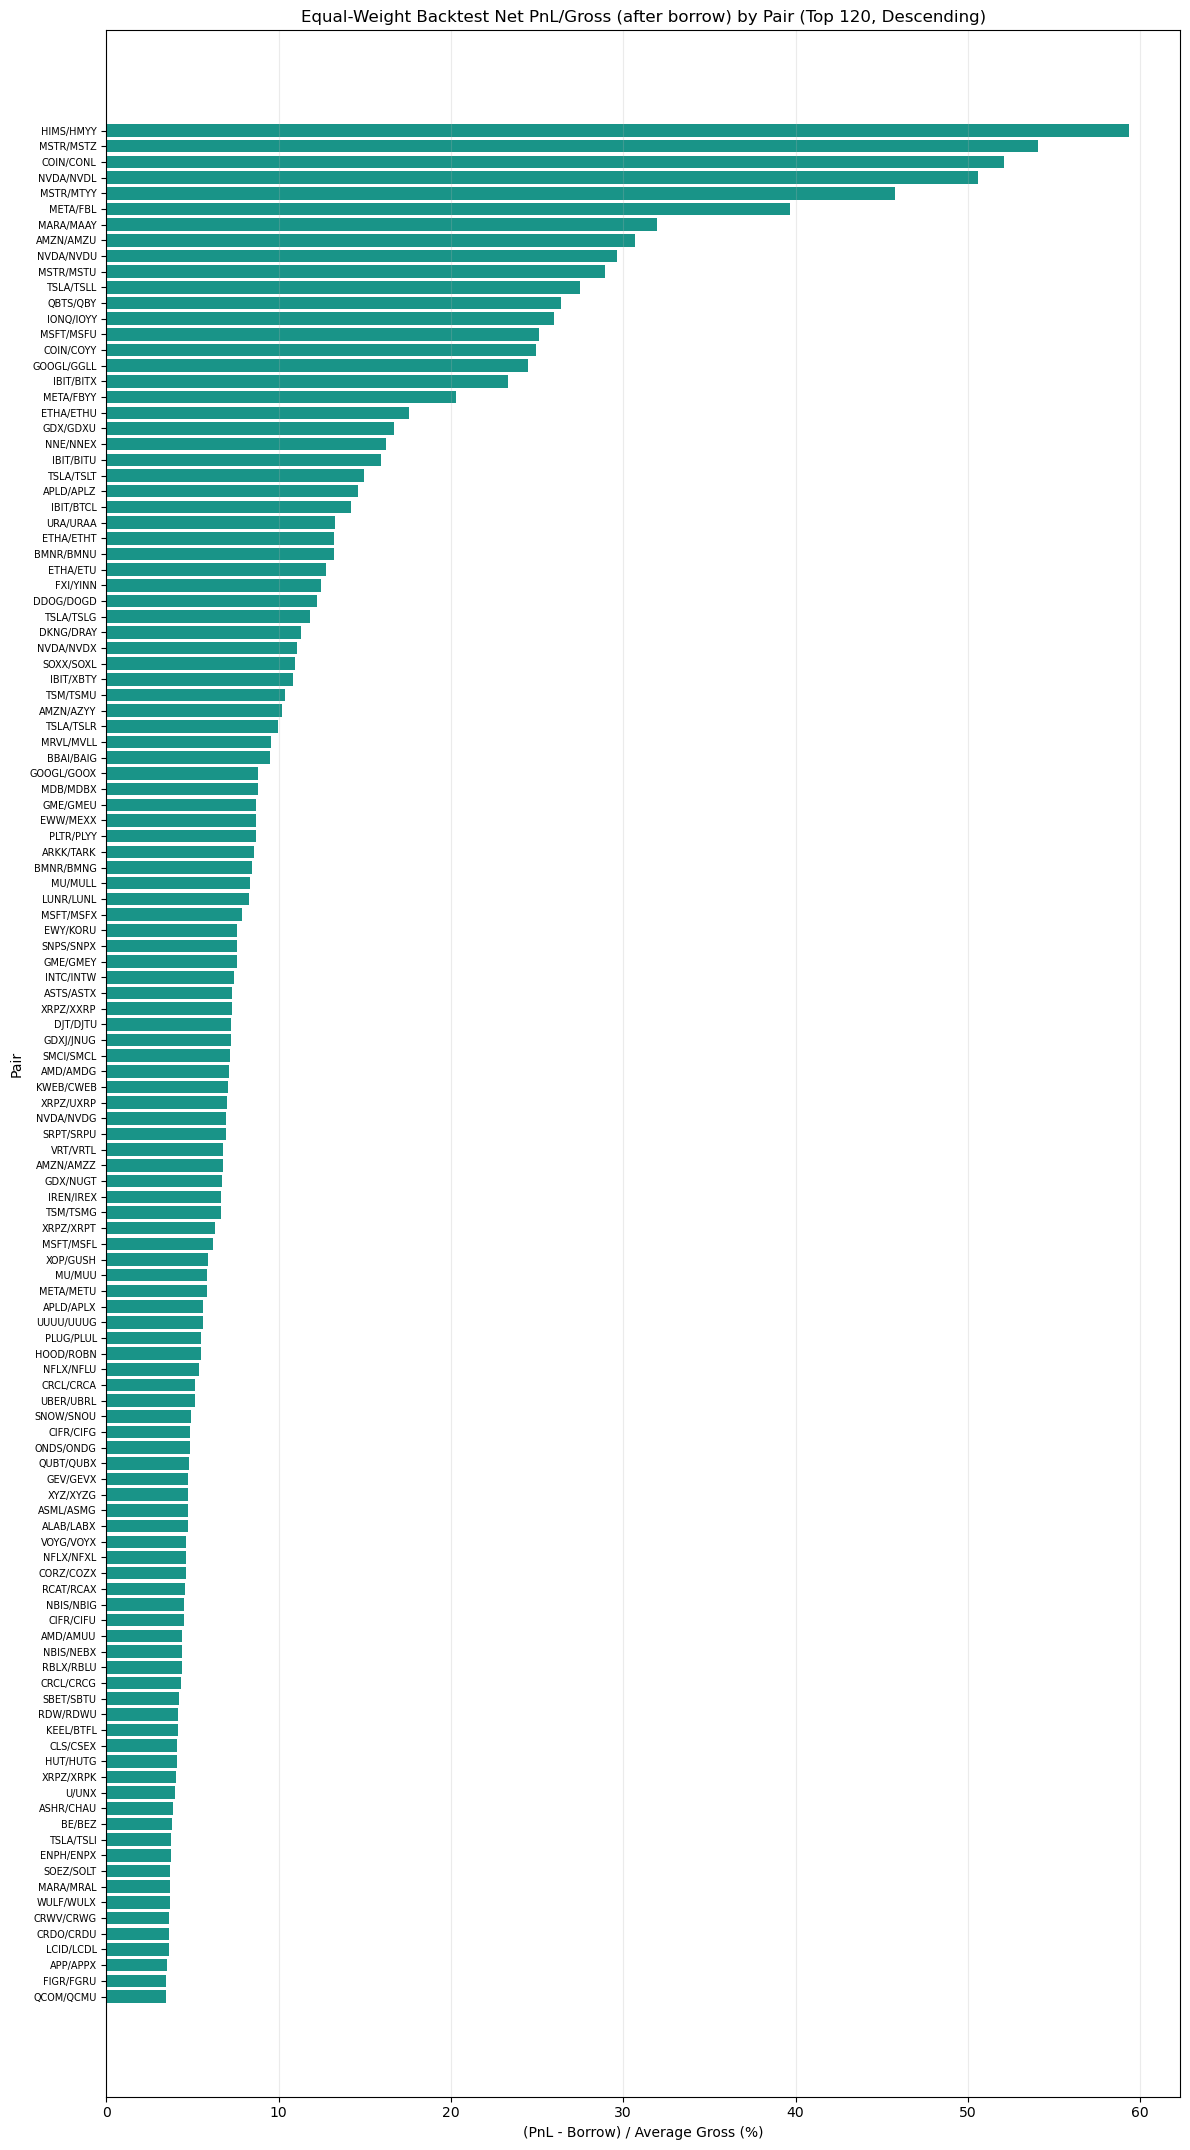

In [13]:
# ---- EW diagnostic: PnL/Gross by pair (descending) ----
import matplotlib.pyplot as plt

# Use saved EW objects when available; otherwise derive from ALL_*.
if "EW_PAIR_PNL" in globals() and "EW_PAIR_GROSS" in globals() and "ref_lev" in globals():
    _ppnl = EW_PAIR_PNL[ref_lev]
    _pgross = EW_PAIR_GROSS[ref_lev]
    _pborrow = EW_PAIR_BORROW[ref_lev] if "EW_PAIR_BORROW" in globals() and ref_lev in EW_PAIR_BORROW else {}
elif "ALL_PAIR_PNL" in globals() and "ALL_PAIR_GROSS" in globals() and "LEVERAGE_RUNS" in globals():
    _ref = max(LEVERAGE_RUNS)
    _ppnl = ALL_PAIR_PNL[_ref]
    _pgross = ALL_PAIR_GROSS[_ref]
    _pborrow = ALL_PAIR_BORROW[_ref] if "ALL_PAIR_BORROW" in globals() and _ref in ALL_PAIR_BORROW else {}
else:
    raise RuntimeError("Run the equal-weight backtest cells first (missing pair PnL/Gross objects).")

rows = []
for etf, d in _ppnl.items():
    pair = f"{d['und']}/{etf}"
    total_pnl = float(d.get("long", 0.0)) + float(d.get("short", 0.0))
    borrow_paid = float(_pborrow.get(etf, 0.0))
    net_pnl = total_pnl - borrow_paid
    avg_gross = float(_pgross[pair].mean()) if pair in _pgross.columns else np.nan
    ratio = total_pnl / avg_gross if (pd.notna(avg_gross) and avg_gross > 0) else np.nan
    ratio_net = net_pnl / avg_gross if (pd.notna(avg_gross) and avg_gross > 0) else np.nan
    rows.append({
        "pair": pair,
        "pnl": total_pnl,
        "borrow_paid": borrow_paid,
        "net_pnl_after_borrow": net_pnl,
        "avg_gross": avg_gross,
        "ratio": ratio,
        "ratio_net": ratio_net,
    })

pnl_gross_df = pd.DataFrame(rows)
pnl_gross_df = pnl_gross_df[pnl_gross_df["ratio_net"].notna()].copy()
if pnl_gross_df.empty:
    raise RuntimeError("No valid net PnL/Gross ratios found.")

pnl_gross_df.sort_values("ratio_net", ascending=False, inplace=True)
display(pnl_gross_df.head(30))

plot_n = min(120, len(pnl_gross_df))
plot_df = pnl_gross_df.head(plot_n).sort_values("ratio_net", ascending=True)

fig_h = min(40, max(10, 0.18 * plot_n))
fig, ax = plt.subplots(figsize=(12, fig_h))
ax.barh(plot_df["pair"], 100 * plot_df["ratio_net"], color="#00897B", alpha=0.9)
ax.set_title(f"Equal-Weight Backtest Net PnL/Gross (after borrow) by Pair (Top {plot_n}, Descending)")
ax.set_xlabel("(PnL - Borrow) / Average Gross (%)")
ax.set_ylabel("Pair")
ax.grid(axis="x", alpha=0.25)
ax.tick_params(axis="y", labelsize=7)

plt.tight_layout()
plt.show()


## v8 Diamond Creek Fund Weights (NET Decay + Shares Cap)

Saves the **equal-weight** run to `EW_*`, writes **`data/backtest/v8_pnl_decay_shares_weights.csv`**, and then re-runs the same engine with those `PAIR_WEIGHTS` loaded as the **Diamond Creek Fund** sizing profile.

Construction summary:
- `decay` component from `data/etf_screened_today.csv` using `decay_score`
- convex blend using `CFG['mix_decay_weight']`
- shares-availability capacity cap from `shares_available` and `CFG['short_avail_use_pct']`
- cap-ramp schedule: constrained names step up over `CFG['cap_ramp_rebals']` rebalances toward max allowed weight


In [14]:
# ---- Sample-book optimizer: PnL/Gross + NET Decay + Shares Cap ----

EW_BT = dict(ALL_BT)
EW_PAIR_PNL = dict(ALL_PAIR_PNL)
EW_PAIR_BORROW = dict(ALL_PAIR_BORROW) if "ALL_PAIR_BORROW" in globals() else {}
EW_PAIR_NET = dict(ALL_PAIR_NET)
EW_PAIR_GROSS = dict(ALL_PAIR_GROSS)

out = Path("data/backtest")
out.mkdir(parents=True, exist_ok=True)
for lev in LEVERAGE_RUNS:
    EW_BT[lev].to_csv(out / f"v8_ew_nav_{lev}x.csv")
print("Equal-weight v8 NAV series saved.")

ref_lev = max(LEVERAGE_RUNS)
ppnl = EW_PAIR_PNL[ref_lev]
ppair_borrow = EW_PAIR_BORROW.get(ref_lev, {}) if "EW_PAIR_BORROW" in globals() else {}
pgross = EW_PAIR_GROSS[ref_lev]

pnl_gross = {}
for etf, d in ppnl.items():
    total_pnl = float(d.get("long", 0.0)) + float(d.get("short", 0.0))
    pair_borrow_paid = float(ppair_borrow.get(etf, 0.0))
    net_pnl_after_borrow = total_pnl - pair_borrow_paid
    col = f"{d['und']}/{etf}"
    avg_gross = float(pgross[col].mean()) if col in pgross.columns else np.nan
    ratio = total_pnl / avg_gross if (pd.notna(avg_gross) and avg_gross > 0) else 0.0
    ratio_net = net_pnl_after_borrow / avg_gross if (pd.notna(avg_gross) and avg_gross > 0) else 0.0
    pnl_gross[etf] = {
        "und": d["und"],
        "pnl": total_pnl,
        "pair_borrow_paid": pair_borrow_paid,
        "net_pnl_after_borrow": net_pnl_after_borrow,
        "avg_gross": avg_gross,
        "ratio": ratio,
        "ratio_net": ratio_net,
    }

# ---- Load screener decay + shares available ----
_preferred_screened_candidates = [
    Path(r"C:/Users/werdn/Documents/Investing/Diamond-Creek-Quant/data/runs/2026-04-15/etf_screened_today.csv"),
    Path(r"C:/Users/werdn/Documents/Investing/Diamond-Creek-Quant/data/etf_screened_today.csv"),
    Path("../data/etf_screened_today.csv"),
    Path("data/etf_screened_today.csv"),
]
screened_path = next((p for p in _preferred_screened_candidates if p.exists()), None)
if screened_path is None:
    run_files = sorted(Path("data/runs").glob("*/etf_screened_today.csv"))
    if not run_files:
        raise FileNotFoundError(
            "Could not find a screener CSV in Diamond-Creek-Quant path, data/etf_screened_today.csv, or data/runs/*/etf_screened_today.csv"
        )
    screened_path = run_files[-1]

screen = pd.read_csv(screened_path)
screen.columns = [str(c).strip() for c in screen.columns]
if "ETF" not in screen.columns:
    raise KeyError("Screener file must include an ETF column")

screen["ETF"] = screen["ETF"].astype(str).str.upper()

decay_col = "net_decay_annual"
if decay_col not in screen.columns:
    raise KeyError("Screener file missing required net_decay_annual column")

screen[decay_col] = pd.to_numeric(screen[decay_col], errors="coerce").fillna(0.0)
if "net_decay_annual" in screen.columns:
    screen["net_decay_annual"] = pd.to_numeric(screen["net_decay_annual"], errors="coerce").fillna(0.0)
else:
    screen["net_decay_annual"] = np.nan

if "shares_available" in screen.columns:
    screen["shares_available"] = pd.to_numeric(screen["shares_available"], errors="coerce")
else:
    screen["shares_available"] = np.nan

# Optional AUM inputs (USD). Prefer explicit AUM, then AUM_M, then vendor asset fields.
if "AUM" in screen.columns:
    screen["aum_usd"] = pd.to_numeric(screen["AUM"], errors="coerce")
elif "AUM_M" in screen.columns:
    screen["aum_usd"] = pd.to_numeric(screen["AUM_M"], errors="coerce") * 1e6
elif "totalAssets" in screen.columns:
    screen["aum_usd"] = pd.to_numeric(screen["totalAssets"], errors="coerce")
elif "netAssets" in screen.columns:
    screen["aum_usd"] = pd.to_numeric(screen["netAssets"], errors="coerce")
else:
    screen["aum_usd"] = np.nan

screen["aum_usd"] = pd.to_numeric(screen["aum_usd"], errors="coerce")
screen.loc[screen["aum_usd"] <= 0, "aum_usd"] = np.nan
screen["aum_source"] = np.where(screen["aum_usd"].notna(), "screen", "missing")

# Backfill missing AUM from yfinance with a local cache.
missing_aum = screen["aum_usd"].isna()
if missing_aum.any():
    try:
        import yfinance as yf

        aum_cache_path = Path("data/backtest/etf_aum_cache.csv")
        aum_cache_path.parent.mkdir(parents=True, exist_ok=True)
        if aum_cache_path.exists():
            aum_cache = pd.read_csv(aum_cache_path)
            if not {"ETF", "aum_usd"}.issubset(aum_cache.columns):
                aum_cache = pd.DataFrame(columns=["ETF", "aum_usd"])
        else:
            aum_cache = pd.DataFrame(columns=["ETF", "aum_usd"])

        if not aum_cache.empty:
            aum_cache["ETF"] = aum_cache["ETF"].astype(str).str.upper().str.strip()
            aum_cache["aum_usd"] = pd.to_numeric(aum_cache["aum_usd"], errors="coerce")
            cache_map = dict(zip(aum_cache["ETF"], aum_cache["aum_usd"]))
            from_cache = screen["ETF"].map(cache_map)
            use_cache = missing_aum & from_cache.notna() & (from_cache > 0)
            screen.loc[use_cache, "aum_usd"] = from_cache[use_cache]
            screen.loc[use_cache, "aum_source"] = "cache"

        still_missing = screen["aum_usd"].isna()
        if still_missing.any():
            fetch_syms = sorted(screen.loc[still_missing, "ETF"].dropna().astype(str).str.upper().unique())
            fetched = []
            for t in fetch_syms:
                q = t.replace(".", "-")
                val = np.nan
                try:
                    tk = yf.Ticker(q)
                    fi = getattr(tk, "fast_info", {}) or {}
                    if isinstance(fi, dict):
                        for k in ("total_assets", "totalAssets", "net_assets", "netAssets", "market_cap", "marketCap"):
                            v = fi.get(k)
                            if v is not None and pd.notna(v) and float(v) > 0:
                                val = float(v)
                                break
                    if pd.isna(val):
                        info = tk.info or {}
                        for k in ("totalAssets", "netAssets", "fundAssets", "marketCap"):
                            v = info.get(k)
                            if v is not None and pd.notna(v) and float(v) > 0:
                                val = float(v)
                                break
                except Exception:
                    pass

                if pd.notna(val) and val > 0:
                    fetched.append((t, float(val)))

            if fetched:
                fetched_df = pd.DataFrame(fetched, columns=["ETF", "aum_usd"])
                fetch_map = dict(zip(fetched_df["ETF"], fetched_df["aum_usd"]))
                from_fetch = screen["ETF"].map(fetch_map)
                use_fetch = screen["aum_usd"].isna() & from_fetch.notna() & (from_fetch > 0)
                screen.loc[use_fetch, "aum_usd"] = from_fetch[use_fetch]
                screen.loc[use_fetch, "aum_source"] = "yfinance"

                aum_cache = pd.concat([aum_cache, fetched_df], ignore_index=True)
                aum_cache = aum_cache.dropna(subset=["ETF"]).copy()
                aum_cache["ETF"] = aum_cache["ETF"].astype(str).str.upper().str.strip()
                aum_cache["aum_usd"] = pd.to_numeric(aum_cache["aum_usd"], errors="coerce")
                aum_cache = aum_cache[aum_cache["aum_usd"].notna() & (aum_cache["aum_usd"] > 0)]
                aum_cache = aum_cache.drop_duplicates(subset=["ETF"], keep="last").sort_values("ETF")
                aum_cache.to_csv(aum_cache_path, index=False)
    except Exception:
        pass

# Historical average shares_available by ticker (mean over each ticker's observed days).
runs_candidates = [
    Path("../data/runs"),
    Path("data/runs"),
    Path.cwd() / "../data/runs",
    Path.cwd() / "data/runs",
    Path.cwd().parent / "data/runs",
]
runs_root = None
for cand in runs_candidates:
    c = cand.resolve()
    if c.exists():
        runs_root = c
        break

shares_hist = []
if runs_root is not None:
    run_files = sorted(runs_root.glob("*/etf_screened_today.csv"))
    for rf in run_files:
        try:
            d = pd.read_csv(rf)
        except Exception:
            continue
        if "ETF" not in d.columns:
            continue
        d["ETF"] = d["ETF"].astype(str).str.upper()
        if "shares_available" in d.columns:
            d["shares_available"] = pd.to_numeric(d["shares_available"], errors="coerce")
        else:
            d["shares_available"] = np.nan
        d = d[["ETF", "shares_available"]].rename(columns={"ETF": "etf"})
        d["run_date"] = rf.parent.name
        shares_hist.append(d)

if shares_hist:
    sh = pd.concat(shares_hist, ignore_index=True)
    sh_agg = (
        sh.groupby("etf", dropna=False)["shares_available"]
        .agg(shares_available_avg="mean", shares_obs="count")
        .reset_index()
    )
    sh_agg["shares_obs"] = sh_agg["shares_obs"].astype(int)
    screen = screen.merge(sh_agg, left_on="ETF", right_on="etf", how="left")
    screen.drop(columns=["etf"], inplace=True)
else:
    screen["shares_available_avg"] = np.nan
    screen["shares_obs"] = 0

screen["shares_obs"] = pd.to_numeric(screen.get("shares_obs"), errors="coerce").fillna(0).astype(int)
screen["shares_available_for_cap"] = np.where(
    screen["shares_obs"] > 0,
    screen["shares_available_avg"],
    screen["shares_available"],
)

# Bucket-2/Bucket-3 supply override: for whitelist + bucket3 ETFs, use Supply from etfs2.csv.
_cfg_wl = set()
_cfg_candidates = [Path("config/strategy_config.yml"), Path("../config/strategy_config.yml")]
_cfg_path = next((p for p in _cfg_candidates if p.exists()), None)
if _cfg_path is not None:
    try:
        import yaml
        with open(_cfg_path, "r", encoding="utf-8") as f:
            _cfg_obj = yaml.safe_load(f) or {}
        _wl = ((((_cfg_obj.get("portfolio", {}) or {}).get("sleeves", {}) or {}).get("whitelist_stock", {}) or {}).get("universe", {}).get("etfs", []))
        _cfg_wl = {str(x).upper().strip().replace(".", "-") for x in (_wl or []) if str(x).strip()}
    except Exception:
        _cfg_wl = set()

_b3_etfs = {str(x).upper().strip().replace(".", "-") for x in (globals().get("BUCKET3_ETFS", set()) or set())}
_cap_override_universe = _cfg_wl.union(_b3_etfs)

_supply_paths = [
    Path(r"C:/Users/werdn/Downloads/etfs2.csv"),
    Path("data/backtest/etfs2.csv"),
    Path("../data/backtest/etfs2.csv"),
]
_supply_path = next((p for p in _supply_paths if p.exists()), None)
_supply_override_n = 0
_supply_override_b3_n = 0
if _supply_path is not None:
    try:
        _sup = pd.read_csv(_supply_path)
        _sup.columns = [str(c).strip() for c in _sup.columns]
        _ticker_col = next((c for c in ["Ticker", "ETF", "Symbol", "ticker", "etf", "symbol"] if c in _sup.columns), None)
        _supply_col = next((c for c in ["Supply", "supply"] if c in _sup.columns), None)
        if (_ticker_col is not None) and (_supply_col is not None):
            _tmp_sup = _sup[[_ticker_col, _supply_col]].copy()
            _tmp_sup[_ticker_col] = _tmp_sup[_ticker_col].astype(str).str.upper().str.strip().str.replace(".", "-", regex=False)
            _tmp_sup[_supply_col] = pd.to_numeric(_tmp_sup[_supply_col], errors="coerce")
            _tmp_sup = _tmp_sup[_tmp_sup[_ticker_col].ne("") & _tmp_sup[_supply_col].notna() & (_tmp_sup[_supply_col] > 0)]
            _tmp_sup = _tmp_sup.drop_duplicates(subset=[_ticker_col], keep="last")
            _sup_map = dict(zip(_tmp_sup[_ticker_col], _tmp_sup[_supply_col]))

            _etf_norm = screen["ETF"].astype(str).str.upper().str.replace(".", "-", regex=False)
            _is_cap_ov = _etf_norm.isin(_cap_override_universe)
            _is_b3 = _etf_norm.isin(_b3_etfs)
            _sup_ser = _etf_norm.map(_sup_map)
            _ov_mask = _is_cap_ov & _sup_ser.notna() & (_sup_ser > 0)
            _supply_override_n = int(_ov_mask.sum())
            _supply_override_b3_n = int((_ov_mask & _is_b3).sum())
            if _supply_override_n > 0:
                screen.loc[_ov_mask, "shares_available"] = _sup_ser[_ov_mask]
                screen.loc[_ov_mask, "shares_available_avg"] = _sup_ser[_ov_mask]
                screen.loc[_ov_mask, "shares_available_for_cap"] = _sup_ser[_ov_mask]
                screen.loc[_ov_mask, "shares_obs"] = np.maximum(screen.loc[_ov_mask, "shares_obs"], 1)

            _cap_missing_sup = sorted(_cap_override_universe.difference(set(_tmp_sup[_ticker_col].tolist())))
            if _cap_missing_sup:
                print(f"[weights] Cap-override ETFs missing Supply in etfs2.csv: {_cap_missing_sup}")
            _b3_missing_sup = sorted(_b3_etfs.difference(set(_tmp_sup[_ticker_col].tolist())))
            if _b3_missing_sup:
                print(f"[weights] Bucket3 ETFs missing Supply in etfs2.csv: {_b3_missing_sup}")
    except Exception as _e:
        print(f"[weights] Supply override skipped ({_e})")

if _supply_path is not None:
    print(f"[weights] Supply override source: {_supply_path} | cap-overridden tickers: {_supply_override_n} | bucket3 overridden: {_supply_override_b3_n}")

# Historical average borrow by ticker across data/runs snapshots.
borrow_hist = []
borrow_col_priority = ["borrow_net_annual", "borrow_current", "borrow_fee_annual"]
if runs_root is not None:
    snapshot_files = []
    for d in sorted(runs_root.glob("*")):
        if not d.is_dir():
            continue
        f_screen = d / "etf_screened_today.csv"
        f_trades = d / "proposed_trades.csv"
        if f_screen.exists():
            snapshot_files.append(f_screen)
        elif f_trades.exists():
            snapshot_files.append(f_trades)

    for p in [Path("data/etf_screened_today.csv"), Path("../data/etf_screened_today.csv")]:
        if p.exists():
            snapshot_files.append(p)
            break

    for rf in snapshot_files:
        try:
            d = pd.read_csv(rf)
        except Exception:
            continue
        if "ETF" not in d.columns:
            continue
        col = next((c for c in borrow_col_priority if c in d.columns), None)
        if col is None:
            continue
        b = d[["ETF", col]].copy()
        b["ETF"] = b["ETF"].astype(str).str.upper().str.strip()
        b["borrow_rate"] = pd.to_numeric(b[col], errors="coerce")
        b = b[b["ETF"].ne("") & b["borrow_rate"].notna()]
        b = b[np.isfinite(b["borrow_rate"])].copy()
        borrow_hist.append(b[["ETF", "borrow_rate"]])

if borrow_hist:
    bh = pd.concat(borrow_hist, ignore_index=True)

    def _trimmed_mean_drop2(s: pd.Series) -> float:
        x = pd.to_numeric(s, errors="coerce").dropna().sort_values()
        if len(x) <= 4:
            return float(x.mean()) if len(x) else np.nan
        return float(x.iloc[2:-2].mean())

    bh_mean = bh.groupby("ETF")["borrow_rate"].apply(_trimmed_mean_drop2).rename("borrow_avg_annual")
    bh_obs = bh.groupby("ETF")["borrow_rate"].size().rename("borrow_obs")
    bh_agg = pd.concat([bh_mean, bh_obs], axis=1).reset_index()
    screen = screen.merge(bh_agg, on="ETF", how="left")
else:
    screen["borrow_avg_annual"] = np.nan
    screen["borrow_obs"] = 0

for c in ["borrow_current", "borrow_net_annual", "blended_gross_decay", "expected_gross_decay_annual", "gross_decay_annual"]:
    if c in screen.columns:
        screen[c] = pd.to_numeric(screen[c], errors="coerce")
    else:
        screen[c] = np.nan

screen["borrow_avg_annual"] = pd.to_numeric(screen.get("borrow_avg_annual"), errors="coerce")
screen["borrow_obs"] = pd.to_numeric(screen.get("borrow_obs"), errors="coerce").fillna(0).astype(int)

# v10 sample-book mode: use ONLY spreadsheet net borrow for optimization.
# Keep a raw borrow estimate flag so optimizer universe can exclude fallback-only names.
if "SAMPLE_BOOK_BORROW_MAP" in globals() and isinstance(SAMPLE_BOOK_BORROW_MAP, dict) and SAMPLE_BOOK_BORROW_MAP:
    _sample_map = {str(k).upper(): float(v) for k, v in SAMPLE_BOOK_BORROW_MAP.items()}
    screen["borrow_estimate_raw"] = screen["ETF"].map(_sample_map)
    screen["borrow_estimate_available"] = screen["borrow_estimate_raw"].notna()
    screen["borrow_for_weight"] = screen["borrow_estimate_raw"]
    _miss = int(screen["borrow_for_weight"].isna().sum())
    if _miss:
        screen["borrow_for_weight"] = screen["borrow_for_weight"].fillna(float(CFG.get("fallback_borrow_rate", 0.02)))
        print(f"[weights] sample-book borrow missing for {_miss} ETFs; fallback applied")
else:
    # Fallback behavior if sample-book borrow is unavailable.
    screen["borrow_estimate_raw"] = (
        screen["borrow_avg_annual"]
        .combine_first(screen["borrow_current"])
        .combine_first(screen["borrow_net_annual"])
    )
    screen["borrow_estimate_available"] = screen["borrow_estimate_raw"].notna()
    screen["borrow_for_weight"] = screen["borrow_estimate_raw"].fillna(float(CFG.get("fallback_borrow_rate", 0.02)))

# Adapted from daily_screener: decay_score = blended_gross_decay - borrow.
# In v10 sample-book mode, borrow comes directly from spreadsheet net borrow.
screen["gross_decay_for_weight"] = (
    screen["blended_gross_decay"]
    .combine_first(screen["expected_gross_decay_annual"])
    .combine_first(screen["gross_decay_annual"])
)
screen["decay_score_hist_borrow"] = np.where(
    screen["gross_decay_for_weight"].notna(),
    screen["gross_decay_for_weight"] - screen["borrow_for_weight"],
    np.nan,
)

# Final non-NA AUM fill: underlying median, then global median.
known_aum = screen.loc[screen["aum_usd"].notna() & (screen["aum_usd"] > 0), "aum_usd"]
global_med_aum = float(known_aum.median()) if len(known_aum) else np.nan

if "Underlying" in screen.columns:
    und_med = (
        screen.loc[screen["aum_usd"].notna() & (screen["aum_usd"] > 0)]
        .groupby("Underlying", dropna=False)["aum_usd"]
        .median()
    )
    und_fill = screen["Underlying"].map(und_med)
    use_und = screen["aum_usd"].isna() & und_fill.notna() & (und_fill > 0)
    screen.loc[use_und, "aum_usd"] = und_fill[use_und]
    screen.loc[use_und, "aum_source"] = "underlying_median"

if pd.notna(global_med_aum) and global_med_aum > 0:
    use_global = screen["aum_usd"].isna()
    screen.loc[use_global, "aum_usd"] = global_med_aum
    screen.loc[use_global, "aum_source"] = "global_median"

# Hard fallback to avoid NA in reporting tables.
use_zero = screen["aum_usd"].isna()
if use_zero.any():
    screen.loc[use_zero, "aum_usd"] = 0.0
    screen.loc[use_zero, "aum_source"] = "fallback_zero"

screen["aum_usd"] = pd.to_numeric(screen["aum_usd"], errors="coerce").fillna(0.0)

# Keep sizing signal from screener net decay.

screener_map = screen.set_index("ETF")[[
    decay_col,
    "gross_decay_for_weight",
    "borrow_for_weight",
    "borrow_avg_annual",
    "borrow_obs",
    "net_decay_annual",
    "shares_available",
    "shares_available_avg",
    "shares_available_for_cap",
    "shares_obs",
    "aum_usd",
    "aum_source",
]].to_dict("index")

pw = CFG.get("weight_power", 2)
decay_pw = CFG.get("decay_weight_power", 1.25)
mix_decay = float(CFG.get("mix_decay_weight", 0.45))
mix_decay = min(1.0, max(0.0, mix_decay))
# Penalize pairs that show larger simulated max drawdown relative to average gross.
max_dd_penalty_weight = float(CFG.get("max_dd_penalty_weight", 0.20))
max_dd_penalty_weight = max(0.0, max_dd_penalty_weight)

if "Beta" not in screen.columns:
    raise KeyError("Screener file must include a Beta column for optimizer universe gating")
screen["Beta"] = pd.to_numeric(screen["Beta"], errors="coerce")
screen["beta_abs"] = screen["Beta"].abs()

# Optimizer universe rule (v15):
# - core bucket: beta > 1.5 + borrow estimate available
# - whitelist bucket: strategy_config.yml whitelist ETFs
# - bucket3: fixed inverse-ETF pairs with short-inverse + short-underlying execution
_eligible_screen = screen[
    (screen["beta_abs"] > 1.5)
    & (screen["borrow_estimate_available"] == True)
].copy()
_eligible_etfs = set(_eligible_screen["ETF"].astype(str).str.upper().tolist())

_cfg_whitelist = set()
_cfg_candidates = [Path("config/strategy_config.yml"), Path("../config/strategy_config.yml")]
_cfg_path = next((p for p in _cfg_candidates if p.exists()), None)
core_bucket_target = 0.80
whitelist_bucket_target = float(globals().get("BUCKET2_BUCKET_TARGET", 0.10))
bucket3_bucket_target = float(globals().get("BUCKET3_BUCKET_TARGET", 0.10))
if _cfg_path is not None:
    try:
        import yaml
        with open(_cfg_path, "r", encoding="utf-8") as f:
            _cfg_obj = yaml.safe_load(f) or {}
        _sleeves = ((_cfg_obj.get("portfolio", {}) or {}).get("sleeves", {}) or {})
        _wl = (((_sleeves.get("whitelist_stock", {}) or {}).get("universe", {}) or {}).get("etfs", []) or [])
        _cfg_whitelist = {str(x).upper().strip().replace(".", "-") for x in _wl if str(x).strip()}
        core_bucket_target = float(((_sleeves.get("core_leveraged", {}) or {}).get("target_weight", 0.80)))
        # Bucket targets are enforced in this notebook cell; do not override from config.
    except Exception:
        pass
if not _cfg_whitelist:
    _wl = globals().get("WHITELIST_ETFS", set())
    _cfg_whitelist = {str(x).upper().strip().replace(".", "-") for x in (_wl or set())}

_b3_etfs = {str(x).upper().strip().replace(".", "-") for x in (globals().get("BUCKET3_ETFS", set()) or set())}
whitelist_bucket_target = min(1.0, max(0.0, whitelist_bucket_target))
bucket3_bucket_target = min(1.0, max(0.0, bucket3_bucket_target))
core_bucket_target = max(0.0, 1.0 - whitelist_bucket_target - bucket3_bucket_target)

_screen_etfs = set(screen["ETF"].astype(str).str.upper().tolist())
_wl_available = sorted(_screen_etfs.intersection(_cfg_whitelist))
_b3_available = sorted(_screen_etfs.intersection(_b3_etfs))
etfs_all = sorted(set(str(e).upper() for e in pnl_gross.keys()).union(_wl_available).union(_b3_available))
wl_etfs = [e for e in etfs_all if str(e).upper().replace(".", "-") in _cfg_whitelist]
b3_etfs = [e for e in etfs_all if str(e).upper().replace(".", "-") in _b3_etfs]
core_etfs = [
    e for e in etfs_all
    if (str(e).upper() in _eligible_etfs)
    and (str(e).upper().replace(".", "-") not in _cfg_whitelist)
    and (str(e).upper().replace(".", "-") not in _b3_etfs)
]
_core_set = set(core_etfs)
_wl_set = set(wl_etfs)
etfs = core_etfs + [e for e in wl_etfs if e not in _core_set] + [e for e in b3_etfs if e not in _core_set and e not in _wl_set]
if not etfs:
    raise RuntimeError("No ETFs satisfy optimizer universe rule for v15 sleeves")

if wl_etfs and b3_etfs:
    # Hard enforce requested sleeve gross budgets.
    whitelist_bucket_target = 0.10
    bucket3_bucket_target = 0.10
    core_bucket_target = 0.80 if core_etfs else 0.0
elif not core_etfs and (wl_etfs or b3_etfs):
    rem = whitelist_bucket_target + bucket3_bucket_target
    if rem > 0:
        whitelist_bucket_target = whitelist_bucket_target / rem
        bucket3_bucket_target = bucket3_bucket_target / rem
    core_bucket_target = 0.0
elif core_etfs and not wl_etfs and not b3_etfs:
    core_bucket_target = 1.0
    whitelist_bucket_target = 0.0
    bucket3_bucket_target = 0.0

print(
    f"[weights] Optimizer universe: {len(etfs)}/{len(etfs_all)} ETFs "
    f"(core beta>1.5+borrow={len(core_etfs)}, whitelist={len(wl_etfs)}, bucket3={len(b3_etfs)})"
)
print(
    f"[weights] Sleeve targets -> core: {core_bucket_target:.1%}, whitelist: {whitelist_bucket_target:.1%}, bucket3: {bucket3_bucket_target:.1%}"
)
pair_mdd_to_gross_full = pd.Series(0.0, index=etfs, dtype=float)
pair_mdd_to_gross_recent = pd.Series(0.0, index=etfs, dtype=float)
penalty_start = pd.to_datetime(CFG.get("max_dd_penalty_start", "2024-01-01"), errors="coerce")
penalty_recent_weight = float(CFG.get("max_dd_penalty_recent_weight", 0.70))
penalty_recent_weight = min(1.0, max(0.0, penalty_recent_weight))

if "ALL_PAIR_DAILY" in globals() and isinstance(ALL_PAIR_DAILY, dict) and ref_lev in ALL_PAIR_DAILY:
    _pday = ALL_PAIR_DAILY.get(ref_lev)
    if isinstance(_pday, pd.DataFrame) and (not _pday.empty) and {"etf", "date", "daily_pair_net_pnl_usd"}.issubset(_pday.columns):
        _tmp = _pday[["etf", "date", "daily_pair_net_pnl_usd"]].copy()
        _tmp["etf"] = _tmp["etf"].astype(str).str.upper()
        _tmp["date"] = pd.to_datetime(_tmp["date"], errors="coerce")
        _tmp["daily_pair_net_pnl_usd"] = pd.to_numeric(_tmp["daily_pair_net_pnl_usd"], errors="coerce").fillna(0.0)
        _tmp = _tmp.dropna(subset=["date"]).sort_values("date")

        for _etf in etfs:
            _sub = _tmp[_tmp["etf"] == _etf]
            if _sub.empty:
                continue

            _avg_g = float(pnl_gross.get(_etf, {}).get("avg_gross", np.nan))
            if not (pd.notna(_avg_g) and _avg_g > 0):
                continue

            _cum_full = _sub["daily_pair_net_pnl_usd"].cumsum()
            _peak_full = _cum_full.cummax()
            _dd_usd_full = float((_peak_full - _cum_full).max()) if len(_cum_full) else 0.0
            pair_mdd_to_gross_full[_etf] = _dd_usd_full / _avg_g

            if pd.notna(penalty_start):
                _sub_recent = _sub[_sub["date"] >= penalty_start]
            else:
                _sub_recent = _sub
            if not _sub_recent.empty:
                _cum_recent = _sub_recent["daily_pair_net_pnl_usd"].cumsum()
                _peak_recent = _cum_recent.cummax()
                _dd_usd_recent = float((_peak_recent - _cum_recent).max()) if len(_cum_recent) else 0.0
                pair_mdd_to_gross_recent[_etf] = _dd_usd_recent / _avg_g

pair_mdd_to_gross = (
    (1.0 - penalty_recent_weight) * pair_mdd_to_gross_full
    + penalty_recent_weight * pair_mdd_to_gross_recent
)

pnl_component = pd.Series(
    {
        etf: max(
            0.0,
            float((pnl_gross.get(etf, {}) or {}).get("ratio_net", 0.0)) - max_dd_penalty_weight * float(pair_mdd_to_gross.get(etf, 0.0)),
        ) ** pw
        for etf in etfs
    },
    dtype=float,
)
decay_component = pd.Series(
    {etf: max(0.0, float(screener_map.get(etf, {}).get(decay_col, 0.0))) ** decay_pw for etf in etfs},
    dtype=float,
)

if pnl_component.sum() <= 0:
    pnl_component[:] = 1.0
if decay_component.sum() <= 0:
    decay_component[:] = 1.0

pnl_norm = pnl_component / pnl_component.sum()
decay_norm = decay_component / decay_component.sum()
combined_signal = (1.0 - mix_decay) * pnl_norm + mix_decay * decay_norm
raw_weight = combined_signal / combined_signal.sum()

ranked = sorted(etfs, key=lambda e: float(combined_signal.get(e, 0.0)), reverse=True)

# Optional concentration tilt: increase allocation to largest signals.
conc_pw = float(CFG.get("position_concentration_power", 1.0))
if conc_pw > 1.0:
    raw_weight = raw_weight.pow(conc_pw)
    if raw_weight.sum() > 0:
        raw_weight = raw_weight / raw_weight.sum()

# Apply sleeve budget split (core + whitelist + bucket3).
_core_idx = [e for e in core_etfs if e in raw_weight.index]
_wl_idx = [e for e in wl_etfs if e in raw_weight.index]
_b3_idx = [e for e in b3_etfs if e in raw_weight.index]

_parts = []
if _core_idx:
    _core_w = raw_weight.loc[_core_idx]
    _core_w = _core_w / _core_w.sum() if _core_w.sum() > 0 else pd.Series(1.0 / len(_core_idx), index=_core_idx)
    _parts.append(_core_w * core_bucket_target)
if _wl_idx:
    _wl_w = raw_weight.loc[_wl_idx]
    _wl_w = _wl_w / _wl_w.sum() if _wl_w.sum() > 0 else pd.Series(1.0 / len(_wl_idx), index=_wl_idx)
    _parts.append(_wl_w * whitelist_bucket_target)
if _b3_idx:
    _b3_w = raw_weight.loc[_b3_idx]
    _b3_w = _b3_w / _b3_w.sum() if _b3_w.sum() > 0 else pd.Series(1.0 / len(_b3_idx), index=_b3_idx)
    _parts.append(_b3_w * bucket3_bucket_target)

if _parts:
    raw_weight = pd.concat(_parts).reindex(raw_weight.index).fillna(0.0)
    if raw_weight.sum() > 0:
        raw_weight = raw_weight / raw_weight.sum()

# ---- Capacity caps from shares_available ----
beta_map = {etf: abs(bv) for etf, _, bv in UNIVERSE}
ref_date = EW_BT[ref_lev].index[-1]
ref_tgt_gross = float(EW_BT[ref_lev]["tgt_gross_nav"].iloc[-1])
short_avail_use_pct = float(CFG.get("short_avail_use_pct", 0.10))
max_pair_weight_cap = float(CFG.get("max_pair_weight_cap", 0.075))
max_underlying_weight_cap = float(CFG.get("max_underlying_weight_cap", 0.15))
missing_shares_cap = float(CFG.get("missing_shares_cap", 0.01))

# For table translation from weights -> dollars.
assumed_nav_usd = float(CFG.get("capital_usd", 10_000_000))
assumed_target_lev = float(EW_BT[ref_lev]["target_lev"].iloc[-1]) if "target_lev" in EW_BT[ref_lev].columns else float(V7_TARGET_LEV_END)
assumed_target_gross_usd = assumed_nav_usd * assumed_target_lev

cap_frac = {}
for etf in etfs:
    babs = max(1e-9, beta_map.get(etf, 2.0))
    hr = 1.0 / babs
    short_frac = hr / (1.0 + hr)

    px_ser = PRICES.get(etf)
    px_e = float(px_ser.asof(ref_date)) if px_ser is not None else np.nan
    sh_av = screener_map.get(etf, {}).get("shares_available_for_cap", np.nan)

    if pd.isna(sh_av) or sh_av <= 0 or pd.isna(px_e) or px_e <= 0:
        cap = missing_shares_cap
    else:
        cap_shares = float(sh_av) * short_avail_use_pct
        cap = (cap_shares * px_e) / max(1.0, ref_tgt_gross * short_frac)

    cap_frac[etf] = min(max_pair_weight_cap, max(0.0, cap))

cap_s = pd.Series(cap_frac, dtype=float)

# If strict caps are infeasible, minimally relax toward desired weights.
if cap_s.sum() < 1.0:
    cap_s = np.maximum(cap_s, raw_weight)


def project_to_capped_simplex(desired: pd.Series, caps: pd.Series, tol: float = 1e-12) -> pd.Series:
    """Project desired weights onto {w>=0, w<=caps, sum(w)=1}.

    This keeps final weights <= caps whenever feasible.
    """
    desired = desired.astype(float).copy()
    caps = caps.astype(float).copy().clip(lower=0.0)

    if desired.sum() <= 0:
        desired[:] = 1.0
    desired = desired / desired.sum()

    # Ensure feasibility (sum caps must be >= 1).
    if caps.sum() < 1.0:
        caps = np.maximum(caps, desired)

    w = pd.Series(0.0, index=desired.index)
    free = list(desired.index)
    remaining = 1.0

    while free and remaining > tol:
        base = desired.loc[free]
        if base.sum() <= 0:
            trial = pd.Series(remaining / len(free), index=free)
        else:
            trial = remaining * base / base.sum()

        hit = trial > (caps.loc[free] + tol)
        if not hit.any():
            w.loc[free] = trial
            remaining = 0.0
            break

        hit_idx = list(trial.index[hit])
        w.loc[hit_idx] = caps.loc[hit_idx]
        remaining = 1.0 - float(w.sum())
        free = [k for k in free if k not in hit_idx]

    # Safety: fill any tiny remainder by available headroom.
    if remaining > tol and free:
        room = (caps.loc[free] - w.loc[free]).clip(lower=0.0)
        if room.sum() > tol:
            w.loc[free] += remaining * room / room.sum()

    w = w.clip(lower=0.0)
    if w.sum() <= 0:
        w = desired.copy()

    w = w / w.sum()
    w = np.minimum(w, caps)

    # Final small renorm without violating caps.
    rem = 1.0 - float(w.sum())
    if rem > tol:
        room = (caps - w).clip(lower=0.0)
        if room.sum() > tol:
            w += rem * room / room.sum()
    if w.sum() > 0:
        w = w / w.sum()
    return w


final_weight_pair = project_to_capped_simplex(raw_weight, cap_s)
und_s = pd.Series({etf: str(pnl_gross.get(etf, {}).get("und", "UNKNOWN")) for etf in etfs}, dtype="object")


def project_to_pair_and_underlying_caps(
    desired: pd.Series,
    pair_caps: pd.Series,
    und_map: pd.Series,
    underlying_cap: float,
    tol: float = 1e-12,
    max_iter: int = 200,
) -> pd.Series:
    """Project desired weights onto:
    - per-pair caps:     0 <= w_i <= pair_caps_i
    - per-underlying cap: sum_{i in underlying} w_i <= underlying_cap
    - budget: sum_i w_i = 1
    """
    w = desired.astype(float).copy().clip(lower=0.0)
    pair_caps = pair_caps.astype(float).copy().clip(lower=0.0)
    und_map = und_map.reindex(w.index).fillna("UNKNOWN").astype(str)

    if w.sum() <= 0:
        w[:] = 1.0
    w = w / w.sum()

    for _ in range(max_iter):
        prev = w.copy()

        # Enforce per-pair caps first.
        w = np.minimum(w, pair_caps)

        # Enforce per-underlying caps by proportional scaling within each violating underlying.
        und_tot = w.groupby(und_map).sum()
        over = und_tot[und_tot > underlying_cap + tol]
        for und, tot in over.items():
            idx = und_map[und_map == und].index
            if tot > 0:
                w.loc[idx] *= float(underlying_cap / tot)

        # Refill remaining budget only into names with both pair and underlying headroom.
        rem = 1.0 - float(w.sum())
        if rem > tol:
            und_tot = w.groupby(und_map).sum()
            und_head = (underlying_cap - und_tot).clip(lower=0.0)
            name_und_head = und_map.map(und_head).astype(float)
            pair_head = (pair_caps - w).clip(lower=0.0)
            name_head = np.minimum(pair_head, name_und_head)
            hs = float(name_head.sum())
            if hs > tol:
                w += rem * (name_head / hs)

        w = w.clip(lower=0.0)
        if w.sum() > 0:
            w = w / w.sum()

        # Stop when updates are negligible.
        if float(np.max(np.abs((w - prev).values))) < 1e-10:
            break

    return w


final_weight = project_to_pair_and_underlying_caps(
    final_weight_pair,
    cap_s,
    und_s,
    max_underlying_weight_cap,
)
weights_dict = final_weight.to_dict()

_wl_weight_total = float(sum(float(weights_dict.get(e, 0.0)) for e in wl_etfs))
_b3_weight_total = float(sum(float(weights_dict.get(e, 0.0)) for e in b3_etfs))
_core_weight_total = float(sum(float(weights_dict.get(e, 0.0)) for e in core_etfs))
_wl_nonzero = sorted([e for e in wl_etfs if float(weights_dict.get(e, 0.0)) > 1e-8])
_b3_nonzero = sorted([e for e in b3_etfs if float(weights_dict.get(e, 0.0)) > 1e-8])
print(
    f"[weights] Final sleeve realized -> core: {_core_weight_total:.1%}, whitelist: {_wl_weight_total:.1%}, bucket3: {_b3_weight_total:.1%} "
    f"| whitelist non-zero: {len(_wl_nonzero)} | bucket3 non-zero: {len(_b3_nonzero)}"
)
if _wl_nonzero:
    print(f"[weights] Whitelist non-zero tickers: {_wl_nonzero}")
if _b3_nonzero:
    print(f"[weights] Bucket3 non-zero tickers: {_b3_nonzero}")

print(f"Using screener: {screened_path}")
if runs_root is not None:
    print(f"Shares-average history root: {runs_root}")
print(
    f"Signal: [net pnl/gross - max_dd_penalty * max_dd_to_gross] + (gross_decay - avg_borrow) | "
    f"decay column: {decay_col} | mix_decay_weight={mix_decay:.2f} | "
    f"weight_power={pw} | decay_weight_power={decay_pw} | max_dd_penalty_weight={max_dd_penalty_weight:.2f} | "
    f"dd_penalty_start={penalty_start.date() if pd.notna(penalty_start) else 'full_history'} | "
    f"dd_recent_weight={penalty_recent_weight:.2f} | concentration_power={conc_pw:.2f}"
)
print(
    f"Borrow source for weighting: historical average where available "
    f"(tickers with history: {(screen['borrow_obs'] > 0).sum()}/{len(screen)})"
)
print(
    f"Shares cap: use={short_avail_use_pct:.1%}, hard pair cap={max_pair_weight_cap:.1%}, "
    f"hard underlying cap={max_underlying_weight_cap:.1%}, missing_shares_cap={missing_shares_cap:.1%}"
)
print(
    f"Shares source for cap: per-ticker historical mean where available "
    f"(tickers with history: {(screen['shares_obs'] > 0).sum()}/{len(screen)})"
)
print(
    f"Dollar translation assumptions: NAV=${assumed_nav_usd:,.0f}, "
    f"target gross={assumed_target_lev:.2f}x -> ${assumed_target_gross_usd:,.0f}"
)
print(
    f"AUM availability after fill: {screen['aum_usd'].notna().sum()}/{len(screen)} tickers | "
    f"sources: screen={(screen['aum_source']=='screen').sum()}, cache={(screen['aum_source']=='cache').sum()}, "
    f"yfinance={(screen['aum_source']=='yfinance').sum()}, underlying_med={(screen['aum_source']=='underlying_median').sum()}, "
    f"global_med={(screen['aum_source']=='global_median').sum()}, zero_fallback={(screen['aum_source']=='fallback_zero').sum()}"
)
print(f"Top 5 concentration: {sum(sorted(weights_dict.values(), reverse=True)[:5]):.1%}")
print(f"Top 10 concentration: {sum(sorted(weights_dict.values(), reverse=True)[:10]):.1%}")
_und_w_chk = pd.Series(weights_dict).groupby(und_s).sum()
print(f"Max underlying concentration: {_und_w_chk.max():.1%} (cap {max_underlying_weight_cap:.1%})")

w_rows = []
for etf in ranked:
    d = pnl_gross.get(etf, {"und": None, "pnl": 0.0, "pair_borrow_paid": 0.0, "net_pnl_after_borrow": 0.0, "avg_gross": np.nan, "ratio": 0.0, "ratio_net": 0.0})

    sh_cur = screener_map.get(etf, {}).get("shares_available", np.nan)
    sh_avg = screener_map.get(etf, {}).get("shares_available_avg", np.nan)
    sh_cap = screener_map.get(etf, {}).get("shares_available_for_cap", np.nan)
    sh_obs_raw = screener_map.get(etf, {}).get("shares_obs", 0)
    sh_obs = int(sh_obs_raw) if pd.notna(sh_obs_raw) else 0

    dcol_val = float(screener_map.get(etf, {}).get(decay_col, 0.0))
    nd_val = float(screener_map.get(etf, {}).get("net_decay_annual", np.nan))
    gross_decay_val = float(screener_map.get(etf, {}).get("gross_decay_for_weight", np.nan))
    borrow_w_val = float(screener_map.get(etf, {}).get("borrow_for_weight", np.nan))
    borrow_avg_val = float(screener_map.get(etf, {}).get("borrow_avg_annual", np.nan))
    borrow_obs_raw = screener_map.get(etf, {}).get("borrow_obs", 0)
    borrow_obs_val = int(borrow_obs_raw) if pd.notna(borrow_obs_raw) else 0

    aum_usd = float(screener_map.get(etf, {}).get("aum_usd", np.nan))
    aum_source = str(screener_map.get(etf, {}).get("aum_source", "missing"))

    babs = max(1e-9, beta_map.get(etf, 2.0))
    hr = 1.0 / babs
    short_frac = hr / (1.0 + hr)
    px_ser = PRICES.get(etf)
    px_e = float(px_ser.asof(ref_date)) if px_ser is not None else np.nan

    pair_target_gross_usd = float(weights_dict.get(etf, 0.0)) * assumed_target_gross_usd
    short_target_usd = pair_target_gross_usd * short_frac
    max_short_capacity_usd_full = (float(sh_cap) * float(px_e)) if (pd.notna(sh_cap) and pd.notna(px_e) and sh_cap > 0 and px_e > 0) else np.nan
    max_short_capacity_usd_used = (
        float(sh_cap) * short_avail_use_pct * float(px_e)
        if (pd.notna(sh_cap) and pd.notna(px_e) and sh_cap > 0 and px_e > 0)
        else np.nan
    )

    w_rows.append(
        {
            "etf": etf,
            "und": d["und"],
            "pnl": d["pnl"],
            "pair_borrow_paid": d["pair_borrow_paid"],
            "net_pnl_after_borrow": d["net_pnl_after_borrow"],
            "avg_gross": d["avg_gross"],
            "ratio": d["ratio"],
            "ratio_net": d["ratio_net"],
            "decay_col": decay_col,
            "decay_value": dcol_val,
            "gross_decay_for_weight": gross_decay_val,
            "borrow_for_weight": borrow_w_val,
            "borrow_avg_annual": borrow_avg_val,
            "borrow_obs": borrow_obs_val,
            "net_decay_annual": nd_val,
            "shares_available": sh_cur,
            "shares_available_avg": sh_avg,
            "shares_available_for_cap": sh_cap,
            "shares_obs": sh_obs,
            "aum_usd": aum_usd,
            "aum_m": aum_usd / 1e6 if pd.notna(aum_usd) else np.nan,
            "aum_source": aum_source,
            "etf_price": px_e,
            "short_frac": short_frac,
            "pair_target_gross_usd": pair_target_gross_usd,
            "short_target_usd": short_target_usd,
            "max_short_capacity_usd_full": max_short_capacity_usd_full,
            "max_short_capacity_usd_used": max_short_capacity_usd_used,
            "short_capacity_utilization": (short_target_usd / max_short_capacity_usd_used) if (pd.notna(max_short_capacity_usd_used) and max_short_capacity_usd_used > 0) else np.nan,
            "pair_max_dd_to_gross": float(pair_mdd_to_gross.get(etf, 0.0)),
            "max_dd_penalty_weight": float(max_dd_penalty_weight),
            "pnl_component": float(pnl_component.get(etf, 0.0)),
            "decay_component": float(decay_component.get(etf, 0.0)),
            "combined_signal": float(combined_signal.get(etf, 0.0)),
            "weight_raw": float(raw_weight.get(etf, 0.0)),
            "weight_cap": float(cap_s.get(etf, 0.0)),
            "weight": float(weights_dict.get(etf, 0.0)),
            "cap_binding": int(final_weight.get(etf, 0.0) >= cap_s.get(etf, 0.0) - 1e-9),
        }
    )

w_df = pd.DataFrame(w_rows)
if not w_df.empty:
    _und_tot = w_df.groupby("und", dropna=False)["weight"].sum().rename("underlying_total_weight")
    w_df = w_df.merge(_und_tot, left_on="und", right_index=True, how="left")
weights_file_v10 = out / "v10_sample_pnl_decay_borrow_weights.csv"
weights_file_legacy = out / "v8_pnl_decay_shares_weights.csv"
w_df.to_csv(weights_file_v10, index=False)
# Keep legacy filename for backward compatibility with older cells/scripts.
w_df.to_csv(weights_file_legacy, index=False)
print(f"Saved {len(w_df)} pair weights to {weights_file_v10.name} (and legacy {weights_file_legacy.name})")

print("\nv8 Diamond Creek Fund weighting (PnL/Gross + decay, capped by shares availability)")
print(
    f"{'Rank':>4s}  {'Pair':>18s}  {'Final W':>8s}  {'AUM($M)':>9s}  {'AUM Src':>9s}  {'ETF Px':>8s}  {'Shares(avg)':>12s}  {'Obs':>4s}  "
    f"{'Short$@10m':>11s}  {'ShAvg*Px$':>11s}  {'Use%Cap$':>11s}  {'Util':>7s}"
)
print(f"  {'-'*161}")
for i, row in enumerate(w_df.sort_values("weight", ascending=False).itertuples(index=False), 1):
    pair = f"{row.und}/{row.etf}"
    aum_txt = "NA" if pd.isna(row.aum_m) else f"{row.aum_m:,.0f}"
    aum_src_txt = str(row.aum_source)[:9]
    px_txt = "NA" if pd.isna(row.etf_price) else f"{row.etf_price:,.2f}"
    sh_txt = "NA" if pd.isna(row.shares_available_for_cap) else f"{row.shares_available_for_cap:,.0f}"
    short_txt = "NA" if pd.isna(row.short_target_usd) else f"{row.short_target_usd:,.0f}"
    full_cap_txt = "NA" if pd.isna(row.max_short_capacity_usd_full) else f"{row.max_short_capacity_usd_full:,.0f}"
    use_cap_txt = "NA" if pd.isna(row.max_short_capacity_usd_used) else f"{row.max_short_capacity_usd_used:,.0f}"
    util_txt = "NA" if pd.isna(row.short_capacity_utilization) else f"{row.short_capacity_utilization:,.0%}"
    print(
        f"  {i:3d}  {pair:>18s}  {row.weight:>7.2%}  {aum_txt:>9s}  {aum_src_txt:>9s}  {px_txt:>8s}  {sh_txt:>12s}  {int(row.shares_obs):>4d}  "
        f"{short_txt:>11s}  {full_cap_txt:>11s}  {use_cap_txt:>11s}  {util_txt:>7s}"
    )


Equal-weight v8 NAV series saved.
[weights] Supply override source: C:\Users\werdn\Downloads\etfs2.csv | cap-overridden tickers: 20 | bucket3 overridden: 10
[weights] sample-book borrow missing for 4 ETFs; fallback applied
[weights] Optimizer universe: 250/250 ETFs (core beta>1.5+borrow=227, whitelist=13, bucket3=10)
[weights] Sleeve targets -> core: 80.0%, whitelist: 10.0%, bucket3: 10.0%
[weights] Final sleeve realized -> core: 89.7%, whitelist: 3.2%, bucket3: 7.0% | whitelist non-zero: 13 | bucket3 non-zero: 7
[weights] Whitelist non-zero tickers: ['AZYY', 'COYY', 'DRAY', 'FBYY', 'GMEY', 'HMYY', 'IOYY', 'MAAY', 'MTYY', 'PLYY', 'QBY', 'RDYY', 'XBTY']
[weights] Bucket3 non-zero tickers: ['APLZ', 'BEZ', 'CLSZ', 'MSTZ', 'NVDQ', 'SOXS', 'TSLQ']
Using screener: C:\Users\werdn\Documents\Investing\Diamond-Creek-Quant\data\runs\2026-04-15\etf_screened_today.csv
Shares-average history root: C:\Users\werdn\Documents\Investing\ls-algo\data\runs
Signal: [net pnl/gross - max_dd_penalty * max_dd_t

In [15]:
# ---- Re-run weighted backtest now (using newly built PnL/Gross weights) ----
# This bridge executes v15-local weighted-run + performance cells.

import json
from pathlib import Path

if "w_df" not in globals() or w_df is None or len(w_df) == 0:
    raise RuntimeError("Run the Sample-book optimizer cell first (w_df missing).")

# Ensure the latest weights are active for downstream weighted run.
PAIR_WEIGHTS = dict(zip(w_df["etf"].astype(str).str.upper(), pd.to_numeric(w_df["weight"], errors="coerce").fillna(0.0)))
PAIR_WEIGHTS = {k: float(v) for k, v in PAIR_WEIGHTS.items() if v > 0}
if not PAIR_WEIGHTS:
    raise RuntimeError("No positive PAIR_WEIGHTS found in w_df.")

print(f"[RUN] Using PnL/Gross-derived weights for {len(PAIR_WEIGHTS)} ETFs")

# Execute v15 run + performance cells from this notebook only.
nb_path = Path("notebooks/Diamond_Creek_Backtest_v15.ipynb")
if not nb_path.exists():
    nb_path = Path("Diamond_Creek_Backtest_v15.ipynb")
if not nb_path.exists():
    raise FileNotFoundError("Could not locate Diamond_Creek_Backtest_v15.ipynb")

with nb_path.open("r", encoding="utf-8") as f:
    nb_obj = json.load(f)

def _find_code_cell(substr: str) -> str:
    for c in nb_obj.get("cells", []):
        if c.get("cell_type") != "code":
            continue
        src = c.get("source", [])
        code = "".join(src) if isinstance(src, list) else str(src)
        if substr in code:
            return code
    raise RuntimeError(f"Could not find code cell containing: {substr!r}")

engine_code = _find_code_cell("for gross_lev in LEVERAGE_RUNS:")
perf_code = _find_code_cell("def perf(nav):")
exec(engine_code, globals(), globals())
exec(perf_code, globals(), globals())

print("[RUN] v15 weighted backtest + performance metrics complete.")

[RUN] Using PnL/Gross-derived weights for 237 ETFs
Trading days: 826 | Rebalance days: 173 (weekly)
Pairs: 250 | Incumbents (≤ start): 23 | Post-start: 227
Bucket3 configured: 10 ETFs | in-universe: 10 | active at start: 2
Start: 2023-01-03 | End: 2026-04-20
v8 target gross multiple: 4.5x → 5x as post-start pairs join (v5-style incumbent hedging + dead-band gross control)
Using custom PAIR_WEIGHTS (237 pairs, top weight: 5.00%)

  v7 RUN (store key 4.75x) | dynamic tgt gross 4.5x–5x
[bucket3] universe=10 | active_on_2023-01-03=2
  2023-01-03  NAV=$   9,947,070  Gross=$  41,933,943  L=$27,570,198  S=$14,363,745  Cash=$-3,259,382  FF=4.32% REBAL  tgtL=4.50x
[bucket3] universe=10 | active_on_2023-01-06=2
[bucket3] universe=10 | active_on_2023-01-13=2
[bucket3] universe=10 | active_on_2023-01-20=2
[bucket3] universe=10 | active_on_2023-01-27=2
[bucket3] universe=10 | active_on_2023-02-03=2
[bucket3] universe=10 | active_on_2023-02-10=2
[bucket3] universe=10 | active_on_2023-02-17=2
[bucket

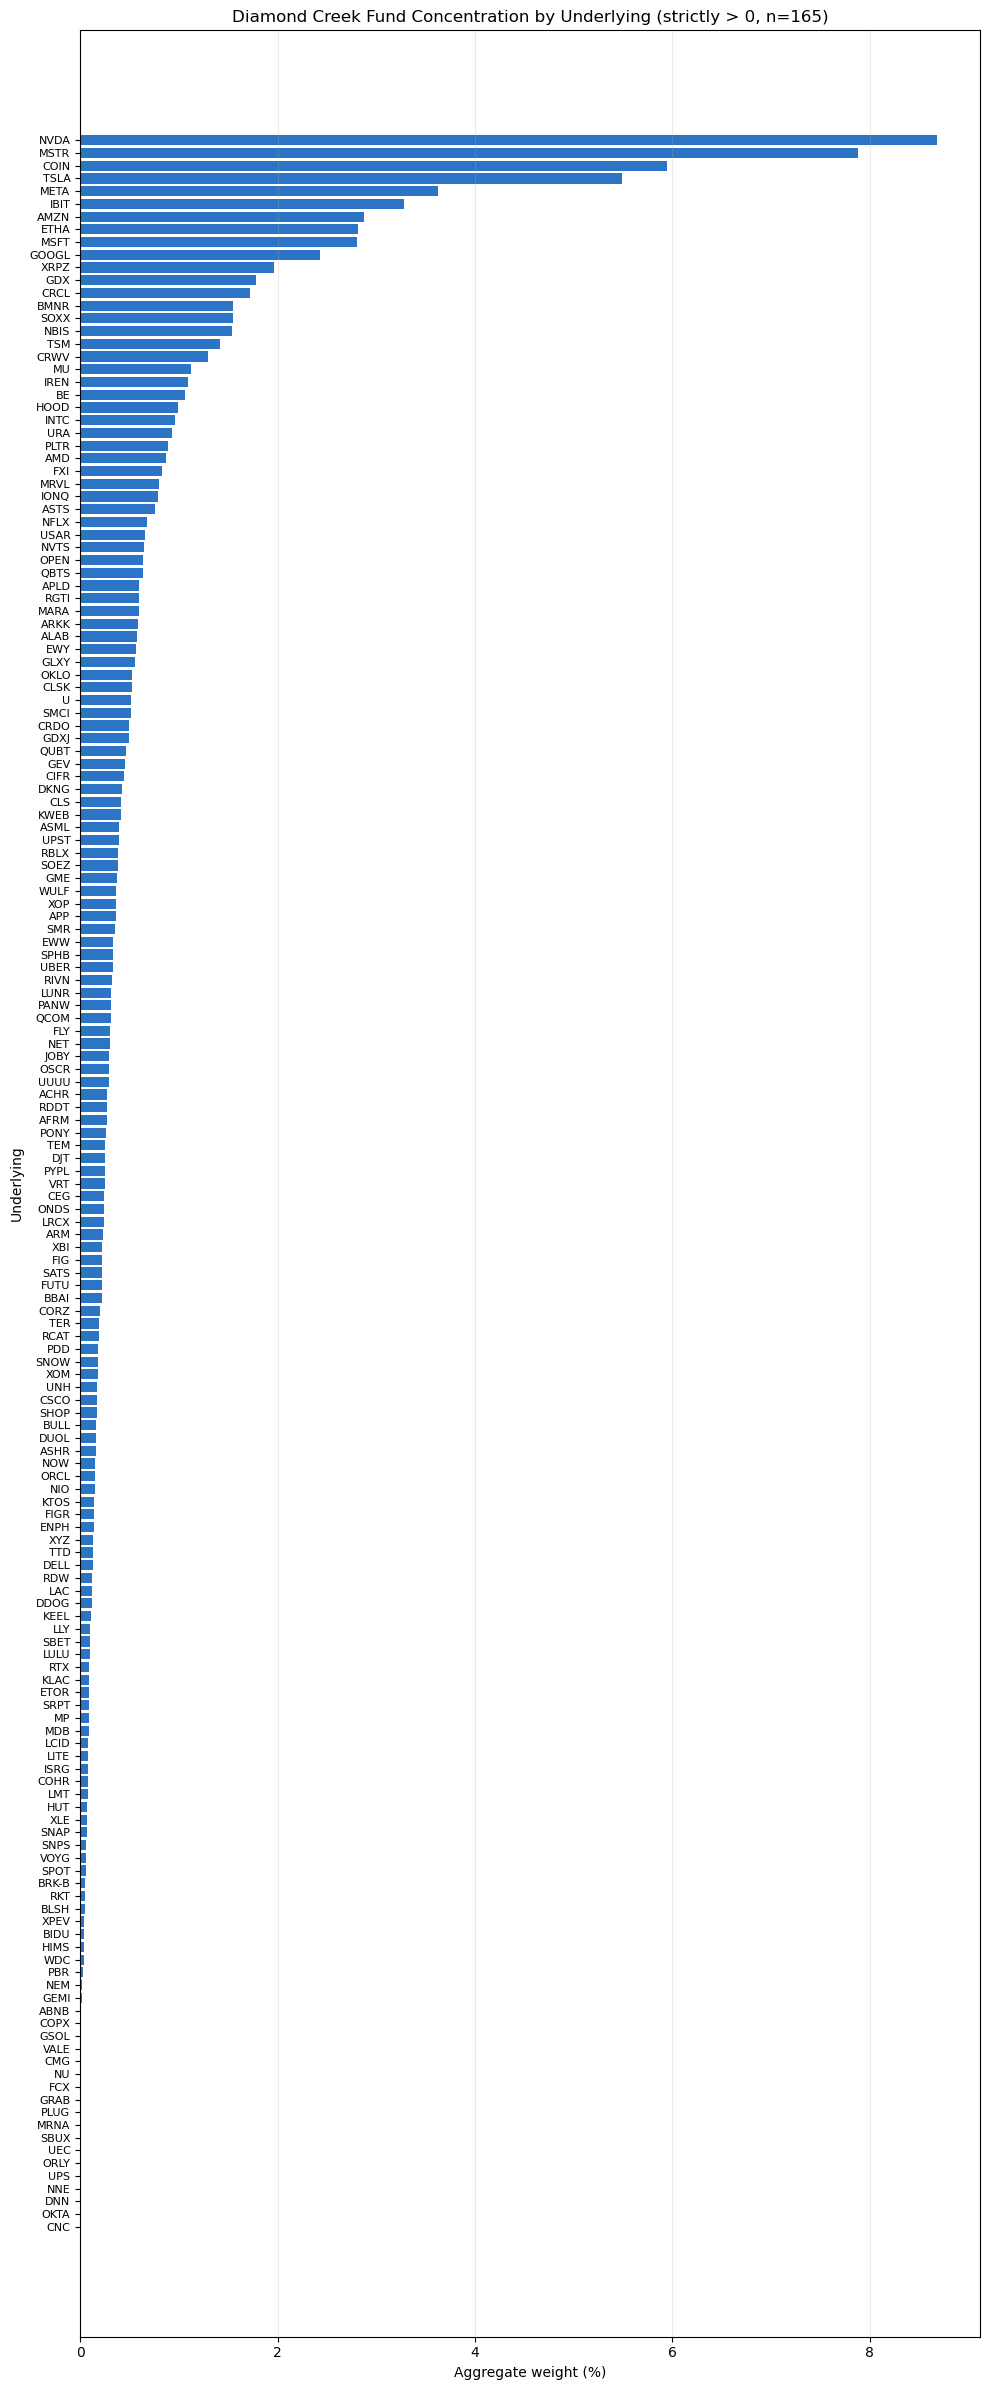

In [16]:

import matplotlib.pyplot as plt

if "w_df" not in globals() or w_df.empty:
    raise RuntimeError("Run the Diamond Creek weighting cell first (w_df not found).")

und_w = (
    w_df.loc[w_df["weight"] > 0, ["und", "weight"]]
    .groupby("und", as_index=False)["weight"]
    .sum()
    .sort_values("weight", ascending=True)
)

if und_w.empty:
    raise RuntimeError("No strictly positive weights found for underlying concentration.")

n = len(und_w)
fig_h = min(24, max(6, 0.24 * n))
fig, ax = plt.subplots(figsize=(10, fig_h))

ax.barh(und_w["und"], und_w["weight"] * 100.0, color="#1565C0", alpha=0.9)
ax.set_title(f"Diamond Creek Fund Concentration by Underlying (strictly > 0, n={n})")
ax.set_xlabel("Aggregate weight (%)")
ax.set_ylabel("Underlying")
ax.grid(True, axis="x", alpha=0.25)
ax.tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.show()


## Performance — Diamond Creek Fund weighted


In [17]:
ref = max(LEVERAGE_RUNS)

for lev in LEVERAGE_RUNS:
    bt = ALL_BT[lev]
    nav = bt["nav"]
    p = perf(nav)
    print(f"\n{'='*60}")
    print(f"  v8 Diamond Creek Fund — {lev}x (store key)")
    print(f"{'='*60}")
    for k, v in p.items():
        if "NAV" in k or "P&L" in k:
            print(f"  {k:<20s}: ${v:>14,.0f}")
        elif "%" in k:
            print(f"  {k:<20s}: {v:>14.1%}")
        else:
            print(f"  {k:<20s}: {v:>14.2%}")
    print(f"  {'Txn Costs':<20s}: ${bt['cum_costs'].iloc[-1]:>14,.0f}")
    print(f"  {'Borrow Costs':<20s}: ${bt['cum_borrow'].iloc[-1]:>14,.0f}")
    print(f"  {'Margin Debit':<20s}: ${bt['cum_margin_debit'].iloc[-1]:>14,.0f}")
    print(f"  {'Short Credit':<20s}: ${bt['cum_margin_credit'].iloc[-1]:>14,.0f}")
    print(
        f"  {'Net Financing':<20s}: "
        f"${(bt['cum_margin_debit'].iloc[-1] + bt['cum_borrow'].iloc[-1] - bt['cum_margin_credit'].iloc[-1]):>14,.0f}"
    )
    print(f"  {'Long P&L':<20s}: ${bt['cum_long_pnl'].iloc[-1]:>14,.0f}")
    print(f"  {'Short P&L':<20s}: ${bt['cum_short_pnl'].iloc[-1]:>14,.0f}")



  v8 Diamond Creek Fund — 4.75x (store key)
  CAGR                :         38.65%
  Vol                 :         13.74%
  Sharpe              :        281.27%
  Sortino             :        482.57%
  Max DD              :         -6.87%
  Calmar              :        562.88%
  Monthly Win%        :          74.4%
  Final NAV           : $    29,028,776
  P&L                 : $    19,081,705
  Txn Costs           : $     1,173,266
  Borrow Costs        : $     2,772,654
  Margin Debit        : $     4,372,236
  Short Credit        : $             0
  Net Financing       : $     7,144,890
  Long P&L            : $    89,767,685
  Short P&L           : $   -62,727,671


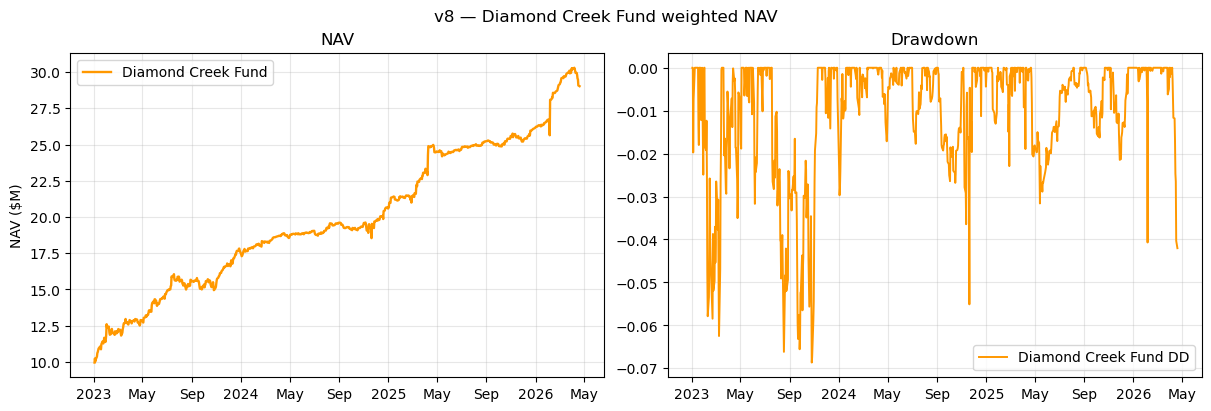

In [18]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

ref = max(LEVERAGE_RUNS)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
fig.suptitle("v8 — Diamond Creek Fund weighted NAV")

dc_nav = ALL_BT[ref]["nav"]
ax = axes[0]
ax.plot(dc_nav.index, dc_nav / 1e6, label="Diamond Creek Fund", color="#FF9800", lw=1.7)
ax.set_ylabel("NAV ($M)")
ax.set_title("NAV")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
dd_dc = (dc_nav - dc_nav.cummax()) / dc_nav.cummax()
ax.plot(dd_dc.index, dd_dc, label="Diamond Creek Fund DD", color="#FF9800", lw=1.4)
ax.set_title("Drawdown")
ax.legend()
ax.grid(True, alpha=0.3)

for ax in axes.flat:
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
plt.show()


## NAV Jump Attribution (Diamond Creek Fund)

Ranks the largest absolute daily NAV moves and estimates top pair-level contributors on those days using lagged pair gross and pair spread returns.


In [19]:
ref = max(LEVERAGE_RUNS)

if "UNIVERSE" not in globals() or len(UNIVERSE) == 0:
    if "CANDIDATES" in globals() and "INCEPTION" in globals():
        UNIVERSE = [(e, u, b) for e, u, b in CANDIDATES if (e, u) in INCEPTION]
        UNIVERSE.sort(key=lambda x: INCEPTION[(x[0], x[1])])
        print(f"[UNIVERSE] Rebuilt from CANDIDATES+INCEPTION: {len(UNIVERSE)} pairs")
    else:
        raise RuntimeError("Run universe setup cells first: CANDIDATES + INCEPTION/UNIVERSE are missing.")

beta_map = {e: abs(float(b)) for e, u, b in UNIVERSE}

def _build_pair_contrib_usd(pair_gross_df: pd.DataFrame) -> pd.DataFrame:
    if pair_gross_df is None or pair_gross_df.empty:
        return pd.DataFrame()

    idx = pair_gross_df.index
    contrib = pd.DataFrame(index=idx)

    for col in pair_gross_df.columns:
        if "/" not in col:
            continue
        und, etf = col.split("/", 1)
        if und not in PRICES or etf not in PRICES:
            continue

        pu = PRICES[und].reindex(idx).ffill()
        pe = PRICES[etf].reindex(idx).ffill()
        if pu.isna().all() or pe.isna().all():
            continue

        ru = pu.pct_change().fillna(0.0)
        re = pe.pct_change().fillna(0.0)

        babs = max(1e-9, beta_map.get(etf, 2.0))
        hr = 1.0 / babs
        long_frac = 1.0 / (1.0 + hr)
        short_frac = hr / (1.0 + hr)

        pair_ret = long_frac * ru - short_frac * re
        lag_gross = pair_gross_df[col].shift(1).fillna(0.0)
        contrib[col] = lag_gross * pair_ret

    return contrib


def _print_jump_attribution(label: str, bt: pd.DataFrame, pair_contrib: pd.DataFrame, top_n_days: int = 8, top_n_pairs: int = 5):
    nav = bt["nav"].astype(float)
    nav_ret = nav.pct_change().dropna()
    nav_pnl = nav.diff().fillna(0.0)

    top_days = nav_ret.abs().sort_values(ascending=False).head(top_n_days)

    print(f"\n{'='*78}")
    print(f"{label} — Top {top_n_days} absolute daily NAV moves")
    print(f"{'='*78}")
    for d in top_days.index:
        print(f"{d.date()}  NAV ret={nav_ret.loc[d]:+6.2%}  NAV pnl=${nav_pnl.loc[d]:+,.0f}")

    print(f"\n{label} — Pair attribution on jump days (approx, lag gross × spread return)")
    print(f"{'-'*78}")
    for d in top_days.index:
        if d not in pair_contrib.index:
            continue
        c = pair_contrib.loc[d].dropna()
        if c.empty:
            continue
        top_pairs = c.reindex(c.abs().sort_values(ascending=False).head(top_n_pairs).index)

        print(f"\n{d.date()}  NAV ret={nav_ret.loc[d]:+6.2%}  NAV pnl=${nav_pnl.loc[d]:+,.0f}")
        for pair, v in top_pairs.items():
            print(f"  {pair:>16s}  contrib=${v:+,.0f}")


dc_bt = ALL_BT[ref]
dc_contrib = _build_pair_contrib_usd(ALL_PAIR_GROSS[ref])

_print_jump_attribution("Diamond Creek Fund", dc_bt, dc_contrib)



Diamond Creek Fund — Top 8 absolute daily NAV moves
2026-02-06  NAV ret=+9.56%  NAV pnl=$+2,450,063
2025-04-09  NAV ret=+6.07%  NAV pnl=$+1,389,236
2023-02-02  NAV ret=+6.01%  NAV pnl=$+713,827
2024-11-21  NAV ret=+5.34%  NAV pnl=$+989,396
2023-07-13  NAV ret=+4.12%  NAV pnl=$+629,042
2023-05-25  NAV ret=+3.35%  NAV pnl=$+450,898
2026-02-05  NAV ret=-3.30%  NAV pnl=$-875,514
2023-01-20  NAV ret=+3.22%  NAV pnl=$+350,046

Diamond Creek Fund — Pair attribution on jump days (approx, lag gross × spread return)
------------------------------------------------------------------------------

2026-02-06  NAV ret=+9.56%  NAV pnl=$+2,450,063
         MSTR/MSTZ  contrib=$+2,479,316
         NVDA/NVDQ  contrib=$+87,845
         SOXX/SOXS  contrib=$+73,327
         NBIS/NBIZ  contrib=$+58,956
         TSLA/TSLQ  contrib=$+42,306

2025-04-09  NAV ret=+6.07%  NAV pnl=$+1,389,236
         MSTR/MSTZ  contrib=$+2,899,844
         TSLA/TSLQ  contrib=$+358,942
         SOXX/SOXS  contrib=$+327,915
      

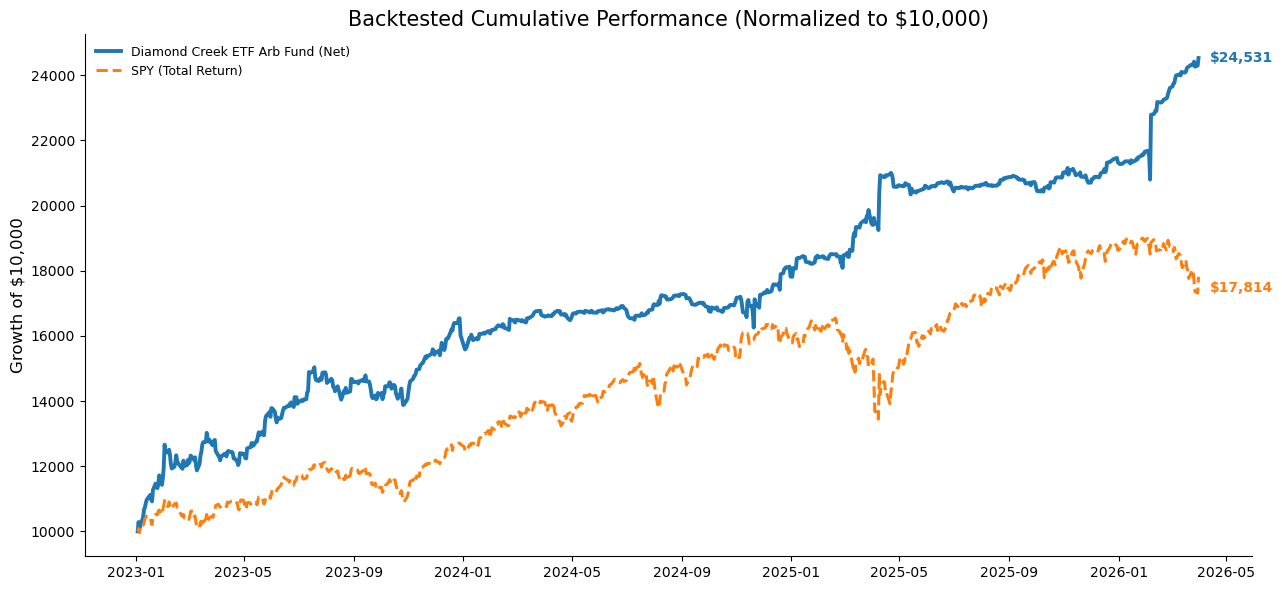

Diamond Creek ending value (net fees): $24,530.81
SPY ending value: $17,814.02


In [20]:
# ---- Diamond Creek net-of-fees vs SPY (2/20, quarterly HWM, no hurdle) ----

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MGMT_FEE_ANNUAL = 0.02
INCENTIVE_FEE = 0.20
HURDLE_ANNUAL = 0.00  # disabled: fee calc uses no hurdle
CRYSTALLIZE_FREQ = "Q"
END_DATE = pd.Timestamp("2026-03-31")

# Convert annual policy terms to quarterly terms (simple convention).
MGMT_FEE_Q = MGMT_FEE_ANNUAL / 4.0
HURDLE_Q = HURDLE_ANNUAL / 4.0


def _to_naive_utc_index_any(idx: pd.DatetimeIndex) -> pd.DatetimeIndex:
    idx = pd.to_datetime(idx)
    if getattr(idx, "tz", None) is not None:
        idx = idx.tz_convert("UTC").tz_localize(None)
    return idx


def _normalize_index_to_date(s: pd.Series) -> pd.Series:
    s = s.copy()
    s.index = _to_naive_utc_index_any(pd.DatetimeIndex(s.index)).normalize()
    return s.sort_index()


# ============================================================
# LP fee wrapper (quarterly mgmt, annual promote, quarterly allocation)
# ============================================================
def apply_lp_fees_quarterly(
    gross_daily_ret: pd.Series,
    mgmt_fee_q: float = MGMT_FEE_Q,
    incentive_fee: float = INCENTIVE_FEE,
    crystallize_freq: str = "Q",
) -> tuple[pd.Series, pd.DataFrame]:
    r = gross_daily_ret.replace([np.inf, -np.inf], np.nan).dropna().copy()
    if r.empty:
        return r, pd.DataFrame()

    r = _normalize_index_to_date(r)
    idx = pd.DatetimeIndex(r.index)

    nav = 1.0
    nav_series = pd.Series(index=idx, dtype=float)

    periods = idx.to_period(crystallize_freq)
    q_starts = (
        pd.Series(idx, index=idx)
        .groupby(periods)
        .min()
        .sort_values()
        .to_list()
    )
    q_starts = [pd.Timestamp(x) for x in q_starts]
    q_start_set = set(q_starts)

    q_ends = (
        pd.Series(idx, index=idx)
        .groupby(periods)
        .max()
        .sort_values()
        .to_list()
    )
    q_ends = [pd.Timestamp(x) for x in q_ends]
    q_end_set = set(q_ends)

    fee_rows = []
    q_start_nav = nav
    q_mgmt_fee_amt = 0.0

    # Pass 1: apply quarterly management fee at BEGINNING of each quarter,
    # then apply daily gross returns.
    for t in idx:
        if t in q_start_set:
            q_start_nav = nav
            q_mgmt_fee_amt = mgmt_fee_q * q_start_nav
            nav = q_start_nav - q_mgmt_fee_amt
        nav *= (1.0 + float(r.loc[t]))
        nav_series.loc[t] = nav

        if t in q_end_set:
            nav_pre_fees = nav
            mgmt_fee_amt = q_mgmt_fee_amt
            nav_after_mgmt = nav_pre_fees

            fee_rows.append(
                {
                    "QuarterEnd": t,
                    "StartNAV": q_start_nav,
                    "EndNAV_preFees": nav_pre_fees,
                    "MgmtFee_amt": mgmt_fee_amt,
                    "EndNAV_postMgmt": nav_after_mgmt,
                    "HurdleNAV": np.nan,
                    "PerfFee_amt": 0.0,
                    "EndNAV_postFees": nav_after_mgmt,
                    "HWM_postFees": np.nan,
                    "QuarterGrossRet": (nav_pre_fees / q_start_nav) - 1.0,
                    "QuarterNetRet": (nav_after_mgmt / q_start_nav) - 1.0,
                }
            )
            q_start_nav = nav_after_mgmt

    # Pass 2: annual incentive fee test (NO hurdle):
    # compute promote after full-year management fees, then allocate back to quarter-ends
    # using each quarter's net-of-mgmt contribution.
    perf_fee_by_q = {q: 0.0 for q in q_ends}
    hwm = 1.0
    years = sorted(idx.year.unique())

    for y in years:
        y_mask = idx.year == y
        y_idx = idx[y_mask]
        if len(y_idx) < 2:
            continue

        y_start = y_idx[0]
        y_end = y_idx[-1]
        y_start_nav = float(nav_series.loc[y_start])
        y_end_nav_pre_perf = float(nav_series.loc[y_end])
        is_full_year = (pd.Timestamp(y_end).month == 12)
        # Do not crystallize annual promote for an incomplete trailing year (e.g., only Q1 YTD).
        if (y == years[-1]) and (not is_full_year):
            continue

        gate = hwm
        incentive_base = max(y_end_nav_pre_perf - gate, 0.0)
        total_perf_fee = float(incentive_fee) * incentive_base

        y_q_ends = [q for q in q_ends if (q.year == y and q in nav_series.index)]
        if total_perf_fee > 0 and y_q_ends:
            # Allocate by quarter contribution after management fee:
            # (EndNAV_postMgmt - StartNAV), clipped at 0 to avoid negative weights.
            y_fee_rows = [r for r in fee_rows if pd.Timestamp(r.get("QuarterEnd")).year == y]
            pnl_map = {}
            for r in y_fee_rows:
                q = pd.Timestamp(r.get("QuarterEnd"))
                q_pnl_after_mgmt = float(r.get("EndNAV_postMgmt", np.nan)) - float(r.get("StartNAV", np.nan))
                pnl_map[q] = max(0.0, q_pnl_after_mgmt) if np.isfinite(q_pnl_after_mgmt) else 0.0
            w = pd.Series({q: pnl_map.get(q, 0.0) for q in y_q_ends}, dtype=float)
            if float(w.sum()) <= 0:
                w = nav_series.loc[y_q_ends].astype(float).clip(lower=1e-12)
            w = w / w.sum()

            # Base quarterly fee allocation (before calibration).
            base_alloc = {q: float(total_perf_fee * w.loc[q]) for q in y_q_ends}
            target_end_nav = float(y_end_nav_pre_perf - total_perf_fee)

            def _apply_alloc(alpha: float):
                nav_tmp = nav_series.copy()
                applied = {q: 0.0 for q in y_q_ends}
                for q in y_q_ends:
                    q_nav = float(nav_tmp.loc[q])
                    fee_amt = max(0.0, float(alpha * base_alloc[q]))
                    fee_amt = min(fee_amt, max(0.0, q_nav - 1e-12))
                    applied[q] = fee_amt
                    scale = max(0.0, 1.0 - fee_amt / max(q_nav, 1e-12))
                    nav_tmp.loc[q:] = nav_tmp.loc[q:] * scale
                return float(nav_tmp.loc[y_end]), applied, nav_tmp

            # Calibrate alpha so quarterly deductions are equivalent to year-end 20% take.
            lo, hi = 0.0, 1.0
            end_hi, _, _ = _apply_alloc(hi)
            while end_hi > target_end_nav and hi < 10.0:
                hi *= 1.5
                end_hi, _, _ = _apply_alloc(hi)

            for _ in range(50):
                mid = 0.5 * (lo + hi)
                end_mid, _, _ = _apply_alloc(mid)
                if end_mid > target_end_nav:
                    lo = mid
                else:
                    hi = mid

            _, applied_map, nav_cal = _apply_alloc(hi)
            nav_series = nav_cal
            for q, fee_amt in applied_map.items():
                perf_fee_by_q[q] += float(fee_amt)

        hwm = max(hwm, float(nav_series.loc[y_end]))

    # Build fee diagnostics with annual HWM-only gate + allocated perf fees.
    fee_diag = pd.DataFrame(fee_rows)
    if not fee_diag.empty:
        fee_diag["QuarterEnd"] = pd.to_datetime(fee_diag["QuarterEnd"])
        fee_diag["PerfFee_amt"] = fee_diag["QuarterEnd"].map(perf_fee_by_q).fillna(0.0)
        fee_diag["EndNAV_postFees"] = fee_diag["QuarterEnd"].map(nav_series).astype(float)

        # Hurdle disabled in this simplified fee model.
        y_start_nav_map = {}
        for y in years:
            y_idx = idx[idx.year == y]
            if len(y_idx) > 0:
                y_start_nav_map[y] = float(nav_series.loc[y_idx[0]])
        fee_diag["HurdleNAV"] = fee_diag["QuarterEnd"].dt.year.map(
            lambda y: np.nan
        )

        fee_diag = fee_diag.sort_values("QuarterEnd").reset_index(drop=True)
        fee_diag["HWM_postFees"] = fee_diag["EndNAV_postFees"].cummax()
        fee_diag["QuarterNetRet"] = (fee_diag["EndNAV_postFees"] / fee_diag["StartNAV"]) - 1.0

    nav_series = nav_series.dropna()
    # Keep first available trading day with a 0% return so reported start is earliest feasible date.
    net_daily_ret = nav_series.pct_change().fillna(0.0)
    net_daily_ret.name = "LP_NetRet"

    return net_daily_ret, fee_diag


if "ALL_BT" not in globals() or not ALL_BT:
    raise RuntimeError("Run the backtest engine first so ALL_BT is populated.")

ref = max(ALL_BT)
dc_nav = ALL_BT[ref]["nav"].astype(float).copy()
dc_nav.index = pd.to_datetime(dc_nav.index)
dc_nav = dc_nav.loc[dc_nav.index <= END_DATE].copy()
# Keep first available trading day with a 0% return so summary starts as close to configured start_date as possible.
dc_gross_ret = dc_nav.pct_change().fillna(0.0)
dc_gross_ret = _normalize_index_to_date(dc_gross_ret)

dc_net_ret, dc_fee_diag = apply_lp_fees_quarterly(
    dc_gross_ret,
    mgmt_fee_q=MGMT_FEE_Q,
    incentive_fee=INCENTIVE_FEE,
    crystallize_freq=CRYSTALLIZE_FREQ,
)
dc_net_ret = _normalize_index_to_date(dc_net_ret)
if isinstance(dc_fee_diag, pd.DataFrame) and (not dc_fee_diag.empty):
    dc_fee_diag = dc_fee_diag.loc[pd.to_datetime(dc_fee_diag["QuarterEnd"]) <= END_DATE].copy()

# SPY total return series
if "get_total_return_series" in globals():
    spy_px = get_total_return_series("SPY").copy()
else:
    if "PRICES" not in globals() or "SPY" not in PRICES:
        raise RuntimeError("Need get_total_return_series('SPY') or PRICES['SPY'] available.")
    spy_px = PRICES["SPY"].copy()

spy_px = _normalize_index_to_date(spy_px)
spy_px = spy_px.loc[spy_px.index <= END_DATE].copy()
spy_ret = spy_px.pct_change().fillna(0.0)

common_idx = dc_net_ret.index.intersection(spy_ret.index)
if len(common_idx) == 0:
    raise RuntimeError("No overlapping dates between Diamond Creek net returns and SPY returns.")

dc_net_aligned = dc_net_ret.loc[common_idx]
spy_ret_aligned = spy_ret.loc[common_idx]

dc_curve_10k = 10_000.0 * ((1.0 + dc_net_aligned).cumprod() / (1.0 + dc_net_aligned).cumprod().iloc[0])
spy_curve_10k = 10_000.0 * ((1.0 + spy_ret_aligned).cumprod() / (1.0 + spy_ret_aligned).cumprod().iloc[0])

dc_end = float(dc_curve_10k.iloc[-1])
spy_end = float(spy_curve_10k.iloc[-1])

plt.figure(figsize=(13, 6))
plt.plot(
    dc_curve_10k.index,
    dc_curve_10k.values,
    linewidth=2.8,
    color="#1f77b4",
    label="Diamond Creek ETF Arb Fund (Net)",
)
plt.plot(
    spy_curve_10k.index,
    spy_curve_10k.values,
    linewidth=2.2,
    linestyle="--",
    color="#ff7f0e",
    label="SPY (Total Return)",
)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)

# Show ending values only on the right side of each line.
ax.annotate(
    f"${dc_end:,.0f}",
    xy=(dc_curve_10k.index[-1], dc_curve_10k.iloc[-1]),
    xytext=(8, 0),
    textcoords="offset points",
    color="#1f77b4",
    fontsize=10,
    fontweight="bold",
    va="center",
)
ax.annotate(
    f"${spy_end:,.0f}",
    xy=(spy_curve_10k.index[-1], spy_curve_10k.iloc[-1]),
    xytext=(8, -8),
    textcoords="offset points",
    color="#ff7f0e",
    fontsize=10,
    fontweight="bold",
    va="center",
)

plt.title("Backtested Cumulative Performance (Normalized to $10,000)", fontsize=15)
plt.ylabel("Growth of $10,000", fontsize=12)
plt.legend(frameon=False, fontsize=9, loc="upper left")
plt.tight_layout()
plt.savefig("diamond_creek_vs_spy_v11.svg", format="svg", bbox_inches="tight")
plt.show()

print(f"Diamond Creek ending value (net fees): ${dc_end:,.2f}")
print(f"SPY ending value: ${spy_end:,.2f}")

In [21]:
# ---- Joel White Bay: Monthly P&L attribution (trading vs carry vs borrow + short sale rebate) ----
ref = max(LEVERAGE_RUNS)

if "dc_gross_ret" not in globals() or "dc_net_ret" not in globals():
    raise RuntimeError(
        "Run the net-fee performance cell first so dc_gross_ret/dc_net_ret exist. "
        "Monthly attribution is now chained from the same return series as EndValue10k."
    )


def _build_attribution(bt: pd.DataFrame, label: str, freq: str = "ME") -> pd.DataFrame:
    d = bt.copy().sort_index()
    accounting_end = pd.to_datetime(globals().get("END_DATE", pd.Timestamp("2026-03-31")))
    if "nav" in d.columns:
        d.index = pd.to_datetime(d.index)
        d = d.loc[d.index <= accounting_end].copy()
    if d.empty:
        return pd.DataFrame()

    def _daily_flow_from_cum(col: str) -> pd.Series:
        s = pd.to_numeric(d[col], errors="coerce")
        s = s.ffill().fillna(0.0)
        flow = s.diff().fillna(0.0)
        flow.iloc[0] = float(s.iloc[0])
        return flow

    # Flow components from cumulative series.
    d["long_trading_pnl"] = _daily_flow_from_cum("cum_long_pnl")
    d["short_trading_pnl"] = _daily_flow_from_cum("cum_short_pnl")
    d["net_trading_pnl"] = d["long_trading_pnl"] + d["short_trading_pnl"]

    d["interest_income"] = _daily_flow_from_cum("cum_margin_credit")
    d["margin_interest_paid"] = _daily_flow_from_cum("cum_margin_debit")
    d["net_interest_carry"] = d["interest_income"] - d["margin_interest_paid"]
    d["net_margin_paid_excess_interest"] = d["margin_interest_paid"] - d["interest_income"]

    d["borrow_fees_paid"] = _daily_flow_from_cum("cum_borrow")
    # Label clarity: this is net borrow cost combined with short sale rebate/credit.
    d["borrow_and_short_sale_rebate_net"] = d["borrow_fees_paid"]
    d["txn_costs_paid"] = _daily_flow_from_cum("cum_costs")

    # NAV change is anchored to attribution base capital so cumulative PnL ties ending NAV.
    d["nav"] = pd.to_numeric(d["nav"], errors="coerce")
    _attribution_base_capital = float(globals().get("ATTRIBUTION_BASE_CAPITAL", np.nan))
    _nav_start_base = _attribution_base_capital if np.isfinite(_attribution_base_capital) else float(d["nav"].iloc[0])
    d["nav_change_pnl"] = d["nav"].diff().fillna(0.0)
    if len(d) > 0:
        d.loc[d.index[0], "nav_change_pnl"] = float(d["nav"].iloc[0]) - _nav_start_base

    # Robust gross leverage derivation across engine schema versions.
    if "actual_leverage" in d.columns:
        d["gross_lev"] = pd.to_numeric(d["actual_leverage"], errors="coerce")
    elif "gross_notional" in d.columns:
        d["gross_lev"] = (pd.to_numeric(d["gross_notional"], errors="coerce").abs() / d["nav"].replace(0, np.nan))
    elif {"long_notional", "short_notional"}.issubset(d.columns):
        d["gross_lev"] = (
            (pd.to_numeric(d["long_notional"], errors="coerce").abs() + pd.to_numeric(d["short_notional"], errors="coerce").abs())
            / d["nav"].replace(0, np.nan)
        )
    else:
        d["gross_lev"] = np.nan
    d["gross_lev"] = d["gross_lev"].replace([np.inf, -np.inf], np.nan)

    d["gross_pnl"] = d["net_trading_pnl"]
    d["total_costs"] = (
        d["txn_costs_paid"]
        + d["borrow_and_short_sale_rebate_net"]
        + d["net_margin_paid_excess_interest"]
    )
    d["net_pnl"] = d["gross_pnl"] - d["total_costs"]
    d["explained_net_pnl"] = d["net_pnl"]

    sum_cols = [
        "long_trading_pnl",
        "short_trading_pnl",
        "net_trading_pnl",
        "interest_income",
        "margin_interest_paid",
        "net_interest_carry",
        "net_margin_paid_excess_interest",
        "gross_pnl",
        "borrow_fees_paid",
        "borrow_and_short_sale_rebate_net",
        "txn_costs_paid",
        "total_costs",
        "nav_change_pnl",
        "net_pnl",
        "explained_net_pnl",
    ]
    out = d[sum_cols].resample(freq).sum()
    out["avg_gross_lev"] = d["gross_lev"].resample(freq).mean()

    # Attach 2/20 LP fees (quarter-end crystallization) in USD to monthly rows.
    out["lp_mgmt_fee_2_20"] = 0.0
    out["lp_perf_fee_2_20"] = 0.0
    out["lp_total_fee_2_20"] = 0.0

    if (
        label == "Diamond Creek Fund"
        and "dc_fee_diag" in globals()
        and isinstance(dc_fee_diag, pd.DataFrame)
        and (not dc_fee_diag.empty)
    ):
        fee_df = dc_fee_diag.copy()
        fee_df["QuarterEnd"] = pd.to_datetime(fee_df["QuarterEnd"])
        fee_df = fee_df.dropna(subset=["QuarterEnd"])
        fee_df = fee_df.loc[fee_df["QuarterEnd"] <= accounting_end].copy()

        # Use the same base capital as EndValue10k reporting for fee USD translation.
        attribution_base_capital = float(globals().get("ATTRIBUTION_BASE_CAPITAL", 10_000_000.0))
        if attribution_base_capital > 0 and not fee_df.empty:
            fee_df["_m"] = fee_df["QuarterEnd"].dt.to_period("M")
            mgmt_map = (fee_df.groupby("_m")["MgmtFee_amt"].sum() * attribution_base_capital).to_dict()
            perf_map = (fee_df.groupby("_m")["PerfFee_amt"].sum() * attribution_base_capital).to_dict()

            m_idx = out.index.to_period("M")
            out["lp_mgmt_fee_2_20"] = pd.Series(m_idx, index=out.index).map(mgmt_map).fillna(0.0).values
            out["lp_perf_fee_2_20"] = pd.Series(m_idx, index=out.index).map(perf_map).fillna(0.0).values
            out["lp_total_fee_2_20"] = out["lp_mgmt_fee_2_20"] + out["lp_perf_fee_2_20"]

    # Keep bridge identity exact in exported attribution:
    # net_pnl = gross_pnl - total_costs, and net_pnl_after_2_20 = net_pnl - lp_total_fee_2_20.
    out["explained_net_pnl"] = out["net_pnl"]

    # Return-chain references aligned to the SAME overlap basis used in Diamond Creek vs SPY end value.
    out["net_pnl_pre_fees_return_chain_ref"] = np.nan
    out["net_pnl_after_2_20_return_chain_ref"] = np.nan
    if (
        label == "Diamond Creek Fund"
        and "dc_gross_ret" in globals()
        and "dc_net_ret" in globals()
        and "spy_ret" in globals()
    ):
        attribution_base_capital = float(globals().get("ATTRIBUTION_BASE_CAPITAL", 10_000_000.0))
        gross_ret_ref = _normalize_index_to_date(pd.to_numeric(globals()["dc_gross_ret"], errors="coerce").fillna(0.0))
        net_ret_ref = _normalize_index_to_date(pd.to_numeric(globals()["dc_net_ret"], errors="coerce").fillna(0.0))
        spy_ret_ref = _normalize_index_to_date(pd.to_numeric(globals()["spy_ret"], errors="coerce").fillna(0.0))

        ref_idx = gross_ret_ref.index.intersection(net_ret_ref.index).intersection(spy_ret_ref.index)
        ref_idx = ref_idx[ref_idx <= accounting_end]

        if len(ref_idx) > 0 and attribution_base_capital > 0:
            gross_curve = (1.0 + gross_ret_ref.loc[ref_idx]).cumprod()
            net_curve = (1.0 + net_ret_ref.loc[ref_idx]).cumprod()
            gross_curve = gross_curve / float(gross_curve.iloc[0])
            net_curve = net_curve / float(net_curve.iloc[0])

            gross_nav_usd = attribution_base_capital * gross_curve
            net_nav_usd = attribution_base_capital * net_curve

            gross_eom = gross_nav_usd.resample(freq).last()
            net_eom = net_nav_usd.resample(freq).last()
            gross_m = gross_eom.diff()
            net_m = net_eom.diff()
            if len(gross_m) > 0:
                gross_m.iloc[0] = gross_eom.iloc[0] - attribution_base_capital
                net_m.iloc[0] = net_eom.iloc[0] - attribution_base_capital

            p_idx = out.index.to_period("M")
            gross_map = pd.Series(gross_m.values, index=gross_m.index.to_period("M"))
            net_map = pd.Series(net_m.values, index=net_m.index.to_period("M"))

            out["net_pnl_pre_fees_return_chain_ref"] = pd.Series(p_idx, index=out.index).map(gross_map).values
            out["net_pnl_after_2_20_return_chain_ref"] = pd.Series(p_idx, index=out.index).map(net_map).values

    # Keep LP fees as explicit quarter crystallization flows from fee diagnostics.
    out["lp_total_fee_2_20"] = out["lp_mgmt_fee_2_20"] + out["lp_perf_fee_2_20"]
    out["net_pnl_after_2_20"] = out["net_pnl"] - out["lp_total_fee_2_20"]
    out["explained_net_pnl_after_2_20"] = out["net_pnl_after_2_20"]

    if "fed_funds_rate" in d.columns:
        rate = pd.to_numeric(d["fed_funds_rate"], errors="coerce")
        out["benchmark_rate_avg"] = rate.resample(freq).mean()
        out["benchmark_rate_eom"] = rate.resample(freq).last()
    else:
        out["benchmark_rate_avg"] = np.nan
        out["benchmark_rate_eom"] = np.nan

    # Contribution views.
    out["trading_pct_of_net"] = np.where(out["net_pnl"] != 0, out["net_trading_pnl"] / out["net_pnl"], np.nan)
    out["carry_pct_of_net"] = np.where(out["net_pnl"] != 0, out["net_interest_carry"] / out["net_pnl"], np.nan)
    out["borrow_pct_of_net"] = np.where(out["net_pnl"] != 0, -out["borrow_and_short_sale_rebate_net"] / out["net_pnl"], np.nan)

    abs_driver = out["net_trading_pnl"].abs() + out["net_interest_carry"].abs() + out["borrow_and_short_sale_rebate_net"].abs() + out["txn_costs_paid"].abs()
    out["trading_abs_share"] = np.where(abs_driver > 0, out["net_trading_pnl"].abs() / abs_driver, np.nan)
    out["carry_abs_share"] = np.where(abs_driver > 0, out["net_interest_carry"].abs() / abs_driver, np.nan)
    out["borrow_abs_share"] = np.where(abs_driver > 0, out["borrow_and_short_sale_rebate_net"].abs() / abs_driver, np.nan)
    out["txn_abs_share"] = np.where(abs_driver > 0, out["txn_costs_paid"].abs() / abs_driver, np.nan)

    out.insert(0, "portfolio", label)
    out.insert(1, "month", out.index.strftime("%Y-%m"))
    out = out.loc[out["month"].notna() & (out["month"] != "NaT")].copy()
    return out.reset_index(drop=True)


monthly_dc = _build_attribution(ALL_BT[ref], "Diamond Creek Fund")
monthly_attr = pd.concat([monthly_dc], ignore_index=True)

print("=" * 108)
print("Monthly P&L Attribution — Trading vs Interest Carry vs Borrow + Short Sale Rebate (Net)")
print("=" * 108)
print(
    "Columns bridge: gross_pnl (= long+short trading), minus txn_costs_paid, borrow_and_short_sale_rebate_net, "
    "net_margin_paid_excess_interest, and LP 2/20 fees => net_pnl_after_2_20"
)

for name in ["Diamond Creek Fund"]:
    x = monthly_attr[monthly_attr["portfolio"] == name].copy()
    print(f"\n{name} — monthly attribution")

    show_cols = [
        "month",
        "benchmark_rate_avg",
        "long_trading_pnl",
        "short_trading_pnl",
        "gross_pnl",
        "txn_costs_paid",
        "borrow_and_short_sale_rebate_net",
        "interest_income",
        "margin_interest_paid",
        "net_margin_paid_excess_interest",
        "total_costs",
        "nav_change_pnl",
        "net_pnl",
        "lp_mgmt_fee_2_20",
        "lp_perf_fee_2_20",
        "lp_total_fee_2_20",
        "net_pnl_after_2_20",
    ]
    money_cols = [
        "long_trading_pnl",
        "short_trading_pnl",
        "gross_pnl",
        "txn_costs_paid",
        "borrow_and_short_sale_rebate_net",
        "interest_income",
        "margin_interest_paid",
        "net_margin_paid_excess_interest",
        "total_costs",
        "nav_change_pnl",
        "net_pnl",
        "lp_mgmt_fee_2_20",
        "lp_perf_fee_2_20",
        "lp_total_fee_2_20",
        "net_pnl_after_2_20",
    ]

show_cols_present = [c for c in show_cols if c in x.columns]
money_cols_present = [c for c in money_cols if c in x.columns]
x_show = x[show_cols_present].copy()
if money_cols_present:
    x_show[money_cols_present] = x_show[money_cols_present].round(2)
display(x_show)

# Compact cumulative summary for fast readout.
summary = (
    monthly_attr.groupby("portfolio", dropna=False)[[
        "gross_pnl",
        "txn_costs_paid",
        "borrow_and_short_sale_rebate_net",
        "net_margin_paid_excess_interest",
        "total_costs",
        "nav_change_pnl",
        "net_pnl",
        "lp_mgmt_fee_2_20",
        "lp_perf_fee_2_20",
        "lp_total_fee_2_20",
        "net_pnl_after_2_20",
    ]]
    .sum()
    .reset_index()
)

summary_money_cols = [
    "gross_pnl",
    "txn_costs_paid",
    "borrow_and_short_sale_rebate_net",
    "net_margin_paid_excess_interest",
    "total_costs",
    "nav_change_pnl",
    "net_pnl",
    "lp_mgmt_fee_2_20",
    "lp_perf_fee_2_20",
    "lp_total_fee_2_20",
    "net_pnl_after_2_20",
]
summary_show = summary.copy()
summary_show[summary_money_cols] = summary_show[summary_money_cols].round(2)

print("\nCumulative attribution summary")
display(summary_show)

# Export monthly attribution and summary to Excel.
from pathlib import Path

# Keep this separate from the legacy monthly_attribution_v15 workbook.
export_path = Path("data/backtest/Diamond_Creek_PnL_Attribution.xlsx")
export_path.parent.mkdir(parents=True, exist_ok=True)

monthly_export = monthly_attr.copy()
monthly_money_cols = [
    "long_trading_pnl",
    "short_trading_pnl",
    "net_trading_pnl",
    "gross_pnl",
    "txn_costs_paid",
    "borrow_and_short_sale_rebate_net",
    "interest_income",
    "margin_interest_paid",
    "net_margin_paid_excess_interest",
    "total_costs",
    "nav_change_pnl",
    "net_pnl",
    "lp_mgmt_fee_2_20",
    "lp_perf_fee_2_20",
    "lp_total_fee_2_20",
    "net_pnl_after_2_20",
    "explained_net_pnl",
    "explained_net_pnl_after_2_20",
]
for c in monthly_money_cols:
    if c in monthly_export.columns:
        monthly_export[c] = pd.to_numeric(monthly_export[c], errors="coerce").round(2)

# Keep a clean column order for the investor bridge.
bridge_export_cols = [
    "portfolio",
    "month",
    "benchmark_rate_avg",
    "benchmark_rate_eom",
    "avg_gross_lev",
    "long_trading_pnl",
    "short_trading_pnl",
    "gross_pnl",
    "txn_costs_paid",
    "borrow_fees_paid",
    "borrow_and_short_sale_rebate_net",
    "interest_income",
    "margin_interest_paid",
    "net_margin_paid_excess_interest",
    "total_costs",
    "nav_change_pnl",
    "net_pnl",
    "lp_mgmt_fee_2_20",
    "lp_perf_fee_2_20",
    "lp_total_fee_2_20",
    "net_pnl_after_2_20",
    "explained_net_pnl",
    "explained_net_pnl_after_2_20",
]
monthly_export = monthly_export[[c for c in bridge_export_cols if c in monthly_export.columns]].copy()

# Keep only real month rows and clamp to export horizon for consistency.
export_end_date = pd.Timestamp("2026-03-31")
if "month" in monthly_export.columns:
    _month_dt = pd.to_datetime(monthly_export["month"], format="%Y-%m", errors="coerce")
    month_cap = export_end_date.to_period("M").to_timestamp()
    monthly_export = monthly_export.loc[_month_dt.notna() & (_month_dt <= month_cap)].copy()
    monthly_export["month"] = _month_dt.loc[monthly_export.index].dt.strftime("%Y-%m")

# Defensive fill for schema variants before identity checks.
if "borrow_and_short_sale_rebate_net" not in monthly_export.columns:
    if "borrow_fees_paid" in monthly_export.columns:
        monthly_export["borrow_and_short_sale_rebate_net"] = pd.to_numeric(monthly_export["borrow_fees_paid"], errors="coerce").fillna(0.0)
    else:
        monthly_export["borrow_and_short_sale_rebate_net"] = 0.0

# Build daily PnL + active pair count sheet.
daily_attr_dc = ALL_BT[ref].copy().sort_index()
daily_attr_dc.index = pd.to_datetime(daily_attr_dc.index)
daily_attr_dc = daily_attr_dc.loc[daily_attr_dc.index <= export_end_date].copy()

# Pre-load gross return reference (if present) to anchor a full daily date range.
_gross_ret_ref = pd.Series(dtype=float)
if "dc_gross_ret" in globals():
    _gross_ret_ref = _normalize_index_to_date(pd.to_numeric(globals()["dc_gross_ret"], errors="coerce").fillna(0.0))
    _gross_ret_ref = _gross_ret_ref.loc[_gross_ret_ref.index <= export_end_date]

_start_candidates = []
if not daily_attr_dc.empty:
    _start_candidates.append(pd.to_datetime(daily_attr_dc.index.min()))
if len(_gross_ret_ref) > 0:
    _start_candidates.append(pd.to_datetime(_gross_ret_ref.index.min()))
_daily_start = min(_start_candidates) if _start_candidates else export_end_date
daily_index = pd.date_range(start=_daily_start, end=export_end_date, freq="D")

def _daily_flow_from_cum_series(s: pd.Series) -> pd.Series:
    x = pd.to_numeric(s, errors="coerce").ffill().fillna(0.0)
    flow = x.diff().fillna(0.0)
    flow.iloc[0] = float(x.iloc[0])
    return flow

daily_export = pd.DataFrame(index=daily_index)
daily_export["nav"] = pd.to_numeric(daily_attr_dc.get("nav"), errors="coerce").reindex(daily_index)
daily_export["daily_pnl_usd"] = 0.0
if len(daily_export) > 0:
    _base_capital_daily = float(globals().get("ATTRIBUTION_BASE_CAPITAL", np.nan))
    _nav_non_na = daily_export["nav"].dropna()
    if len(_nav_non_na) > 0:
        _nav_start_daily = _base_capital_daily if np.isfinite(_base_capital_daily) else float(_nav_non_na.iloc[0])
        _nav_ffill = daily_export["nav"].ffill()
        _daily_pnl = _nav_ffill.diff().fillna(0.0)
        _first_valid_idx = _nav_non_na.index[0]
        _daily_pnl.loc[_first_valid_idx] = float(_nav_ffill.loc[_first_valid_idx]) - _nav_start_daily
        # Keep leading pre-start dates at zero until first valid NAV appears.
        _daily_pnl.loc[_daily_pnl.index < _first_valid_idx] = 0.0
        daily_export["daily_pnl_usd"] = _daily_pnl

daily_export["long_trading_pnl"] = _daily_flow_from_cum_series(daily_attr_dc.get("cum_long_pnl", pd.Series(0.0, index=daily_attr_dc.index))).reindex(daily_index).fillna(0.0)
daily_export["short_trading_pnl"] = _daily_flow_from_cum_series(daily_attr_dc.get("cum_short_pnl", pd.Series(0.0, index=daily_attr_dc.index))).reindex(daily_index).fillna(0.0)
daily_export["gross_pnl"] = daily_export["long_trading_pnl"] + daily_export["short_trading_pnl"]
daily_export["txn_costs_paid"] = _daily_flow_from_cum_series(daily_attr_dc.get("cum_costs", pd.Series(0.0, index=daily_attr_dc.index))).reindex(daily_index).fillna(0.0)
daily_export["borrow_and_short_sale_rebate_net"] = _daily_flow_from_cum_series(daily_attr_dc.get("cum_borrow", pd.Series(0.0, index=daily_attr_dc.index))).reindex(daily_index).fillna(0.0)
daily_export["net_margin_paid_excess_interest"] = (
    _daily_flow_from_cum_series(daily_attr_dc.get("cum_margin_debit", pd.Series(0.0, index=daily_attr_dc.index))).reindex(daily_index).fillna(0.0)
    - _daily_flow_from_cum_series(daily_attr_dc.get("cum_margin_credit", pd.Series(0.0, index=daily_attr_dc.index))).reindex(daily_index).fillna(0.0)
)
daily_export["total_costs"] = (
    daily_export["txn_costs_paid"]
    + daily_export["borrow_and_short_sale_rebate_net"]
    + daily_export["net_margin_paid_excess_interest"]
)
daily_export["net_pnl_before_lp_fees"] = daily_export["gross_pnl"] - daily_export["total_costs"]

# Optional diagnostic-only daily series from return chaining.
daily_export["net_pnl_before_lp_fees_return_chain_ref"] = np.nan
_base_capital = float(globals().get("ATTRIBUTION_BASE_CAPITAL", 10_000_000.0))
if _base_capital > 0 and len(_gross_ret_ref) > 0:
    _gross_nav_usd = _base_capital * (1.0 + _gross_ret_ref).cumprod()
    _daily_from_chain = _gross_nav_usd.diff().fillna(0.0)
    _daily_from_chain.iloc[0] = _gross_nav_usd.iloc[0] - _base_capital
    daily_export["net_pnl_before_lp_fees_return_chain_ref"] = _daily_from_chain.reindex(daily_index).values

daily_export = daily_export.reset_index().rename(columns={"index": "date"})

active_pairs_daily = pd.DataFrame(columns=["date", "active_pairs"])
if "ALL_PAIR_DAILY" in globals() and isinstance(ALL_PAIR_DAILY, dict) and ref in ALL_PAIR_DAILY:
    _ppd = ALL_PAIR_DAILY.get(ref)
    if isinstance(_ppd, pd.DataFrame) and (not _ppd.empty) and ("date" in _ppd.columns):
        _ppd = _ppd.copy()
        _ppd["date"] = pd.to_datetime(_ppd["date"], errors="coerce")
        _ppd = _ppd.dropna(subset=["date"])
        if "gross_notional_usd" in _ppd.columns:
            _ppd["_is_active"] = pd.to_numeric(_ppd["gross_notional_usd"], errors="coerce").fillna(0.0) > 1.0
            active_pairs_daily = _ppd.groupby("date", as_index=False)["_is_active"].sum().rename(columns={"_is_active": "active_pairs"})
        elif "etf" in _ppd.columns:
            active_pairs_daily = _ppd.groupby("date", as_index=False)["etf"].nunique().rename(columns={"etf": "active_pairs"})

if not active_pairs_daily.empty:
    active_pairs_daily["date"] = pd.to_datetime(active_pairs_daily["date"])
    daily_export = daily_export.merge(active_pairs_daily, on="date", how="left")
else:
    daily_export["active_pairs"] = np.nan

for _c in [
    "nav",
    "daily_pnl_usd",
    "long_trading_pnl",
    "short_trading_pnl",
    "gross_pnl",
    "txn_costs_paid",
    "borrow_and_short_sale_rebate_net",
    "net_margin_paid_excess_interest",
    "total_costs",
    "net_pnl_before_lp_fees",
]:
    if _c in daily_export.columns:
        daily_export[_c] = pd.to_numeric(daily_export[_c], errors="coerce").round(2)
if "active_pairs" in daily_export.columns:
    daily_export["active_pairs"] = pd.to_numeric(daily_export["active_pairs"], errors="coerce")

daily_export["date"] = pd.to_datetime(daily_export["date"], errors="coerce")
daily_export = daily_export.loc[daily_export["date"].notna() & (daily_export["date"] <= export_end_date)].copy()
daily_export = daily_export.sort_values("date").reset_index(drop=True)

# Reconcile daily and monthly pre-fee PnL on the exact same month buckets.
_monthly_for_recon = monthly_export.copy()
_monthly_for_recon["month_dt"] = pd.to_datetime(_monthly_for_recon["month"], format="%Y-%m", errors="coerce")
_monthly_for_recon = _monthly_for_recon.loc[_monthly_for_recon["month_dt"].notna()].copy()
_daily_monthly = (
    daily_export.assign(month_dt=daily_export["date"].dt.to_period("M").dt.to_timestamp())
    .groupby("month_dt", as_index=False)["net_pnl_before_lp_fees"]
    .sum()
)

# Force monthly pre-fee net to equal sum of daily pre-fee net in each month.
_month_to_daily_net = dict(zip(_daily_monthly["month_dt"], _daily_monthly["net_pnl_before_lp_fees"]))
monthly_export["month_dt"] = pd.to_datetime(monthly_export["month"], format="%Y-%m", errors="coerce")
monthly_export["net_pnl"] = monthly_export["month_dt"].map(_month_to_daily_net).fillna(0.0)
monthly_export["explained_net_pnl"] = monthly_export["net_pnl"]

# Rebuild total_costs so gross_pnl - total_costs = net_pnl remains exact.
monthly_export["total_costs"] = monthly_export["gross_pnl"] - monthly_export["net_pnl"]

# Keep LP fees on quarter crystallization months only (from dc_fee_diag), then derive after-fee net.
if "lp_mgmt_fee_2_20" in monthly_export.columns and "lp_perf_fee_2_20" in monthly_export.columns:
    monthly_export["lp_mgmt_fee_2_20"] = 0.0
    monthly_export["lp_perf_fee_2_20"] = 0.0
    if "dc_fee_diag" in globals() and isinstance(dc_fee_diag, pd.DataFrame) and (not dc_fee_diag.empty):
        _fee_df = dc_fee_diag.copy()
        _fee_df["QuarterEnd"] = pd.to_datetime(_fee_df["QuarterEnd"], errors="coerce")
        _fee_df = _fee_df.dropna(subset=["QuarterEnd"])
        _fee_df = _fee_df.loc[_fee_df["QuarterEnd"] <= export_end_date].copy()
        _fee_df["_m"] = _fee_df["QuarterEnd"].dt.to_period("M")
        _base_capital = float(globals().get("ATTRIBUTION_BASE_CAPITAL", 10_000_000.0))
        if _base_capital > 0 and not _fee_df.empty:
            _mgmt_map = (_fee_df.groupby("_m")["MgmtFee_amt"].sum() * _base_capital).to_dict()
            _perf_map = (_fee_df.groupby("_m")["PerfFee_amt"].sum() * _base_capital).to_dict()
            _m_period = pd.to_datetime(monthly_export["month"], format="%Y-%m", errors="coerce").dt.to_period("M")
            monthly_export["lp_mgmt_fee_2_20"] = pd.Series(_m_period, index=monthly_export.index).map(_mgmt_map).fillna(0.0).values
            monthly_export["lp_perf_fee_2_20"] = pd.Series(_m_period, index=monthly_export.index).map(_perf_map).fillna(0.0).values

if "lp_total_fee_2_20" in monthly_export.columns:
    monthly_export["lp_total_fee_2_20"] = monthly_export["lp_mgmt_fee_2_20"] + monthly_export["lp_perf_fee_2_20"]

# Align monthly after-fee PnL to the same net-return chain basis as Diamond Creek ending value print.
if (
    "dc_net_ret" in globals()
    and "spy_ret" in globals()
    and "net_pnl_after_2_20" in monthly_export.columns
):
    _base_capital = float(globals().get("ATTRIBUTION_BASE_CAPITAL", 10_000_000.0))
    _dc_net_ref = _normalize_index_to_date(pd.to_numeric(globals()["dc_net_ret"], errors="coerce").fillna(0.0))
    _spy_ref = _normalize_index_to_date(pd.to_numeric(globals()["spy_ret"], errors="coerce").fillna(0.0))
    _ref_idx = _dc_net_ref.index.intersection(_spy_ref.index)
    _ref_idx = _ref_idx[_ref_idx <= export_end_date]
    if _base_capital > 0 and len(_ref_idx) > 0:
        _net_curve = (1.0 + _dc_net_ref.loc[_ref_idx]).cumprod()
        _net_curve = _net_curve / float(_net_curve.iloc[0])
        _net_nav_usd = _base_capital * _net_curve
        _net_eom = _net_nav_usd.resample("ME").last()
        _net_m = _net_eom.diff()
        if len(_net_m) > 0:
            _net_m.iloc[0] = _net_eom.iloc[0] - _base_capital
        _net_map = pd.Series(_net_m.values, index=_net_m.index.to_period("M"))
        _m_period = pd.to_datetime(monthly_export["month"], format="%Y-%m", errors="coerce").dt.to_period("M")
        monthly_export["net_pnl_after_2_20"] = pd.Series(_m_period, index=monthly_export.index).map(_net_map).fillna(0.0).values

# Fold all timing/compounding effects into total fee so no separate drag column is needed.
monthly_export["lp_total_fee_2_20"] = monthly_export["net_pnl"] - monthly_export["net_pnl_after_2_20"]
monthly_export["lp_perf_fee_2_20"] = monthly_export["lp_total_fee_2_20"] - monthly_export["lp_mgmt_fee_2_20"]
if "explained_net_pnl_after_2_20" in monthly_export.columns:
    monthly_export["explained_net_pnl_after_2_20"] = monthly_export["net_pnl_after_2_20"]

monthly_export = monthly_export.drop(columns=["month_dt"], errors="ignore")

# Final cent-level true-up so monthly and daily pre-fee sums match exactly.
for _c in monthly_money_cols:
    if _c in monthly_export.columns:
        monthly_export[_c] = pd.to_numeric(monthly_export[_c], errors="coerce")

_daily_sum_pre_fee = float(pd.to_numeric(daily_export["net_pnl_before_lp_fees"], errors="coerce").sum())
_monthly_sum_pre_fee = float(pd.to_numeric(monthly_export["net_pnl"], errors="coerce").sum())
_residual_pre_fee = round(_daily_sum_pre_fee - _monthly_sum_pre_fee, 2)
if abs(_residual_pre_fee) > 0 and len(monthly_export) > 0:
    _last_i = monthly_export.index[-1]
    monthly_export.loc[_last_i, "net_pnl"] = float(monthly_export.loc[_last_i, "net_pnl"]) + _residual_pre_fee
    monthly_export.loc[_last_i, "explained_net_pnl"] = monthly_export.loc[_last_i, "net_pnl"]
    monthly_export.loc[_last_i, "total_costs"] = float(monthly_export.loc[_last_i, "gross_pnl"]) - float(monthly_export.loc[_last_i, "net_pnl"])
    if "net_pnl_after_2_20" in monthly_export.columns:
        monthly_export.loc[_last_i, "lp_total_fee_2_20"] = (
            float(monthly_export.loc[_last_i, "net_pnl"]) - float(monthly_export.loc[_last_i, "net_pnl_after_2_20"])
        )
        if "lp_mgmt_fee_2_20" in monthly_export.columns and "lp_perf_fee_2_20" in monthly_export.columns:
            _lp_tot = float(monthly_export.loc[_last_i, "lp_total_fee_2_20"])
            _lp_raw = float(monthly_export.loc[_last_i, "lp_mgmt_fee_2_20"]) + float(monthly_export.loc[_last_i, "lp_perf_fee_2_20"])
            _mgmt_share_last = (float(monthly_export.loc[_last_i, "lp_mgmt_fee_2_20"]) / _lp_raw) if abs(_lp_raw) > 1e-12 else 1.0
            monthly_export.loc[_last_i, "lp_mgmt_fee_2_20"] = _lp_tot * _mgmt_share_last
            monthly_export.loc[_last_i, "lp_perf_fee_2_20"] = _lp_tot - float(monthly_export.loc[_last_i, "lp_mgmt_fee_2_20"])

for _c in monthly_money_cols:
    if _c in monthly_export.columns:
        monthly_export[_c] = pd.to_numeric(monthly_export[_c], errors="coerce").round(2)

_recon_df = _monthly_for_recon[["month_dt"]].merge(
    _daily_monthly,
    on="month_dt",
    how="left",
).merge(
    monthly_export.assign(month_dt=pd.to_datetime(monthly_export["month"], format="%Y-%m", errors="coerce"))[["month_dt", "net_pnl"]],
    on="month_dt",
    how="left",
).fillna({"net_pnl_before_lp_fees": 0.0, "net_pnl": 0.0})
_daily_vs_monthly_net_pre_fee_diff = float(
    _recon_df["net_pnl_before_lp_fees"].sum() - _recon_df["net_pnl"].sum()
)

# Rebuild summary from final exported monthly data (not pre-adjustment monthly_attr).
_summary_cols = [
    "gross_pnl",
    "txn_costs_paid",
    "borrow_and_short_sale_rebate_net",
    "net_margin_paid_excess_interest",
    "total_costs",
    "nav_change_pnl",
    "net_pnl",
    "lp_mgmt_fee_2_20",
    "lp_perf_fee_2_20",
    "lp_total_fee_2_20",
    "net_pnl_after_2_20",
]
summary_show = (
    monthly_export.groupby("portfolio", dropna=False)[[c for c in _summary_cols if c in monthly_export.columns]]
    .sum()
    .reset_index()
)
for _c in _summary_cols:
    if _c in summary_show.columns:
        summary_show[_c] = pd.to_numeric(summary_show[_c], errors="coerce").round(2)

with pd.ExcelWriter(export_path, engine="openpyxl") as writer:
    monthly_export.to_excel(writer, index=False, sheet_name="monthly_attribution")
    summary_show.to_excel(writer, index=False, sheet_name="summary")
    daily_export.to_excel(writer, index=False, sheet_name="daily_pnl_active_pairs")

# Add Excel formulas so the workbook is self-auditable without manual formula entry.
import openpyxl as _xl
_wb = _xl.load_workbook(export_path)
_ws = _wb["monthly_attribution"]
_m_headers = {_ws.cell(1, c).value: c for c in range(1, _ws.max_column + 1)}
_m_last_data_row = _ws.max_row

def _col_letter(col_name):
    return _xl.utils.get_column_letter(_m_headers[col_name])

_D = _col_letter("long_trading_pnl")
_E = _col_letter("short_trading_pnl")
_F = _col_letter("txn_costs_paid")
_G = _col_letter("borrow_and_short_sale_rebate_net") if "borrow_and_short_sale_rebate_net" in _m_headers else _col_letter("borrow_fees_paid")
_H = _col_letter("net_margin_paid_excess_interest")
_K = _col_letter("total_costs")
_L = _col_letter("net_pnl")
_M = _col_letter("lp_mgmt_fee_2_20")
_N = _col_letter("lp_perf_fee_2_20")
_O = _col_letter("lp_total_fee_2_20")
_P = _col_letter("net_pnl_after_2_20")

for _r in range(2, _m_last_data_row + 1):
    _ws[f"{_K}{_r}"] = f"={_F}{_r}+{_G}{_r}+{_H}{_r}"
    _ws[f"{_L}{_r}"] = f"={_D}{_r}+{_E}{_r}-{_K}{_r}"
    _ws[f"{_O}{_r}"] = f"={_M}{_r}+{_N}{_r}"
    _ws[f"{_P}{_r}"] = f"={_L}{_r}-{_O}{_r}"

_sum_row = _m_last_data_row + 1
for _cn in ["long_trading_pnl", "short_trading_pnl", "txn_costs_paid",
            "borrow_and_short_sale_rebate_net" if "borrow_and_short_sale_rebate_net" in _m_headers else "borrow_fees_paid",
            "net_margin_paid_excess_interest", "lp_mgmt_fee_2_20", "lp_perf_fee_2_20",
            "nav_change_pnl"]:
    if _cn in _m_headers:
        _cl = _col_letter(_cn)
        _ws[f"{_cl}{_sum_row}"] = f"=SUM({_cl}2:{_cl}{_m_last_data_row})"
_ws[f"{_K}{_sum_row}"] = f"=SUM({_K}2:{_K}{_m_last_data_row})"
_ws[f"{_L}{_sum_row}"] = f"=SUM({_L}2:{_L}{_m_last_data_row})"
_ws[f"{_O}{_sum_row}"] = f"={_M}{_sum_row}+{_N}{_sum_row}"
_ws[f"{_P}{_sum_row}"] = f"={_L}{_sum_row}-{_O}{_sum_row}"

_wb.save(export_path)

_draft_path = Path.home() / "Downloads" / "Diamond_Creek_PnL_Attribution_draft.xlsx"
import shutil
shutil.copy2(export_path, _draft_path)

print(f"Monthly attribution exported to: {export_path}")
print(f"Draft copy (with formulas) saved to: {_draft_path}")
print("Identity checks (should be near 0):")

# 1) Bridge identity check: long+short minus total_costs equals net_pnl.
_id_before_lp = (
    monthly_export["gross_pnl"]
    - monthly_export["total_costs"]
    - monthly_export["net_pnl"]
)
_id_after_lp = (
    monthly_export["net_pnl"]
    - monthly_export["lp_total_fee_2_20"]
    - monthly_export["net_pnl_after_2_20"]
)

# 2) NAV-change audit (diagnostic only; not part of bridge identity)
_nav_delta = monthly_export["nav_change_pnl"] - monthly_export["net_pnl"]

checks = pd.Series(
    {
        "bridge_identity_before_lp_max_abs_usd": float(_id_before_lp.abs().max()),
        "bridge_identity_after_lp_max_abs_usd": float(_id_after_lp.abs().max()),
        "nav_change_minus_net_pnl_max_abs_usd": float(_nav_delta.abs().max()),
    }
)
print(checks.round(6).to_string())
print(f"Daily-vs-monthly net pre-fee reconcile diff (USD): {_daily_vs_monthly_net_pre_fee_diff:,.6f}")
print(f"Monthly net pre-fee sum (USD): {float(monthly_export['net_pnl'].sum()):,.2f}")
print(f"Daily net pre-fee sum (USD): {float(daily_export['net_pnl_before_lp_fees'].sum()):,.2f}")
print(f"Total LP management fee (USD): {float(monthly_export['lp_mgmt_fee_2_20'].sum()):,.2f}")
if (monthly_export['lp_mgmt_fee_2_20'].abs() > 0).any():
    _first_fee_idx = monthly_export.loc[monthly_export['lp_mgmt_fee_2_20'].abs() > 0].index[0]
    print(
        f"First non-zero management fee month: {monthly_export.loc[_first_fee_idx, 'month']} | "
        f"fee={float(monthly_export.loc[_first_fee_idx, 'lp_mgmt_fee_2_20']):,.2f}"
    )

_tol = 1.0  # USD tolerance for identity checks
if float(max(checks["bridge_identity_before_lp_max_abs_usd"], checks["bridge_identity_after_lp_max_abs_usd"])) > _tol:
    print(f"[WARN] Identity check exceeded tolerance ${_tol:,.2f}; review attribution inputs.")
if abs(_daily_vs_monthly_net_pre_fee_diff) > _tol:
    print(f"[WARN] Daily vs monthly net pre-fee reconcile exceeded tolerance ${_tol:,.2f}; review source series alignment.")


Monthly P&L Attribution — Trading vs Interest Carry vs Borrow + Short Sale Rebate (Net)
Columns bridge: gross_pnl (= long+short trading), minus txn_costs_paid, borrow_and_short_sale_rebate_net, net_margin_paid_excess_interest, and LP 2/20 fees => net_pnl_after_2_20

Diamond Creek Fund — monthly attribution


,month,benchmark_rate_avg,long_trading_pnl,short_trading_pnl,gross_pnl,txn_costs_paid,borrow_and_short_sale_rebate_net,interest_income,margin_interest_paid,net_margin_paid_excess_interest,total_costs,nav_change_pnl,net_pnl,lp_mgmt_fee_2_20,lp_perf_fee_2_20,lp_total_fee_2_20,net_pnl_after_2_20
0,2023-01,0.043200,6776676.51,-5367081.41,1409595.10,67657.38,11695.07,0.0,54272.48,54272.48,133624.93,1614771.60,1275970.17,0.00,0.00,0.00,1275970.17
1,2023-02,0.045568,1271843.68,-630757.50,641086.18,3158.81,12011.10,0.0,60701.51,60701.51,75871.42,565214.76,565214.76,0.00,0.00,0.00,565214.76
2,2023-03,0.046448,4295565.97,-3430575.40,864990.57,16260.30,14953.47,0.0,77823.33,77823.33,109037.10,755953.47,755953.47,50000.00,485236.56,535236.56,220716.91
3,2023-04,0.048184,-616229.78,693516.90,77287.12,1982.09,11720.10,0.0,69002.96,69002.96,82705.15,-5418.03,-5418.03,0.00,0.00,0.00,-5418.03
4,2023-05,0.050332,4536253.89,-3271921.88,1264332.02,2203.68,13195.90,0.0,86893.50,86893.50,102293.09,1162038.93,1162038.93,0.00,0.00,0.00,1162038.93
5,2023-06,0.050629,3232036.52,-2378091.73,853944.79,13984.51,15238.69,0.0,89736.31,89736.31,118959.51,734985.27,734985.27,64434.02,305628.71,370062.73,364922.55
6,2023-07,0.051065,5475964.25,-4244996.07,1230968.18,11692.44,17420.20,0.0,93788.26,93788.26,122900.90,1108067.28,1108067.28,0.00,0.00,0.00,1108067.28
7,2023-08,0.053165,-1791366.61,1633714.44,-157652.17,8892.84,17769.29,0.0,106389.60,106389.60,133051.73,-290703.90,-290703.90,0.00,0.00,0.00,-290703.90
8,2023-09,0.053190,-2596681.55,2342457.29,-254224.26,13391.68,16594.88,0.0,101316.95,101316.95,131303.51,-382071.36,-385527.77,73525.36,60100.04,133625.41,-519153.18
9,2023-10,0.053200,-1103889.01,1194788.87,90899.86,5719.31,17201.59,0.0,106408.85,106408.85,129329.75,-37588.58,-38429.90,0.00,0.00,0.00,-38429.90



Cumulative attribution summary


,portfolio,gross_pnl,txn_costs_paid,borrow_and_short_sale_rebate_net,net_margin_paid_excess_interest,total_costs,nav_change_pnl,net_pnl,lp_mgmt_fee_2_20,lp_perf_fee_2_20,lp_total_fee_2_20,net_pnl_after_2_20
0,Diamond Creek Fund,27913138.45,1104185.11,2603375.0,4274188.14,7981748.26,20291237.72,19931390.2,1198339.91,2493498.37,3691838.29,16239551.91


Monthly attribution exported to: data\backtest\Diamond_Creek_PnL_Attribution.xlsx
Draft copy (with formulas) saved to: C:\Users\werdn\Downloads\Diamond_Creek_PnL_Attribution_draft.xlsx
Identity checks (should be near 0):
bridge_identity_before_lp_max_abs_usd         0.00
bridge_identity_after_lp_max_abs_usd          0.00
nav_change_minus_net_pnl_max_abs_usd     338801.42
Daily-vs-monthly net pre-fee reconcile diff (USD): 0.000000
Monthly net pre-fee sum (USD): 19,931,390.32
Daily net pre-fee sum (USD): 19,931,390.32
Total LP management fee (USD): 1,198,339.92
First non-zero management fee month: 2023-03 | fee=50,000.00


In [22]:
# Export v15 per-pair daily ledger (ALL_PAIRS + per-pair tabs + portfolio financing / reconciliation)
# Requires: ALL_PAIR_DAILY, ALL_BT, LEVERAGE_RUNS, CFG from the backtest cells above.

import sys
from pathlib import Path

_ROOT = Path.cwd()
if not (_ROOT / "scripts" / "export_diamond_creek_v15_pair_ledger.py").exists():
    _ROOT = _ROOT.parent
if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))

from scripts.export_diamond_creek_v15_pair_ledger import (
    LEDGER_EXPORT_END_DEFAULT,
    LEDGER_EXPORT_START_DEFAULT,
    export_v15_pair_ledger_to_excel,
)

_ref = max(LEVERAGE_RUNS)
_base = float(globals().get("ATTRIBUTION_BASE_CAPITAL", CFG.get("capital_usd", 10_000_000.0)))

_out = _ROOT / "data/backtest/Diamond_Creek_v15_daily_pair_ledger.xlsx"
_m = export_v15_pair_ledger_to_excel(
    ALL_PAIR_DAILY[_ref],
    ALL_BT[_ref],
    _out,
    export_start=LEDGER_EXPORT_START_DEFAULT,
    export_end=LEDGER_EXPORT_END_DEFAULT,
    attribution_base_capital=_base,
    ref_leverage=_ref,
    include_per_pair_sheets=True,
)
print(f"Wrote: {_out.resolve()}")
print(_m)


Wrote: C:\Users\werdn\Documents\Investing\ls-algo\data\backtest\Diamond_Creek_v15_daily_pair_ledger.xlsx
{'max_abs_diff_attribution_vs_book_net_usd': 5.820766091346741e-11, 'max_abs_diff_net_vs_nav_usd_legacy_pair_txn': 285871.9156627672, 'max_abs_diff_attribution_net_vs_nav_usd': 285871.9156627672, 'max_abs_diff_gross_usd': 0.0, 'max_abs_diff_txn_pair_sum_vs_book_usd': 3863.9155639286546, 'max_abs_diff_borrow_usd': 6.821210263296962e-13, 'max_abs_diff_margin_debit_usd': 2.2737367544323206e-12, 'max_abs_diff_short_credit_usd': 0.0, 'reconciliation_tolerance_usd': 1.0, 'reconciliation_tolerance_book_identity_usd': 1e-06, 'attribution_base_capital_usd': 10000000.0, 'export_start': '2023-01-01', 'export_end': '2023-01-31', 'pass_tol_attribution_vs_book_net': True, 'pass_tol_net_vs_nav': False, 'ref_leverage': 4.75}


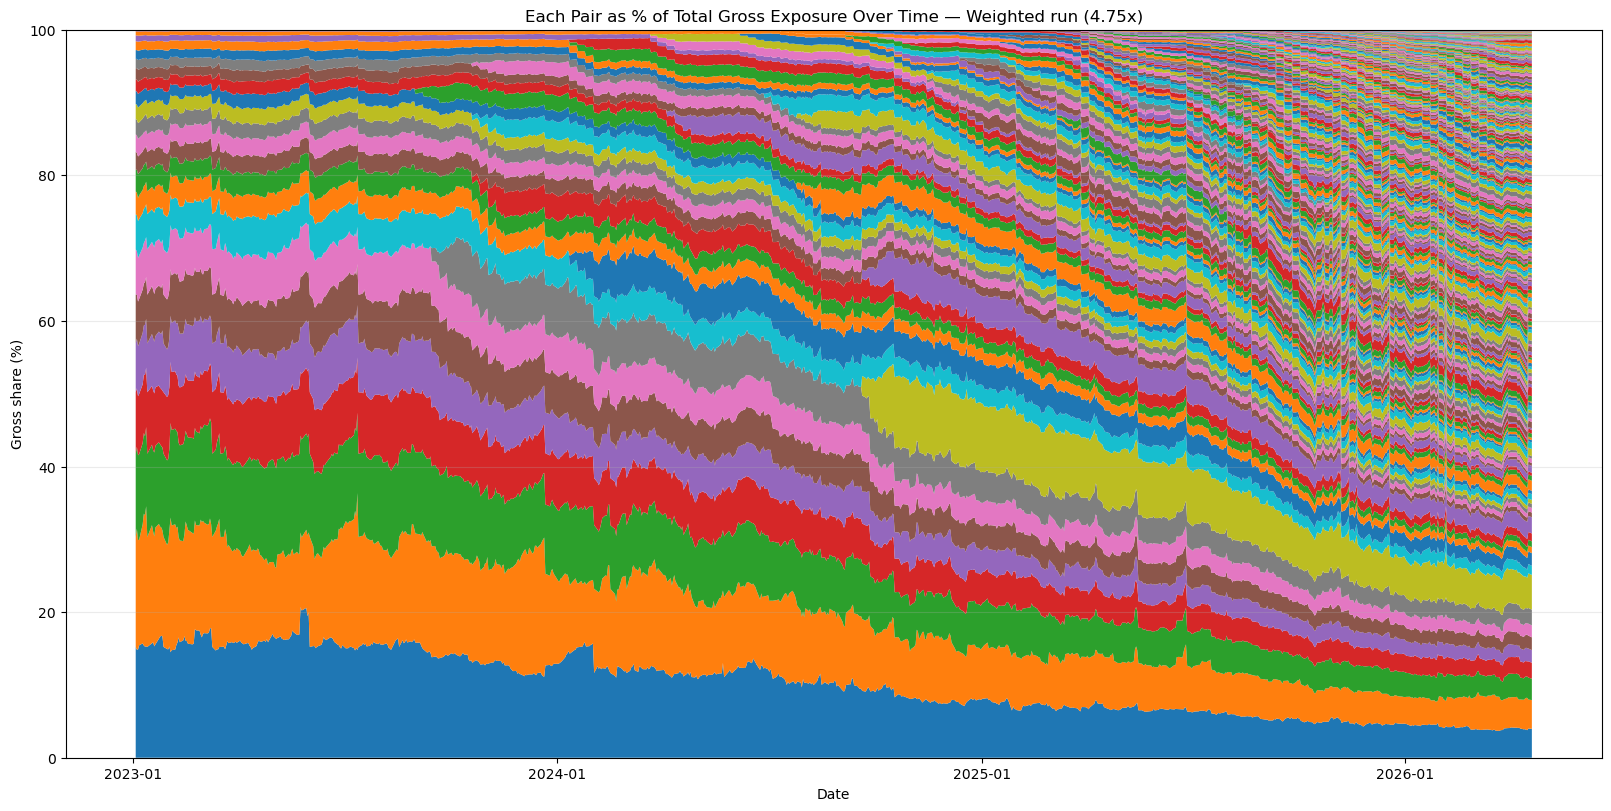

Pairs plotted: 250 | Date range: 2023-01-03 -> 2026-04-20
Top 15 pairs by average gross share (%):


,avg_gross_share_pct
NVDA/NVDL,10.073805
COIN/CONL,9.560316
META/FBL,7.540753
AMZN/AMZU,5.421956
TSLA/TSLL,4.309019
MSFT/MSFU,4.298499
GOOGL/GGLL,4.029865
NVDA/NVDU,3.433775
MSTR/MSTZ,3.344656
GDX/GDXU,3.119563


In [23]:
# ---- Pair gross share over time (% of total gross; each pair) ----
# Uses the most recent weighted run by default.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

if "ALL_PAIR_GROSS" in globals() and isinstance(ALL_PAIR_GROSS, dict) and len(ALL_PAIR_GROSS) > 0:
    ref_lev = max(ALL_PAIR_GROSS)
    gross_df = ALL_PAIR_GROSS[ref_lev].copy()
    run_label = f"Weighted run ({ref_lev}x)"
elif "EW_PAIR_GROSS" in globals() and isinstance(EW_PAIR_GROSS, dict) and len(EW_PAIR_GROSS) > 0:
    ref_lev = max(EW_PAIR_GROSS)
    gross_df = EW_PAIR_GROSS[ref_lev].copy()
    run_label = f"Equal-weight run ({ref_lev}x)"
else:
    raise RuntimeError("No pair gross time series found. Run a backtest cell first.")

if gross_df is None or gross_df.empty:
    raise RuntimeError("Pair gross time series is empty.")

# Ensure datetime index + numeric matrix.
gross_df = gross_df.copy()
gross_df.index = pd.to_datetime(gross_df.index)
gross_df = gross_df.apply(pd.to_numeric, errors="coerce").fillna(0.0)

# % share of total gross exposure each day.
total_gross = gross_df.sum(axis=1).replace(0.0, np.nan)
pair_gross_pct = gross_df.div(total_gross, axis=0).fillna(0.0) * 100.0

# Sort pairs for a stable stacked ordering (largest average share at bottom).
pair_order = pair_gross_pct.mean(axis=0).sort_values(ascending=False).index.tolist()
pair_gross_pct = pair_gross_pct[pair_order]

fig, ax = plt.subplots(figsize=(16, 8), layout="constrained")
ax.stackplot(pair_gross_pct.index, pair_gross_pct.T.values, linewidth=0)
ax.set_title(f"Each Pair as % of Total Gross Exposure Over Time — {run_label}")
ax.set_ylabel("Gross share (%)")
ax.set_xlabel("Date")
ax.set_ylim(0, 100)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.grid(axis="y", alpha=0.25)
plt.show()

print(f"Pairs plotted: {pair_gross_pct.shape[1]} | Date range: {pair_gross_pct.index.min().date()} -> {pair_gross_pct.index.max().date()}")
print("Top 15 pairs by average gross share (%):")
display(pair_gross_pct.mean().sort_values(ascending=False).head(15).to_frame("avg_gross_share_pct"))

In [24]:
# ---- Quarterly return facts (v11): gross vs net-to-LP ----

import numpy as np
import pandas as pd


def quarterly_return_table(daily_ret: pd.Series) -> pd.DataFrame:
    r = daily_ret.dropna().copy()
    r.index = pd.to_datetime(r.index)
    r = r.sort_index()

    q_ret = (1.0 + r).resample("Q").prod() - 1.0

    rows = []
    for y in sorted(q_ret.index.year.unique()):
        qy = q_ret[q_ret.index.year == y]
        out = {"Year": y, "Q1": np.nan, "Q2": np.nan, "Q3": np.nan, "Q4": np.nan, "FY / YTD": np.nan}

        for ts, val in qy.items():
            q = pd.Timestamp(ts).quarter
            out[f"Q{q}"] = float(val)

        out["FY / YTD"] = float((1.0 + qy).prod() - 1.0) if len(qy) > 0 else np.nan
        rows.append(out)

    df = pd.DataFrame(rows).set_index("Year")
    return df.loc[df.notna().any(axis=1)]


def format_pct_table(df: pd.DataFrame) -> pd.DataFrame:
    def fmt(x):
        if pd.isna(x):
            return ""
        return f"({abs(x) * 100:.1f}%)" if x < 0 else f"{x * 100:.1f}%"

    return df.applymap(fmt)


if "dc_gross_ret" not in globals() or "dc_net_ret" not in globals():
    raise RuntimeError("Run the fee/performance cell first so dc_gross_ret and dc_net_ret exist.")

END_DATE = pd.Timestamp("2026-03-31")
dc_gross_ret_cut = dc_gross_ret.loc[dc_gross_ret.index <= END_DATE].copy()
dc_net_ret_cut = dc_net_ret.loc[dc_net_ret.index <= END_DATE].copy()

q_table_gross = quarterly_return_table(dc_gross_ret_cut)
q_table_net = quarterly_return_table(dc_net_ret_cut)

print("\n=== Quarterly Performance (Gross of Fund Fees) ===")
print(format_pct_table(q_table_gross).to_string())

print("\n=== Quarterly Performance (Net to LPs, 2/20 w/ quarterly HWM, no hurdle) ===")
print(format_pct_table(q_table_net).to_string())


=== Quarterly Performance (Gross of Fund Fees) ===
         Q1     Q2    Q3     Q4 FY / YTD
Year                                    
2023  29.5%  14.7%  2.9%  16.3%    77.8%
2024   5.3%   2.2%  0.7%   7.4%    16.3%
2025  11.9%   7.0%  1.6%   4.5%    27.1%
2026  15.6%                        15.6%

=== Quarterly Performance (Net to LPs, 2/20 w/ quarterly HWM, no hurdle) ===
         Q1     Q2    Q3     Q4 FY / YTD
Year                                    
2023  24.6%  11.6%  2.0%  12.9%    60.2%
2024   3.9%   1.3%  0.1%   5.5%    11.2%
2025   9.2%   5.2%  0.9%   3.2%    19.7%
2026  15.0%                        15.0%


In [ ]:
# ---- Relative performance facts (v11): Diamond Creek gross/net vs SPY ----

import numpy as np
import pandas as pd

TRADING_DAYS = 252


def max_drawdown_from_curve(curve: pd.Series) -> float:
    dd = curve / curve.cummax() - 1.0
    return float(dd.min())


def sharpe_ratio(ret: pd.Series, rf_annual: float = 0.00) -> float:
    ret = ret.dropna()
    if ret.empty:
        return np.nan
    rf_daily = (1.0 + rf_annual) ** (1.0 / TRADING_DAYS) - 1.0
    ex = ret - rf_daily
    vol = ex.std(ddof=0)
    if vol == 0 or np.isnan(vol):
        return np.nan
    return float(ex.mean() / vol * np.sqrt(TRADING_DAYS))


def sortino_ratio(ret: pd.Series, rf_annual: float = 0.00, mar_annual: float | None = None) -> float:
    ret = ret.dropna()
    if ret.empty:
        return np.nan
    mar_annual = rf_annual if mar_annual is None else mar_annual
    mar_daily = (1.0 + mar_annual) ** (1.0 / TRADING_DAYS) - 1.0
    downside = (ret - mar_daily).clip(upper=0.0)
    downside_dev = np.sqrt((downside**2).mean())
    if downside_dev == 0 or np.isnan(downside_dev):
        return np.nan
    excess_mean_daily = (ret - mar_daily).mean()
    return float(excess_mean_daily / downside_dev * np.sqrt(TRADING_DAYS))


def perf_from_returns(ret: pd.Series, label: str, rf_annual: float = 0.00) -> dict:
    ret = ret.dropna()
    if ret.empty:
        return {
            "Series": label,
            "Start": None,
            "End": None,
            "AnnReturn": np.nan,
            "AnnVol": np.nan,
            "MaxDD": np.nan,
            "Sharpe": np.nan,
            "Sortino": np.nan,
            "EndValue10k": np.nan,
        }

    curve = (1.0 + ret).cumprod()
    t = len(ret)
    ann_return = float(curve.iloc[-1] ** (TRADING_DAYS / t) - 1.0)
    ann_vol = float(ret.std(ddof=0) * np.sqrt(TRADING_DAYS))
    mdd = max_drawdown_from_curve(curve)

    return {
        "Series": label,
        "Start": ret.index.min().date(),
        "End": ret.index.max().date(),
        "AnnReturn": ann_return,
        "AnnVol": ann_vol,
        "MaxDD": mdd,
        "Sharpe": sharpe_ratio(ret, rf_annual=rf_annual),
        "Sortino": sortino_ratio(ret, rf_annual=rf_annual),
        "EndValue10k": float(10_000.0 * curve.iloc[-1]),
    }


if "dc_gross_ret" not in globals() or "dc_net_ret" not in globals():
    raise RuntimeError("Run the fee/performance cell first so dc_gross_ret and dc_net_ret exist.")

if "spy_ret" not in globals():
    if "get_total_return_series" in globals():
        _spy_px = get_total_return_series("SPY").copy()
    else:
        if "PRICES" not in globals() or "SPY" not in PRICES:
            raise RuntimeError("Need spy_ret in globals or SPY total return source available.")
        _spy_px = PRICES["SPY"].copy()
    _spy_px = _normalize_index_to_date(_spy_px)
    spy_ret = _spy_px.pct_change().fillna(0.0)

END_DATE = pd.Timestamp("2026-03-31")
dc_gross_ret_cut = dc_gross_ret.loc[dc_gross_ret.index <= END_DATE].copy()
dc_net_ret_cut = dc_net_ret.loc[dc_net_ret.index <= END_DATE].copy()
spy_ret_cut = spy_ret.loc[spy_ret.index <= END_DATE].copy()

common_idx = dc_gross_ret_cut.index.intersection(dc_net_ret_cut.index).intersection(spy_ret_cut.index)
if len(common_idx) == 0:
    raise RuntimeError("No overlap between Diamond Creek gross/net returns and SPY after end-date cap.")

rf_annual = 0.00
rows = [
    perf_from_returns(dc_gross_ret_cut.loc[common_idx], "Diamond Creek (Gross of Fund Fees)", rf_annual=rf_annual),
    perf_from_returns(dc_net_ret_cut.loc[common_idx], "Diamond Creek (Net to LPs)", rf_annual=rf_annual),
    perf_from_returns(spy_ret_cut.loc[common_idx], "SPY (Total Return)", rf_annual=rf_annual),
]

stats_df = pd.DataFrame(rows)
fmt = stats_df.copy()
for c in ["AnnReturn", "AnnVol", "MaxDD"]:
    fmt[c] = (fmt[c] * 100).map(lambda x: f"{x:,.1f}%" if pd.notna(x) else "")
for c in ["Sharpe", "Sortino"]:
    fmt[c] = fmt[c].map(lambda x: f"{x:,.2f}" if pd.notna(x) else "")
fmt["EndValue10k"] = fmt["EndValue10k"].map(lambda x: f"${x:,.0f}" if pd.notna(x) else "")

print("\n=== Backtest Summary (Diamond Creek Gross vs Net vs SPY) ===")
print(fmt[["Series", "Start", "End", "AnnReturn", "AnnVol", "MaxDD", "Sharpe", "Sortino", "EndValue10k"]].to_string(index=False))

if "dc_fee_diag" in globals() and isinstance(dc_fee_diag, pd.DataFrame) and (not dc_fee_diag.empty):
    print("\n=== Recent Fee Crystallizations (last 8) ===")
    cols = ["QuarterEnd", "MgmtFee_amt", "PerfFee_amt", "EndNAV_postFees", "HWM_postFees", "QuarterGrossRet", "QuarterNetRet"]
    diag_view = dc_fee_diag[cols].tail(8).copy()
    print(diag_view.to_string(index=False))


=== Backtest Summary (Diamond Creek Gross vs Net vs SPY) ===
                            Series      Start        End AnnReturn AnnVol  MaxDD Sharpe Sortino EndValue10k
Diamond Creek (Gross of Fund Fees) 2023-01-03 2026-03-31     41.1%  13.8%  -6.9%   2.57    5.28     $30,399
        Diamond Creek (Net to LPs) 2023-01-03 2026-03-31     32.1%  14.1%  -7.7%   2.04    3.89     $24,531
                SPY (Total Return) 2023-01-03 2026-03-31     19.4%  15.3% -18.8%   1.24    1.85     $17,739

=== Recent Fee Crystallizations (last 8) ===
QuarterEnd  MgmtFee_amt  PerfFee_amt  EndNAV_postFees  HWM_postFees  QuarterGrossRet  QuarterNetRet
2024-06-28     0.009132     0.005339         1.678235      1.678235         0.016615      -0.081159
2024-09-30     0.009284     0.000598         1.680708      1.680708         0.001830      -0.094843
2024-12-31     0.009301     0.022394         1.773308      1.773308         0.068420      -0.046718
2025-03-31     0.009937     0.037584         1.937182      1

: 

In [ ]:
# ---- V11 scatter: strategy daily returns vs SPY (beta + R^2) ----

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.linear_model import LinearRegression


def _to_date_index(s: pd.Series) -> pd.Series:
    s = s.copy()
    idx = pd.to_datetime(s.index)
    if getattr(idx, "tz", None) is not None:
        idx = idx.tz_convert("UTC").tz_localize(None)
    idx = idx.normalize()
    s.index = idx
    s = s[~s.index.duplicated(keep="last")]
    return s.sort_index()


def load_adjclose_returns(ticker: str, start: str) -> pd.Series:
    df = yf.download(
        ticker,
        start=start,
        auto_adjust=False,
        progress=False,
        threads=False,
        timeout=30,
    )
    if df is None or df.empty:
        return pd.Series(dtype=float, name=ticker)

    col = "Adj Close" if "Adj Close" in df.columns else "Close"
    px = df[col]
    if isinstance(px, pd.DataFrame):
        px = px.iloc[:, 0]
    px = px.dropna().astype(float)
    px.index = pd.to_datetime(px.index).tz_localize(None)

    ret = px.pct_change().dropna()
    ret.name = ticker
    return _to_date_index(ret)


def plot_spy_scatter_with_beta_r2(
    port_ret: pd.Series,
    start: str | None = "2023-01-01",
    end: str | None = "2026-03-31",
    title: str = "Diamond Creek ETF Arb Fund: Market Sensitivity",
    spy_ret_external: pd.Series | None = None,
):
    y = port_ret.replace([np.inf, -np.inf], np.nan).dropna()
    if start is not None:
        y = y.loc[pd.Timestamp(start):]
    if end is not None:
        y = y.loc[:pd.Timestamp(end)]
    y = _to_date_index(y)

    if spy_ret_external is not None:
        spy = _to_date_index(spy_ret_external)
        if start is not None:
            spy = spy.loc[pd.Timestamp(start):]
        if end is not None:
            spy = spy.loc[:pd.Timestamp(end)]
    else:
        spy = load_adjclose_returns("SPY", start=str(y.index.min().date()))
        if end is not None:
            spy = spy.loc[:pd.Timestamp(end)]
        spy = _to_date_index(spy)

    df = pd.concat([spy.rename("SPY"), y.rename("STRAT")], axis=1).dropna()
    if len(df) < 50:
        raise ValueError(f"Not enough overlapping observations: {len(df)}")

    x = df[["SPY"]].to_numpy()
    yv = df["STRAT"].to_numpy()

    lr = LinearRegression(fit_intercept=True)
    lr.fit(x, yv)

    beta = float(lr.coef_[0])
    r2 = float(lr.score(x, yv))
    corr = float(df[["SPY", "STRAT"]].corr().iloc[0, 1])
    r2_corr = corr**2

    # Display scaling only: widen x-axis so fit line appears less steep visually.
    x_abs = float(np.nanmax(np.abs(df["SPY"].to_numpy())))
    y_abs = float(np.nanmax(np.abs(df["STRAT"].to_numpy())))
    x_lim = max(0.01, 1.35 * x_abs)
    y_lim = max(0.01, 1.10 * y_abs)

    x_line = np.linspace(-x_lim, x_lim, 300).reshape(-1, 1)
    y_line = lr.predict(x_line)

    plt.figure(figsize=(10.5, 6.2))
    plt.scatter(df["SPY"], df["STRAT"], alpha=0.65, s=28)
    plt.plot(x_line.flatten(), y_line, linewidth=2.5)

    plt.axhline(0, linewidth=1)
    plt.axvline(0, linewidth=1)
    plt.xlim(-y_lim, y_lim)
    plt.ylim(-y_lim, y_lim)

    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.title(title)
    plt.xlabel("SPY daily return")
    plt.ylabel("Strategy daily return")

    plt.text(
        0.98,
        0.92,
        f"Beta: {beta:.2f} | R^2: {r2:.2f}",
        transform=plt.gca().transAxes,
        ha="right",
        va="top",
        fontsize=12,
    )

    plt.tight_layout()
    plt.savefig("diamond_creek_spy_scatter_v11.svg", format="svg", bbox_inches="tight")
    plt.show()
    return {
        "beta": beta,
        "r2": r2,
        "r2_corr_check": r2_corr,
        "r2_abs_diff": abs(r2 - r2_corr),
        "n_obs": int(len(df)),
    }


# Prefer net-to-LP series for market-sensitivity reporting.
if "dc_net_ret" in globals():
    _port_ret_for_scatter = dc_net_ret.copy()
elif "dc_gross_ret" in globals():
    _port_ret_for_scatter = dc_gross_ret.copy()
else:
    raise RuntimeError("Run the v11 performance cell first so dc_net_ret or dc_gross_ret exists.")

_spy_ret_for_scatter = spy_ret.copy() if "spy_ret" in globals() else None

scatter_stats = plot_spy_scatter_with_beta_r2(
    _port_ret_for_scatter,
    start="2023-01-01",
    end="2026-03-31",
    title="Diamond Creek ETF Arb Fund: Market Sensitivity",
    spy_ret_external=_spy_ret_for_scatter,
)
print(scatter_stats)

if scatter_stats["r2_abs_diff"] > 1e-10:
    print(f"[WARN] R^2 cross-check diff is non-trivial: {scatter_stats['r2_abs_diff']:.3e}")
else:
    print("R^2 cross-check passed (OLS score ~= corr^2 for single-factor regression).")

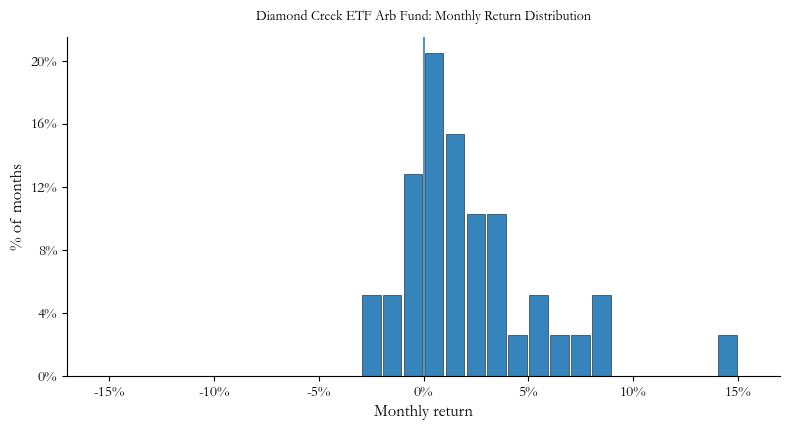

{'n_months': 39, 'mean_monthly': 0.022185969456057338, 'median_monthly': 0.01353811728834664, 'pct_positive_months': 0.7692307692307693, 'worst_month': -0.027497679736149805, 'best_month': 0.14554110187792269}


: 

In [ ]:
# ---- V11 monthly return distribution ----

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib import font_manager as fm
from matplotlib.ticker import FuncFormatter, MaxNLocator


def plot_monthly_return_distribution_clean(
    port_ret_daily: pd.Series,
    title: str = "Diamond Creek ETF Arb Fund: Monthly Return Distribution",
    bin_width: float = 0.01,
    xlim: float = 0.06,
    show_mean: bool = False,
    start: str | None = "2023-01-01",
    end: str | None = "2026-03-31",
    font_family: str = "Garamond",
    savepath: str | None = None,
):
    r = port_ret_daily.replace([np.inf, -np.inf], np.nan).dropna().copy()
    r.index = pd.to_datetime(r.index)
    if getattr(r.index, "tz", None) is not None:
        r.index = r.index.tz_convert("UTC").tz_localize(None)
    r.index = r.index.normalize()

    if start is not None:
        r = r.loc[pd.Timestamp(start):]
    if end is not None:
        r = r.loc[:pd.Timestamp(end)]

    monthly = (1.0 + r).resample("M").prod() - 1.0
    monthly = monthly.dropna()

    monthly_plot = monthly[np.abs(monthly) <= xlim]

    bins = np.arange(-xlim, xlim + bin_width, bin_width)
    counts, edges = np.histogram(monthly_plot, bins=bins)
    pct = counts / counts.sum() * 100 if counts.sum() > 0 else np.zeros_like(counts, dtype=float)
    centers = 0.5 * (edges[:-1] + edges[1:])

    pct_fmt = FuncFormatter(lambda y, _: f"{y:.0f}%")
    ret_fmt = FuncFormatter(lambda x, _: f"{100 * x:.0f}%")

    # Lock font for PPT consistency.
    font_prop = None
    _font_candidates = [
        Path(f"C:/Windows/Fonts/{str(font_family).lower()}.ttf"),
        Path(f"C:/Windows/Fonts/{str(font_family).lower()}.ttc"),
        Path("C:/Windows/Fonts/garamond.ttf"),
        Path("C:/Windows/Fonts/garamond.ttc"),
        Path("C:/Windows/Fonts/gara.ttf"),
        Path("C:/Windows/Fonts/garabd.ttf"),
        Path("C:/Windows/Fonts/cambria.ttc"),
        Path("C:/Windows/Fonts/calibri.ttf"),
    ]
    _font_path = next((p for p in _font_candidates if p.exists()), None)
    if _font_path is not None:
        font_prop = fm.FontProperties(fname=str(_font_path))
    else:
        plt.rcParams["font.family"] = font_family
    fig, ax = plt.subplots(figsize=(8.0, 4.4))
    pos_color = "#1f77b4"
    neg_color = "#ff7f0e"
    bar_colors = [neg_color if c < 0 else pos_color for c in centers]
    ax.bar(
        centers,
        pct,
        width=bin_width * 0.9,
        color=bar_colors,
        edgecolor="black",
        linewidth=0.4,
        alpha=0.9,
    )

    ax.axvline(0, linewidth=1.1)
    if show_mean:
        ax.axvline(monthly.mean(), linestyle="--", linewidth=1)

    if font_prop is not None:
        ax.set_title(title, fontsize=14, pad=12, fontproperties=font_prop)
        ax.set_xlabel("Monthly return", fontsize=12, fontproperties=font_prop)
        ax.set_ylabel("% of months", fontsize=12, fontproperties=font_prop)
        for _lbl in list(ax.get_xticklabels()) + list(ax.get_yticklabels()):
            _lbl.set_fontproperties(font_prop)
    else:
        ax.set_title(title, fontsize=14, pad=12)
        ax.set_xlabel("Monthly return", fontsize=12)
        ax.set_ylabel("% of months", fontsize=12)

    ax.set_xlim(-xlim, xlim)
    ax.xaxis.set_major_formatter(ret_fmt)
    ax.yaxis.set_major_formatter(pct_fmt)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=6))
    ax.tick_params(axis="both", labelsize=11)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)

    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")
    fig.savefig("monthly_return_distribution_v11.svg", format="svg", bbox_inches="tight")

    plt.show()

    return {
        "n_months": int(len(monthly)),
        "mean_monthly": float(monthly.mean()) if len(monthly) else np.nan,
        "median_monthly": float(monthly.median()) if len(monthly) else np.nan,
        "pct_positive_months": float((monthly > 0).mean()) if len(monthly) else np.nan,
        "worst_month": float(monthly.min()) if len(monthly) else np.nan,
        "best_month": float(monthly.max()) if len(monthly) else np.nan,
    }


if "dc_net_ret" in globals():
    _port_ret_for_monthly = dc_net_ret.copy()
elif "dc_gross_ret" in globals():
    _port_ret_for_monthly = dc_gross_ret.copy()
else:
    raise RuntimeError("Run the v11 performance cell first so dc_net_ret or dc_gross_ret exists.")

monthly_stats = plot_monthly_return_distribution_clean(
    _port_ret_for_monthly,
    bin_width=0.01,
    xlim=0.17,
    start="2023-01-01",
    end="2026-03-31",
    savepath="monthly_return_distribution_v11.png",
)
print(monthly_stats)

In [ ]:
# ---- Verify quarterly NAV math: gross vs post-fees (explicit path) ----

import numpy as np
import pandas as pd

if "dc_gross_ret" not in globals() or dc_gross_ret is None or len(dc_gross_ret) == 0:
    raise RuntimeError("Run fee/performance cell first so dc_gross_ret exists.")

END_DATE = pd.Timestamp("2026-03-31")
r = dc_gross_ret.loc[dc_gross_ret.index <= END_DATE].dropna().copy()
r.index = pd.to_datetime(r.index)
r = r.sort_index()

if "MGMT_FEE_Q" not in globals() or "INCENTIVE_FEE" not in globals():
    raise RuntimeError("Missing fee params MGMT_FEE_Q / INCENTIVE_FEE in scope.")

mgmt_fee_q = float(MGMT_FEE_Q)
incentive_fee = float(INCENTIVE_FEE)

idx = pd.DatetimeIndex(r.index)
periods = idx.to_period("Q")
q_starts = pd.Series(idx, index=idx).groupby(periods).min().sort_values().to_list()
q_ends = pd.Series(idx, index=idx).groupby(periods).max().sort_values().to_list()
q_starts = [pd.Timestamp(x) for x in q_starts]
q_ends = [pd.Timestamp(x) for x in q_ends]
q_start_set = set(q_starts)
q_end_set = set(q_ends)

# Pass 1: gross + mgmt at quarter start (same as model)
NAV0_USD = 10_000_000.0
nav = NAV0_USD
nav_series = pd.Series(index=idx, dtype=float)
fee_rows = []
q_start_nav = nav
q_mgmt_fee_amt = 0.0

for t in idx:
    if t in q_start_set:
        q_start_nav = nav
        q_mgmt_fee_amt = mgmt_fee_q * q_start_nav
        nav = q_start_nav - q_mgmt_fee_amt
    nav *= (1.0 + float(r.loc[t]))
    nav_series.loc[t] = nav

    if t in q_end_set:
        nav_pre_fees = nav
        fee_rows.append(
            {
                "QuarterEnd": t,
                "Year": int(pd.Timestamp(t).year),
                "Quarter": int(pd.Timestamp(t).quarter),
                "StartNAV": float(q_start_nav),
                "MgmtFee_amt": float(q_mgmt_fee_amt),
                "EndNAV_postMgmt": float(nav_pre_fees),
                "QuarterGrossRet": float((nav_pre_fees / q_start_nav) - 1.0),
            }
        )

fee_df = pd.DataFrame(fee_rows)

# Pass 2: annual promote with calibrated quarterly re-crystallization
nav_post = nav_series.copy()
perf_fee_by_q = {q: 0.0 for q in q_ends}
year_summary = []
hwm = NAV0_USD
years = sorted(idx.year.unique())

for y in years:
    y_idx = idx[idx.year == y]
    if len(y_idx) < 2:
        continue

    y_end = y_idx[-1]
    is_full_year = pd.Timestamp(y_end).month == 12
    if (y == years[-1]) and (not is_full_year):
        year_summary.append({
            "Year": y,
            "YearStartNAV_postMgmtPath": float(nav_post.loc[y_idx[0]]),
            "YearEndNAV_postMgmt_prePromote": float(nav_post.loc[y_end]),
            "Promote_OneShot": 0.0,
            "YearEndNAV_OneShotTarget": float(nav_post.loc[y_end]),
            "YearEndNAV_CalibratedQuarterly": float(nav_post.loc[y_end]),
            "CalibDiff": 0.0,
            "PromoteApplied_CalibratedQuarterly": 0.0,
            "HWM_before_year": float(hwm),
            "FullYearPromoteApplied": False,
        })
        continue

    y_end_nav_pre_perf = float(nav_post.loc[y_end])
    gate = hwm
    incentive_base = max(y_end_nav_pre_perf - gate, 0.0)
    total_perf_fee = incentive_fee * incentive_base
    target_end_nav = y_end_nav_pre_perf - total_perf_fee

    y_q_ends = [q for q in q_ends if q.year == y and q in nav_post.index]
    y_fee_rows = fee_df[fee_df["Year"] == y].copy()

    if total_perf_fee > 0 and y_q_ends:
        pnl_map = {}
        for _, rr in y_fee_rows.iterrows():
            q = pd.Timestamp(rr["QuarterEnd"])
            q_pnl_after_mgmt = float(rr["EndNAV_postMgmt"] - rr["StartNAV"])
            pnl_map[q] = max(0.0, q_pnl_after_mgmt)

        w = pd.Series({q: pnl_map.get(q, 0.0) for q in y_q_ends}, dtype=float)
        if float(w.sum()) <= 0:
            w = nav_post.loc[y_q_ends].astype(float).clip(lower=1e-12)
        w = w / w.sum()

        base_alloc = {q: float(total_perf_fee * w.loc[q]) for q in y_q_ends}

        def _apply_alloc(alpha: float):
            nav_tmp = nav_post.copy()
            applied = {q: 0.0 for q in y_q_ends}
            for q in y_q_ends:
                q_nav = float(nav_tmp.loc[q])
                fee_amt = max(0.0, float(alpha * base_alloc[q]))
                fee_amt = min(fee_amt, max(0.0, q_nav - 1e-12))
                applied[q] = fee_amt
                scale = max(0.0, 1.0 - fee_amt / max(q_nav, 1e-12))
                nav_tmp.loc[q:] = nav_tmp.loc[q:] * scale
            return float(nav_tmp.loc[y_end]), applied, nav_tmp

        lo, hi = 0.0, 1.0
        end_hi, _, _ = _apply_alloc(hi)
        while end_hi > target_end_nav and hi < 10.0:
            hi *= 1.5
            end_hi, _, _ = _apply_alloc(hi)

        for _ in range(50):
            mid = 0.5 * (lo + hi)
            end_mid, _, _ = _apply_alloc(mid)
            if end_mid > target_end_nav:
                lo = mid
            else:
                hi = mid

        end_cal, applied_map, nav_cal = _apply_alloc(hi)
        nav_post = nav_cal
        for q, fee_amt in applied_map.items():
            perf_fee_by_q[q] += float(fee_amt)

        promote_applied = float(sum(applied_map.values()))
    else:
        end_cal = y_end_nav_pre_perf
        promote_applied = 0.0

    year_summary.append({
        "Year": y,
        "YearStartNAV_postMgmtPath": float(nav_post.loc[y_idx[0]]),
        "YearEndNAV_postMgmt_prePromote": float(y_end_nav_pre_perf),
        "Promote_OneShot": float(total_perf_fee),
        "YearEndNAV_OneShotTarget": float(target_end_nav),
        "YearEndNAV_CalibratedQuarterly": float(end_cal),
        "CalibDiff": float(end_cal - target_end_nav),
        "PromoteApplied_CalibratedQuarterly": float(promote_applied),
        "HWM_before_year": float(gate),
        "FullYearPromoteApplied": True,
    })

    hwm = max(hwm, float(nav_post.loc[y_end]))

# Build quarter-level table with pre/post fee NAV + quarter returns
q_tbl = fee_df.copy()
q_tbl["QuarterLabel"] = q_tbl["Year"].astype(str) + "Q" + q_tbl["Quarter"].astype(str)
q_tbl["EndNAV_postFees"] = q_tbl["QuarterEnd"].map(nav_post).astype(float)
q_tbl["PerfFee_alloc_amt"] = q_tbl["QuarterEnd"].map(perf_fee_by_q).fillna(0.0).astype(float)
q_tbl["QuarterNetRet_postAllFees"] = (q_tbl["EndNAV_postFees"] / q_tbl["StartNAV"]) - 1.0
q_tbl["MgmtFee_rate_check"] = q_tbl["MgmtFee_amt"] / q_tbl["StartNAV"]
q_tbl = q_tbl[[
    "QuarterLabel", "StartNAV", "MgmtFee_amt", "EndNAV_postMgmt",
    "PerfFee_alloc_amt", "EndNAV_postFees", "QuarterGrossRet", "QuarterNetRet_postAllFees", "MgmtFee_rate_check"
]].copy()

# Year-level comp check
q_tbl["Year"] = q_tbl["QuarterLabel"].str.slice(0, 4).astype(int)
comp_rows = []
for y, g in q_tbl.groupby("Year"):
    g = g.sort_values("QuarterLabel")
    gross_ytd = float((1.0 + g["QuarterGrossRet"]).prod() - 1.0)
    net_ytd = float((1.0 + g["QuarterNetRet_postAllFees"]).prod() - 1.0)
    comp_rows.append({"Year": y, "Gross_YTD_from_QComp": gross_ytd, "Net_YTD_from_QComp": net_ytd})
comp_df = pd.DataFrame(comp_rows)

year_df = pd.DataFrame(year_summary)
check_df = year_df.merge(comp_df, on="Year", how="left") if not year_df.empty else year_df

print("\nQuarter-by-quarter NAV path (start NAV = $10,000,000)")
display(q_tbl.round(8))

print("\nYear-level promote calibration check")
# CalibDiff should be near zero for full years (floating-point tolerance).
display(check_df.round(10))

if not check_df.empty and "CalibDiff" in check_df.columns:
    print("Max |CalibDiff|:", float(check_df["CalibDiff"].abs().max()))


Quarter-by-quarter NAV path (start NAV = $10,000,000)


,QuarterLabel,StartNAV,MgmtFee_amt,EndNAV_postMgmt,PerfFee_alloc_amt,EndNAV_postFees,QuarterGrossRet,QuarterNetRet_postAllFees,MgmtFee_rate_check,Year
0,2023Q1,1.000000e+07,50000.000000,1.263557e+07,451160.324062,1.218441e+07,0.263557,0.218441,0.005,2023
1,2023Q2,1.263557e+07,63177.827886,1.437720e+07,298135.232940,1.356572e+07,0.137836,0.073614,0.005,2023
2,2023Q3,1.437720e+07,71885.984559,1.459646e+07,37533.277998,1.373507e+07,0.015251,-0.044663,0.005,2023
3,2023Q4,1.459646e+07,72982.284590,1.651401e+07,328250.003647,1.521121e+07,0.131371,0.042117,0.005,2023
4,2024Q1,1.651401e+07,82570.055990,1.737077e+07,151240.038538,1.584913e+07,0.051880,-0.040261,0.005,2024
5,2024Q2,1.737077e+07,86853.826639,1.773880e+07,64967.287284,1.611996e+07,0.021187,-0.072006,0.005,2024
6,2024Q3,1.773880e+07,88693.980616,1.776868e+07,5274.493863,1.614184e+07,0.001684,-0.090026,0.005,2024
7,2024Q4,1.776868e+07,88843.377047,1.899200e+07,215949.630401,1.703721e+07,0.068847,-0.041166,0.005,2024
8,2025Q1,1.899200e+07,94960.002627,2.107270e+07,348259.926303,1.855549e+07,0.109557,-0.022984,0.005,2025
9,2025Q2,2.107270e+07,105363.503696,2.242271e+07,225960.300153,1.951828e+07,0.064065,-0.073765,0.005,2025



Year-level promote calibration check


,Year,YearStartNAV_postMgmtPath,YearEndNAV_postMgmt_prePromote,Promote_OneShot,YearEndNAV_OneShotTarget,YearEndNAV_CalibratedQuarterly,CalibDiff,PromoteApplied_CalibratedQuarterly,HWM_before_year,FullYearPromoteApplied,Gross_YTD_from_QComp,Net_YTD_from_QComp
0,2023,9.950000e+06,1.651401e+07,1.302802e+06,1.521121e+07,1.521121e+07,0.000000e+00,1.115079e+06,1.000000e+07,True,0.651401,0.302342
1,2024,1.490846e+07,1.749371e+07,4.564998e+05,1.703721e+07,1.703721e+07,-3.700000e-09,4.374315e+05,1.521121e+07,True,0.150054,-0.222912
2,2025,1.702843e+07,2.117566e+07,8.276909e+05,2.034797e+07,2.034797e+07,0.000000e+00,7.721550e+05,1.703721e+07,True,0.242907,-0.286727
3,2026,2.029627e+07,2.333531e+07,0.000000e+00,2.333531e+07,2.333531e+07,0.000000e+00,0.000000e+00,2.034797e+07,False,0.146813,-0.011437


Max |CalibDiff|: 3.725290298461914e-09


In [ ]:
# ---- Reconciliation (fixed): quarter-period keyed to avoid quarter-end date mismatch ----

import numpy as np
import pandas as pd

if "dc_gross_ret" not in globals() or "dc_net_ret" not in globals():
    raise RuntimeError("Run fee/performance cell first so dc_gross_ret and dc_net_ret exist.")

END_DATE = pd.Timestamp("2026-03-31")
NAV0_USD = 10_000_000.0

gross_r = dc_gross_ret.loc[dc_gross_ret.index <= END_DATE].dropna().copy()
net_r = dc_net_ret.loc[dc_net_ret.index <= END_DATE].dropna().copy()

gross_r.index = pd.to_datetime(gross_r.index)
net_r.index = pd.to_datetime(net_r.index)

gross_r = gross_r.sort_index()
net_r = net_r.sort_index()

common_idx = gross_r.index.intersection(net_r.index)
if len(common_idx) == 0:
    raise RuntimeError("No overlap between gross and net daily return series.")

gross_r = gross_r.loc[common_idx]
net_r = net_r.loc[common_idx]

def _q_ret_from_daily(r: pd.Series) -> pd.Series:
    return (1.0 + r).resample("Q").prod() - 1.0

q_gross = _q_ret_from_daily(gross_r)
q_net = _q_ret_from_daily(net_r)

# Re-key to PeriodIndex so quarter matching does not depend on exact timestamp labels.
q_gross_by_period = q_gross.copy()
q_gross_by_period.index = q_gross_by_period.index.to_period("Q")
q_net_by_period = q_net.copy()
q_net_by_period.index = q_net_by_period.index.to_period("Q")

gross_nav = NAV0_USD * (1.0 + gross_r).cumprod()
net_nav = NAV0_USD * (1.0 + net_r).cumprod()

periods = common_idx.to_period("Q")
q_start_dates = pd.Series(common_idx, index=common_idx).groupby(periods).min()
q_end_dates = pd.Series(common_idx, index=common_idx).groupby(periods).max()

rows = []
for p in sorted(q_end_dates.index):
    g_slice = gross_nav.loc[gross_nav.index.to_period("Q") == p]
    n_slice = net_nav.loc[net_nav.index.to_period("Q") == p]
    if g_slice.empty or n_slice.empty:
        continue

    rows.append(
        {
            "Quarter": f"{p.year}Q{p.quarter}",
            "Gross_StartNAV_$": float(g_slice.iloc[0]),
            "Gross_EndNAV_$": float(g_slice.iloc[-1]),
            "Gross_QRet": float(q_gross_by_period.loc[p]),
            "Net_StartNAV_$": float(n_slice.iloc[0]),
            "Net_EndNAV_$": float(n_slice.iloc[-1]),
            "Net_QRet": float(q_net_by_period.loc[p]),
        }
    )

recon = pd.DataFrame(rows)
if recon.empty:
    raise RuntimeError("No quarterly rows built for reconciliation.")

recon["Year"] = recon["Quarter"].str.slice(0, 4).astype(int)
ytd_rows = []
for y, g in recon.groupby("Year"):
    ytd_rows.append(
        {
            "Year": int(y),
            "Gross_FY_YTD_from_QComp": float((1.0 + g["Gross_QRet"]).prod() - 1.0),
            "Net_FY_YTD_from_QComp": float((1.0 + g["Net_QRet"]).prod() - 1.0),
        }
    )
ytd = pd.DataFrame(ytd_rows).sort_values("Year")

print("Quarterly reconciliation (exact same quarter return math as printed table)")
display(recon.round(8))

print("\nFY / YTD from quarter comp (exactly as table computes)")
display(ytd.round(10))

if "dc_fee_diag" in globals() and isinstance(dc_fee_diag, pd.DataFrame) and not dc_fee_diag.empty:
    fd = dc_fee_diag.copy()
    fd["QuarterEnd"] = pd.to_datetime(fd["QuarterEnd"])
    fd = fd.loc[fd["QuarterEnd"] <= END_DATE].copy()
    fd["Quarter"] = fd["QuarterEnd"].dt.to_period("Q").astype(str)
    comp = recon[["Quarter", "Net_QRet"]].merge(
        fd[["Quarter", "QuarterNetRet"]], on="Quarter", how="left"
    )
    comp["Diff_NetQRet_minus_FeeDiag"] = comp["Net_QRet"] - comp["QuarterNetRet"]
    print("\nCheck: net quarter return from dc_net_ret vs dc_fee_diag[QuarterNetRet]")
    display(comp.round(10))

Quarterly reconciliation (exact same quarter return math as printed table)


,Quarter,Gross_StartNAV_$,Gross_EndNAV_$,Gross_QRet,Net_StartNAV_$,Net_EndNAV_$,Net_QRet,Year
0,2023Q1,1.000000e+07,1.263630e+07,0.263630,1.000000e+07,1.219352e+07,0.219352,2023
1,2023Q2,1.256278e+07,1.430685e+07,0.132202,1.206197e+07,1.346273e+07,0.104088,2023
2,2023Q3,1.443301e+07,1.463012e+07,0.022596,1.351354e+07,1.365548e+07,0.014318,2023
3,2023Q4,1.475280e+07,1.677741e+07,0.146772,1.370114e+07,1.523166e+07,0.115425,2023
4,2024Q1,1.651542e+07,1.758626e+07,0.048211,1.491883e+07,1.576077e+07,0.034737,2024
5,2024Q2,1.761374e+07,1.806067e+07,0.026976,1.570646e+07,1.603853e+07,0.017624,2024
6,2024Q3,1.806479e+07,1.814010e+07,0.004398,1.596198e+07,1.602852e+07,-0.000624,2024
7,2024Q4,1.809828e+07,1.942620e+07,0.070898,1.591161e+07,1.687538e+07,0.052835,2024
8,2025Q1,1.950938e+07,2.165136e+07,0.114544,1.686290e+07,1.837153e+07,0.088659,2025
9,2025Q2,2.170296e+07,2.312564e+07,0.068092,1.832324e+07,1.930546e+07,0.050836,2025



FY / YTD from quarter comp (exactly as table computes)


,Year,Gross_FY_YTD_from_QComp,Net_FY_YTD_from_QComp
0,2023,0.677741,0.523166
1,2024,0.157878,0.107915
2,2025,0.269423,0.195379
3,2026,0.148079,0.142339



Check: net quarter return from dc_net_ret vs dc_fee_diag[QuarterNetRet]


,Quarter,Net_QRet,QuarterNetRet,Diff_NetQRet_minus_FeeDiag
0,2023Q1,0.219352,0.213255,0.006097
1,2023Q2,0.104088,0.065401,0.038687
2,2023Q3,0.014318,-0.040732,0.055050
3,2023Q4,0.115425,0.051606,0.063818
4,2024Q1,0.034738,-0.046363,0.081101
5,2024Q2,0.017624,-0.069538,0.087162
6,2024Q3,-0.000624,-0.089994,0.089370
7,2024Q4,0.052835,-0.041316,0.094151
8,2025Q1,0.088659,-0.020519,0.109178
9,2025Q2,0.050836,-0.071867,0.122703


In [ ]:
# ---- Bucket3 target sensitivity (0%, 2%, 5%, 10%) ----
# Run this AFTER the base v15 setup cells have been executed.

import json
from pathlib import Path

nb_path = Path("notebooks/Diamond_Creek_Backtest_v15.ipynb")
if not nb_path.exists():
    nb_path = Path("Diamond_Creek_Backtest_v15.ipynb")
if not nb_path.exists():
    raise FileNotFoundError("Could not locate Diamond_Creek_Backtest_v15.ipynb")

with nb_path.open("r", encoding="utf-8") as f:
    nb_obj = json.load(f)

def _find_code_cell(substr: str) -> str:
    for c in nb_obj.get("cells", []):
        if c.get("cell_type") != "code":
            continue
        src = c.get("source", [])
        code = "".join(src) if isinstance(src, list) else str(src)
        if substr in code:
            return code
    raise RuntimeError(f"Could not find code cell containing: {substr!r}")

optimizer_code = _find_code_cell("# ---- Sample-book optimizer: PnL/Gross + NET Decay + Shares Cap ----")
runner_code = _find_code_cell("# ---- Re-run weighted backtest now (using newly built PnL/Gross weights) ----")

targets = [0.00, 0.02, 0.05, 0.10]
rows = []
_b3_etfs = {str(x).upper().strip().replace('.', '-') for x in (globals().get("BUCKET3_ETFS", set()) or set())}

for t in targets:
    BUCKET3_BUCKET_TARGET = float(t)
    exec(optimizer_code, globals(), globals())
    exec(runner_code, globals(), globals())

    lev = max(LEVERAGE_RUNS)
    bt = ALL_BT[lev]
    p = perf(bt["nav"])

    _w = w_df.copy()
    _w["etf"] = _w["etf"].astype(str).str.upper().str.strip().str.replace(".", "-", regex=False)
    _w["weight"] = pd.to_numeric(_w["weight"], errors="coerce").fillna(0.0)
    b3_real = float(_w.loc[_w["etf"].isin(_b3_etfs), "weight"].sum())

    rows.append({
        "bucket3_target": t,
        "bucket3_realized_weight": b3_real,
        "CAGR": float(p["CAGR"]),
        "Vol": float(p["Vol"]),
        "Sharpe": float(p["Sharpe"]),
        "MaxDD": float(p["Max DD"]),
        "Final NAV": float(p["Final NAV"]),
        "PnL": float(p["P&L"]),
        "Txn": float(bt["cum_costs"].iloc[-1]),
        "Borrow": float(bt["cum_borrow"].iloc[-1]),
        "Long P&L": float(bt["cum_long_pnl"].iloc[-1]),
        "Short P&L": float(bt["cum_short_pnl"].iloc[-1]),
    })

sens_df = pd.DataFrame(rows).sort_values("bucket3_target").reset_index(drop=True)
out_path = Path("data/backtest/v15_bucket3_sensitivity.csv")
out_path.parent.mkdir(parents=True, exist_ok=True)
sens_df.to_csv(out_path, index=False)

print("Saved:", out_path)
print(sens_df.to_string(index=False))

Equal-weight v8 NAV series saved.
[weights] Supply override source: C:\Users\werdn\Downloads\etfs2.csv | cap-overridden tickers: 20 | bucket3 overridden: 10
[weights] sample-book borrow missing for 4 ETFs; fallback applied
[weights] Optimizer universe: 267/267 ETFs (core beta>1.5+borrow=244, whitelist=13, bucket3=10)
[weights] Sleeve targets -> core: 80.0%, whitelist: 10.0%, bucket3: 10.0%
[weights] Final sleeve realized -> core: 89.2%, whitelist: 3.6%, bucket3: 7.2% | whitelist non-zero: 13 | bucket3 non-zero: 7
[weights] Whitelist non-zero tickers: ['AZYY', 'COYY', 'DRAY', 'FBYY', 'GMEY', 'HMYY', 'IOYY', 'MAAY', 'MTYY', 'PLYY', 'QBY', 'RDYY', 'XBTY']
[weights] Bucket3 non-zero tickers: ['APLZ', 'CLSZ', 'IREZ', 'MSTZ', 'NVDQ', 'SOXS', 'TSLQ']
Using screener: C:\Users\werdn\Documents\Investing\Diamond-Creek-Quant\data\runs\2026-04-15\etf_screened_today.csv
Shares-average history root: C:\Users\werdn\Documents\Investing\ls-algo\data\runs
Signal: [net pnl/gross - max_dd_penalty * max_dd_